# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [82]:
#pip install pandas pyarrow
#!pip install fastparquet

In [2]:
#Alano
file_path_CRC = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_CREDSCORE = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\credscore.parquet"
file_path_BDOSS = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\bdoss.parquet"
file_path_FAMA = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

In [2]:
#joão
file_path_CRC = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\crc.parquet"
file_path_CREDSCORE = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\BNP-Paribas-main\credscore.parquet"
file_path_BDOSS = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\bdoss.parquet"
file_path_FAMA = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\BNP-Paribas-main\fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

In [177]:
#marta
file_path_CRC = r"C:\Users\martr\OneDrive\Documentos\GitHub\crc.parquet"
file_path_CREDSCORE = r"C:\Users\martr\OneDrive\Documentos\GitHub\BNP-Paribas\credscore.parquet"
file_path_BDOSS = r"C:\Users\martr\OneDrive\Documentos\GitHub\BDOSS.parquet"
file_path_FAMA = r"C:\Users\martr\OneDrive\Documentos\GitHub\BNP-Paribas\fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

In [2]:
#nicole
file_path_CRC = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\crc.parquet"
file_path_CREDSCORE = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\Dataset\credscore.parquet"
file_path_BDOSS = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\bdoss.parquet"
file_path_FAMA = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\Dataset\fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# CRC Dataset
       
</div>


**METADATA:**
- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

**METADATA:**
- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

<a class="anchor" id="2.2 Analysing the Data">

## 2. Analysing the Data
    
</a>

### 2.1. Data Overview

In [3]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

- The most important (serious ones) are the MONTABATV. If those variables are too high, the client is not trustworthy.
- It is normal for a client to have DIVIDAS, but is preferable if they reduce month to month.

In [4]:
CRC.describe().round(2)

,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
count,3034921,1029718.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,...,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00
mean,2025-01-01 06:09:42.119141376,552.09,1.65,3.09,0.55,0.46,0.07,0.67,6.49,103.33,...,19.69,37.85,4.34,4.27,0.30,0.47,11438.98,2624.60,5403.67,30449.71
min,2023-12-31 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-06-30 00:00:00,236.67,1.00,2.00,0.00,0.00,0.00,0.00,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1128.30,132.84,0.00,0.00
50%,2024-12-31 00:00:00,446.60,1.00,3.00,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,6160.02,1133.66,0.00,0.00
75%,2025-06-30 00:00:00,724.99,2.00,4.00,1.00,1.00,0.00,1.00,8.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,15248.11,3219.76,8243.23,46515.51
max,2025-12-31 00:00:00,1224049.39,90.00,183.00,26.00,36.00,15.00,72.00,330.00,2923893.44,...,130756.11,807322.92,171424.67,62861.30,33127.84,288803.22,3194523.32,480181.93,514850.48,4582324.44
std,NaN,1736.58,1.65,2.41,0.76,0.73,0.30,0.88,4.07,2818.38,...,591.92,2541.25,285.17,209.89,59.54,211.27,17905.50,4414.23,9711.06,59607.22


In [5]:
CRC.tail()

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
3034916,fffc5ec9541c7691c7759c637317530910cf44783e4209...,2025-12-31,NaN,3.0,4.0,1.0,1.0,0.0,2.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11944.76,3285.33,2975.66,76534.61
3034917,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,2025-12-31,990.24,3.0,4.0,0.0,0.0,0.0,1.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,50534.29,1959.59,0.00,0.00
3034918,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-12-31,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
3034919,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,2025-12-31,NaN,1.0,1.0,1.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2197.85,2213.10,18037.03,0.00
3034920,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-12-31,NaN,3.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,20193.99,3057.11,0.00,0.00


In [6]:
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])

In [7]:
#To each client, check the maximum and minimum number of each variable
CRC.groupby('CONTRIB').agg(['min', 'max'])

OBS_DATE             \
                                                          min        max   
CONTRIB                                                                    
00008246f87bcc3c17b90629bb183fe2e58795176310f01... 2023-12-31 2025-12-31   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349... 2023-12-31 2025-12-31   
0000f858346061c53064586a3347b34659565a6712d004e... 2023-12-31 2025-12-31   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6... 2023-12-31 2025-12-31   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd... 2023-12-31 2025-11-30   
...                                                       ...        ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67... 2023-12-31 2025-12-31   
fffc991d73df732084dab58938d520b8a5d8712474fa539... 2023-12-31 2025-12-31   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9... 2023-12-31 2025-12-31   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c... 2023-12-31 2025-12-31   
ffff943c736f98d4840f65328ba372a29689312dd781b43... 2023-12-31 2025-08-31   

                                                   MT_MENSAL           \
                                                         min      max   
CONTRIB                                                                 
00008246f87bcc3c17b90629bb183fe2e58795176310f01...       NaN      NaN   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...    538.67   547.45   
0000f858346061c53064586a3347b34659565a6712d004e...       NaN      NaN   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...    515.57   515.57   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...       NaN      NaN   
...                                                      ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...    305.96  1031.51   
fffc991d73df732084dab58938d520b8a5d8712474fa539...       NaN      NaN   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...       NaN      NaN   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...       NaN      NaN   
ffff943c736f98d4840f65328ba372a29689312dd781b43...       NaN      NaN   

                                                   COUNT_CL       COUNT_CP  \
                                                        min   max      min   
CONTRIB                                                                      
00008246f87bcc3c17b90629bb183fe2e58795176310f01...      0.0   1.0      3.0   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...      4.0  12.0      5.0   
0000f858346061c53064586a3347b34659565a6712d004e...      1.0   2.0      5.0   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...      3.0   3.0      1.0   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...      8.0  36.0      3.0   
...                                                     ...   ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...      1.0   3.0      2.0   
fffc991d73df732084dab58938d520b8a5d8712474fa539...      0.0   1.0      2.0   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...      1.0   1.0      1.0   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...      2.0   3.0      1.0   
ffff943c736f98d4840f65328ba372a29689312dd781b43...      0.0   1.0      3.0   

                                                         COUNT_AUTO       ...  \
                                                     max        min  max  ...   
CONTRIB                                                                   ...   
00008246f87bcc3c17b90629bb183fe2e58795176310f01...   9.0        0.0  6.0  ...   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...  15.0        0.0  0.0  ...   
0000f858346061c53064586a3347b34659565a6712d004e...  10.0        1.0  2.0  ...   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...   2.0        0.0  0.0  ...   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...  16.0        0.0  0.0  ...   
...                                                  ...        ...  ...  ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...   8.0        0.0  1.0  ...   
fffc991d73df732084dab58938d520b8a5d8712474fa539...   2.0      

In [8]:
#how many months of data do we have per client
CRC['CONTRIB'].value_counts()

CONTRIB
000785e8aca11cecd0db680ef13a751aa97ccf322d033332c0a4aff8db6e868c    25
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b    25
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981    25
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297    25
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed    25
                                                                    ..
9e8f09117f4ea75b219984761fbdf795ba8e49e669e3d8168f8130bd84bb1b08     1
9e997a7ba95af15492c406601b2973edadd506930affa825ea884cd8d066133a     1
9eaa8e8ad04d65875075ac51063d9e38f2d599fc08d8b6de1e9d802f28281549     1
9ea65350fcbfd95566703782a8e95043445e996aa9e550783c87c25c69d3ad14     1
76859523ebb3d71fa7a5aeb17a43970d0dde5a3800099131d24df5913bd660d3     1
Name: count, Length: 141663, dtype: int64

In [9]:
pd.set_option('display.max_columns', None)
CRC.sort_values(by=['CONTRIB','OBS_DATE'], ascending=False)
CRC.head(26)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.0
119091,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-01-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6782.21,2111.44,0.00,0.0
238477,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-02-29,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6721.85,312.81,0.00,0.0
357730,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-03-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6661.02,501.34,0.00,0.0
477210,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-04-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6599.72,997.36,0.00,0.0
597135,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-05-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6537.94,1067.19,0.00,0.0
717015,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-06-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
837418,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-07-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
957821,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-08-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
1078224,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-09-30,NaN,0.0,4.0,1.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.65,16000.00,0.0


In [10]:
CRC['DIVIDAS_CL'].value_counts(dropna=False)

DIVIDAS_CL
0.00        567067
5000.00       4716
3000.00       2347
2500.00       2330
10000.00      2130
             ...  
55710.24         1
55039.82         1
54367.68         1
53693.79         1
54388.12         1
Name: count, Length: 1463522, dtype: int64

### 2.2. Checking Duplicates

In [11]:
#checking number of duplicates
CRC.duplicated().sum()

np.int64(0)

### 2.3. Checking Missing Values

In [12]:
#checking number of missing values
CRC.isna().sum()

CONTRIB                 0
OBS_DATE                0
MT_MENSAL         2005203
COUNT_CL              172
COUNT_CP              172
COUNT_AUTO            172
COUNT_HT              172
COUNT_CONEXO          172
COUNT_OTHER           172
COUNT_TOTAL           172
MONTVENC_CL           172
MONTVENC_CP           172
MONTVENC_AUTO         172
MONTVENC_HT           172
MONTABATV_CL          172
MONTABATV_CP          172
MONTABATV_AUTO        172
MONTABATV_HT          172
DIVIDAS_CL            172
DIVIDAS_CP            172
DIVIDAS_AUTO          172
DIVIDAS_HT            172
dtype: int64

In [13]:
#checking umber of missing values in each column as a percentage
CRC.isna().sum()/len(CRC) * 100

CONTRIB            0.000000
OBS_DATE           0.000000
MT_MENSAL         66.071011
COUNT_CL           0.005667
COUNT_CP           0.005667
COUNT_AUTO         0.005667
COUNT_HT           0.005667
COUNT_CONEXO       0.005667
COUNT_OTHER        0.005667
COUNT_TOTAL        0.005667
MONTVENC_CL        0.005667
MONTVENC_CP        0.005667
MONTVENC_AUTO      0.005667
MONTVENC_HT        0.005667
MONTABATV_CL       0.005667
MONTABATV_CP       0.005667
MONTABATV_AUTO     0.005667
MONTABATV_HT       0.005667
DIVIDAS_CL         0.005667
DIVIDAS_CP         0.005667
DIVIDAS_AUTO       0.005667
DIVIDAS_HT         0.005667
dtype: float64

- MT_MENSAL have a lot of missing values (more than 66% of the observations are missing values)- it is likely to be a variable that do not gives us much information 
- All variables (except for *OBS_DATE*) have the same number of missing values which is likely to be the same observations- therefore it can be removed.

In [14]:
CRC[CRC['COUNT_CL'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
CRC[CRC['COUNT_CP'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
CRC[CRC['CONTRIB'] == 'c7e93bc661a9d5329ea48d365935197aecff39161303b6bf625189371f7ac23c']

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
92851,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2023-12-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212165,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-01-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331418,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-02-29,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450836,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-03-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570663,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-04-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690551,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-05-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
810839,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-06-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
931242,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-07-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1051645,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-08-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172696,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-09-30,431.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- There are clients that do not have information about the all 25 months

### 2.4. Checking Outliers

In [17]:
metric_features= [ 'MT_MENSAL','COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

In [18]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

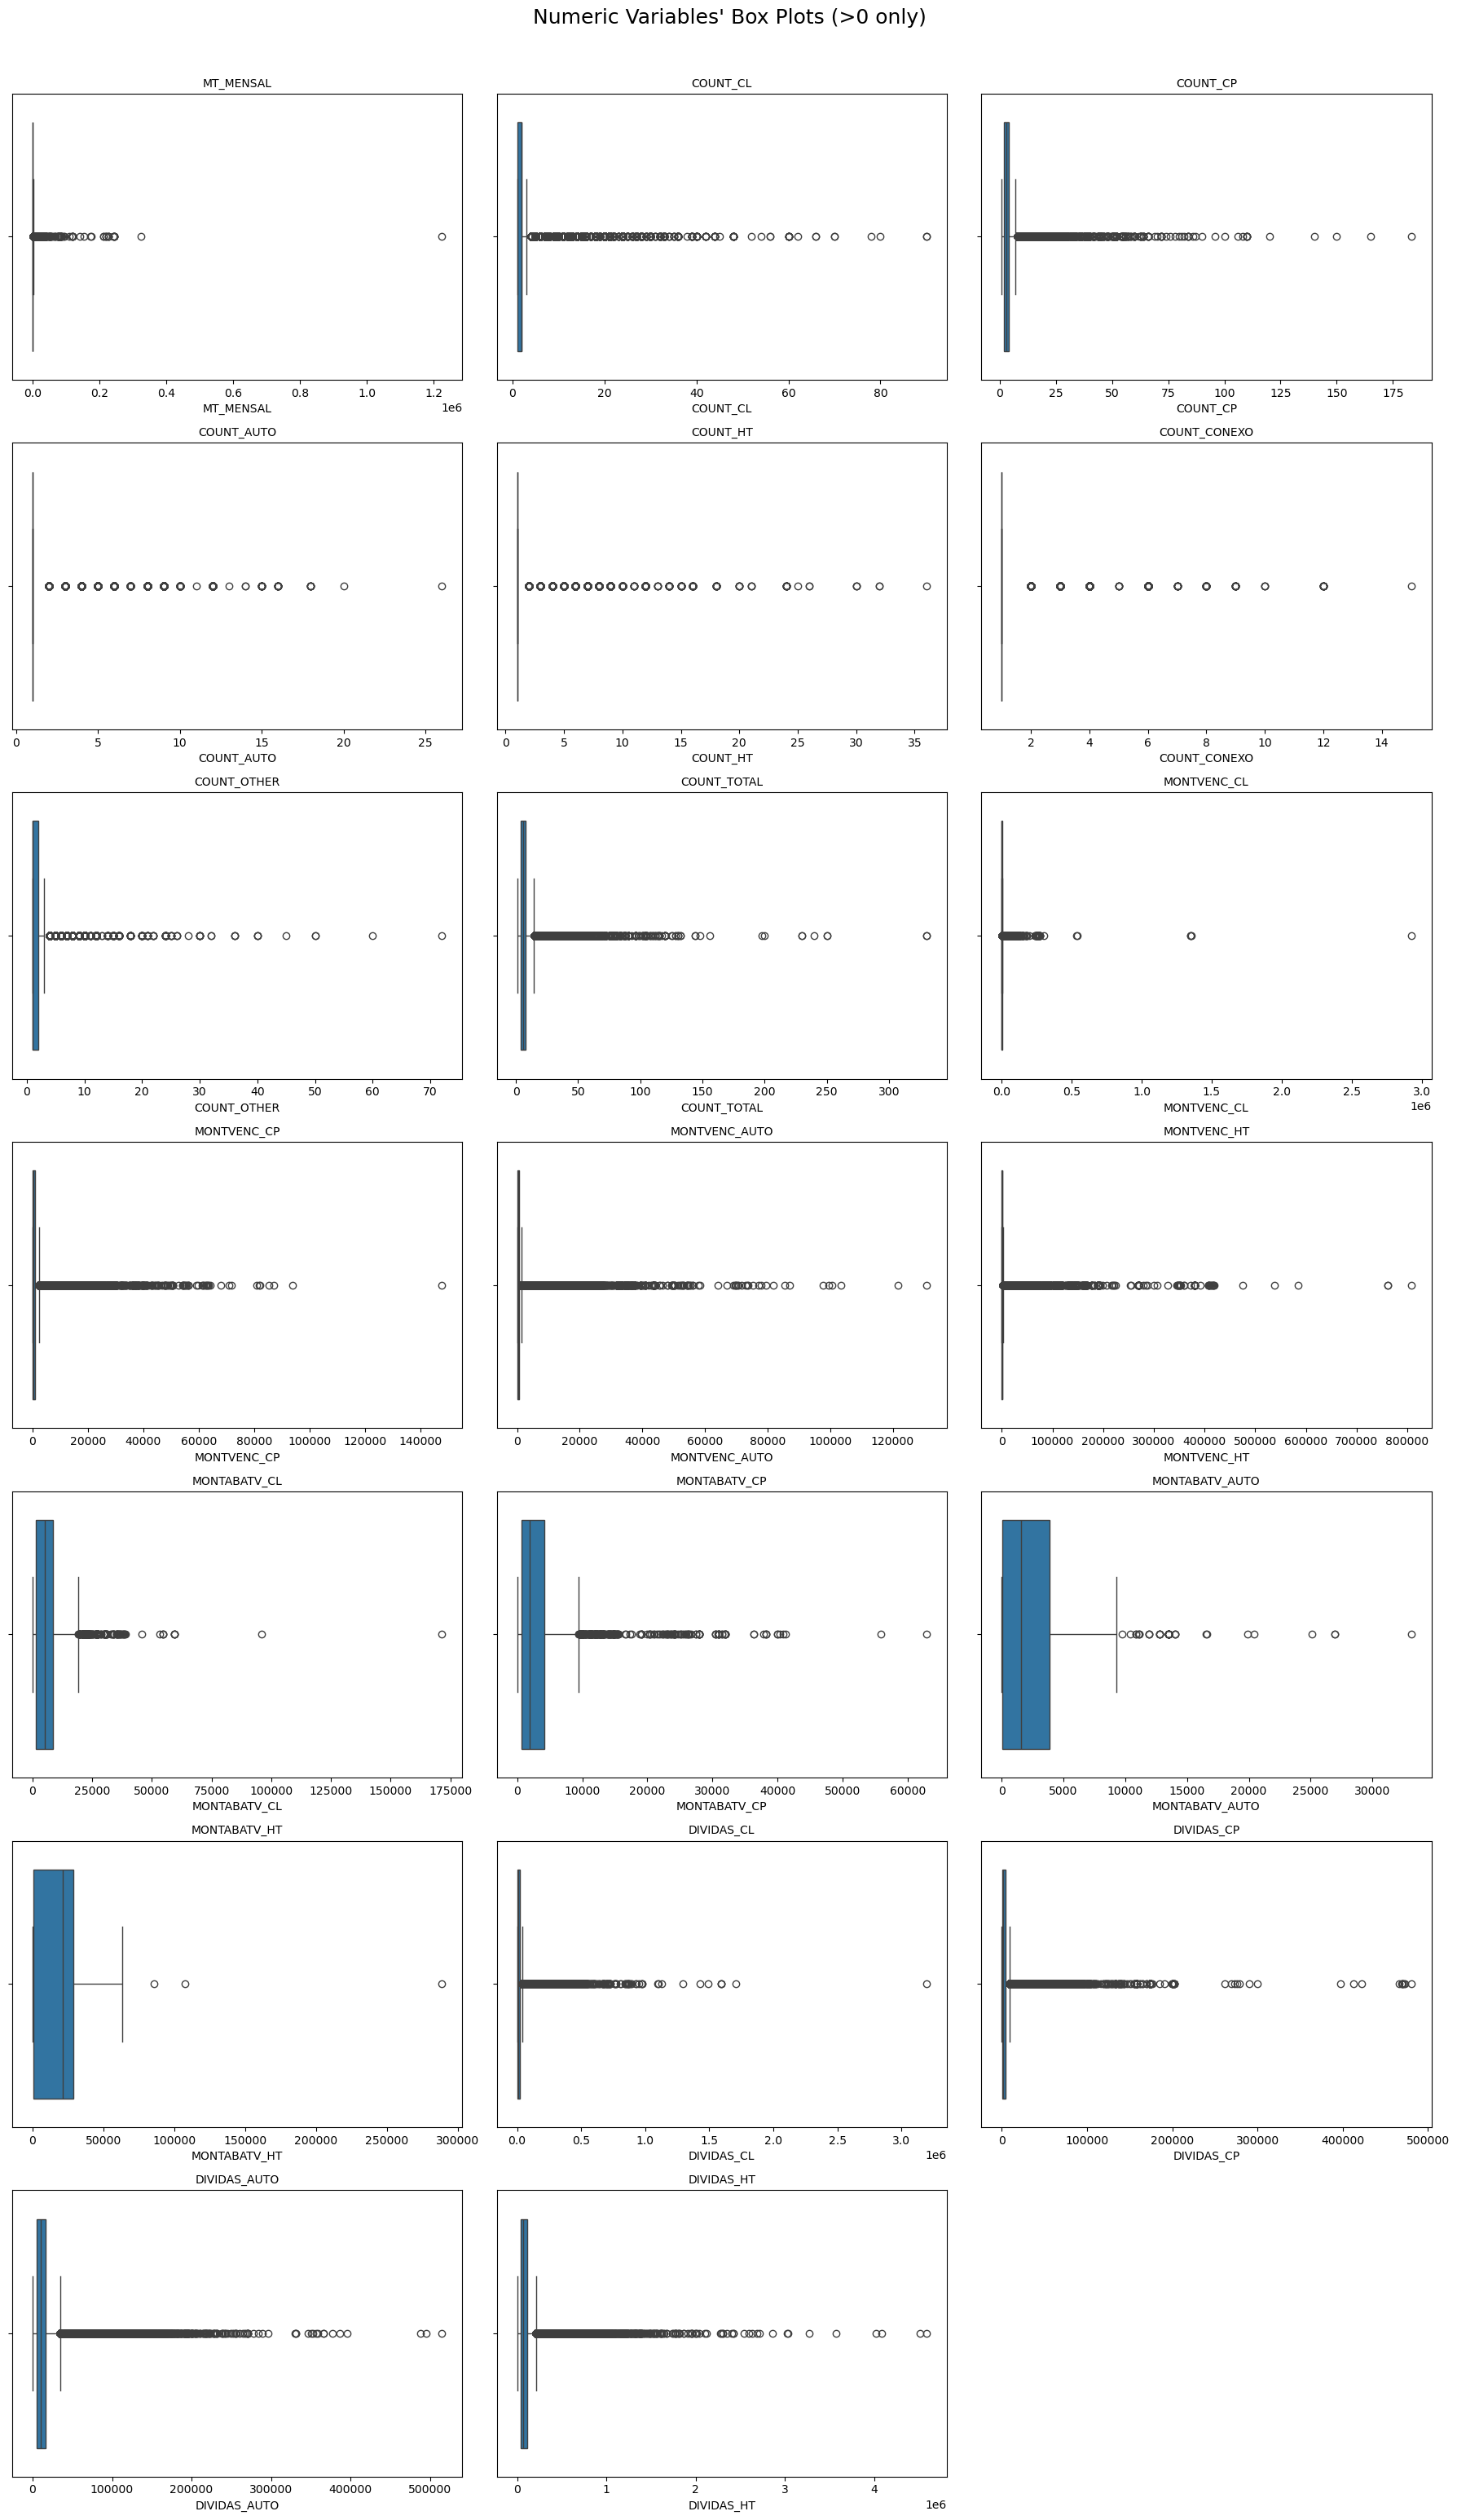

In [19]:
#applying the function to our numerical features
plot_multiple_boxplots(CRC, metric_features)

In [18]:
CRC[CRC['COUNT_CL'] > 50].count()

CONTRIB           20
OBS_DATE          20
MT_MENSAL         14
COUNT_CL          20
COUNT_CP          20
COUNT_AUTO        20
COUNT_HT          20
COUNT_CONEXO      20
COUNT_OTHER       20
COUNT_TOTAL       20
MONTVENC_CL       20
MONTVENC_CP       20
MONTVENC_AUTO     20
MONTVENC_HT       20
MONTABATV_CL      20
MONTABATV_CP      20
MONTABATV_AUTO    20
MONTABATV_HT      20
DIVIDAS_CL        20
DIVIDAS_CP        20
DIVIDAS_AUTO      20
DIVIDAS_HT        20
dtype: int64

In [19]:
CRC[CRC['COUNT_CP'] > 100].count()

CONTRIB           12
OBS_DATE          12
MT_MENSAL          9
COUNT_CL          12
COUNT_CP          12
COUNT_AUTO        12
COUNT_HT          12
COUNT_CONEXO      12
COUNT_OTHER       12
COUNT_TOTAL       12
MONTVENC_CL       12
MONTVENC_CP       12
MONTVENC_AUTO     12
MONTVENC_HT       12
MONTABATV_CL      12
MONTABATV_CP      12
MONTABATV_AUTO    12
MONTABATV_HT      12
DIVIDAS_CL        12
DIVIDAS_CP        12
DIVIDAS_AUTO      12
DIVIDAS_HT        12
dtype: int64

In [20]:
CRC[CRC['COUNT_AUTO'] > 15].count()

CONTRIB           25
OBS_DATE          25
MT_MENSAL          6
COUNT_CL          25
COUNT_CP          25
COUNT_AUTO        25
COUNT_HT          25
COUNT_CONEXO      25
COUNT_OTHER       25
COUNT_TOTAL       25
MONTVENC_CL       25
MONTVENC_CP       25
MONTVENC_AUTO     25
MONTVENC_HT       25
MONTABATV_CL      25
MONTABATV_CP      25
MONTABATV_AUTO    25
MONTABATV_HT      25
DIVIDAS_CL        25
DIVIDAS_CP        25
DIVIDAS_AUTO      25
DIVIDAS_HT        25
dtype: int64

In [21]:
CRC[CRC['COUNT_HT'] > 20].count()

CONTRIB           23
OBS_DATE          23
MT_MENSAL          6
COUNT_CL          23
COUNT_CP          23
COUNT_AUTO        23
COUNT_HT          23
COUNT_CONEXO      23
COUNT_OTHER       23
COUNT_TOTAL       23
MONTVENC_CL       23
MONTVENC_CP       23
MONTVENC_AUTO     23
MONTVENC_HT       23
MONTABATV_CL      23
MONTABATV_CP      23
MONTABATV_AUTO    23
MONTABATV_HT      23
DIVIDAS_CL        23
DIVIDAS_CP        23
DIVIDAS_AUTO      23
DIVIDAS_HT        23
dtype: int64

In [22]:
CRC[CRC['COUNT_CONEXO'] > 10].count()

CONTRIB           11
OBS_DATE          11
MT_MENSAL          6
COUNT_CL          11
COUNT_CP          11
COUNT_AUTO        11
COUNT_HT          11
COUNT_CONEXO      11
COUNT_OTHER       11
COUNT_TOTAL       11
MONTVENC_CL       11
MONTVENC_CP       11
MONTVENC_AUTO     11
MONTVENC_HT       11
MONTABATV_CL      11
MONTABATV_CP      11
MONTABATV_AUTO    11
MONTABATV_HT      11
DIVIDAS_CL        11
DIVIDAS_CP        11
DIVIDAS_AUTO      11
DIVIDAS_HT        11
dtype: int64

In [23]:
CRC[CRC['COUNT_OTHER'] > 30].count()

CONTRIB           13
OBS_DATE          13
MT_MENSAL         10
COUNT_CL          13
COUNT_CP          13
COUNT_AUTO        13
COUNT_HT          13
COUNT_CONEXO      13
COUNT_OTHER       13
COUNT_TOTAL       13
MONTVENC_CL       13
MONTVENC_CP       13
MONTVENC_AUTO     13
MONTVENC_HT       13
MONTABATV_CL      13
MONTABATV_CP      13
MONTABATV_AUTO    13
MONTABATV_HT      13
DIVIDAS_CL        13
DIVIDAS_CP        13
DIVIDAS_AUTO      13
DIVIDAS_HT        13
dtype: int64

In [24]:
CRC[CRC['MONTVENC_CL'] > 300000].count()

CONTRIB           7
OBS_DATE          7
MT_MENSAL         7
COUNT_CL          7
COUNT_CP          7
COUNT_AUTO        7
COUNT_HT          7
COUNT_CONEXO      7
COUNT_OTHER       7
COUNT_TOTAL       7
MONTVENC_CL       7
MONTVENC_CP       7
MONTVENC_AUTO     7
MONTVENC_HT       7
MONTABATV_CL      7
MONTABATV_CP      7
MONTABATV_AUTO    7
MONTABATV_HT      7
DIVIDAS_CL        7
DIVIDAS_CP        7
DIVIDAS_AUTO      7
DIVIDAS_HT        7
dtype: int64

In [25]:
CRC[CRC['MONTVENC_CP'] > 60000].count()

CONTRIB           19
OBS_DATE          19
MT_MENSAL         13
COUNT_CL          19
COUNT_CP          19
COUNT_AUTO        19
COUNT_HT          19
COUNT_CONEXO      19
COUNT_OTHER       19
COUNT_TOTAL       19
MONTVENC_CL       19
MONTVENC_CP       19
MONTVENC_AUTO     19
MONTVENC_HT       19
MONTABATV_CL      19
MONTABATV_CP      19
MONTABATV_AUTO    19
MONTABATV_HT      19
DIVIDAS_CL        19
DIVIDAS_CP        19
DIVIDAS_AUTO      19
DIVIDAS_HT        19
dtype: int64

In [26]:
CRC[CRC['MONTVENC_AUTO'] > 70000].count()

CONTRIB           19
OBS_DATE          19
MT_MENSAL          5
COUNT_CL          19
COUNT_CP          19
COUNT_AUTO        19
COUNT_HT          19
COUNT_CONEXO      19
COUNT_OTHER       19
COUNT_TOTAL       19
MONTVENC_CL       19
MONTVENC_CP       19
MONTVENC_AUTO     19
MONTVENC_HT       19
MONTABATV_CL      19
MONTABATV_CP      19
MONTABATV_AUTO    19
MONTABATV_HT      19
DIVIDAS_CL        19
DIVIDAS_CP        19
DIVIDAS_AUTO      19
DIVIDAS_HT        19
dtype: int64

In [27]:
CRC[CRC['MONTVENC_HT'] > 400000].count()

CONTRIB           17
OBS_DATE          17
MT_MENSAL         15
COUNT_CL          17
COUNT_CP          17
COUNT_AUTO        17
COUNT_HT          17
COUNT_CONEXO      17
COUNT_OTHER       17
COUNT_TOTAL       17
MONTVENC_CL       17
MONTVENC_CP       17
MONTVENC_AUTO     17
MONTVENC_HT       17
MONTABATV_CL      17
MONTABATV_CP      17
MONTABATV_AUTO    17
MONTABATV_HT      17
DIVIDAS_CL        17
DIVIDAS_CP        17
DIVIDAS_AUTO      17
DIVIDAS_HT        17
dtype: int64

In [28]:
CRC[CRC['MONTABATV_CL'] > 50000].count()

CONTRIB           10
OBS_DATE          10
MT_MENSAL          2
COUNT_CL          10
COUNT_CP          10
COUNT_AUTO        10
COUNT_HT          10
COUNT_CONEXO      10
COUNT_OTHER       10
COUNT_TOTAL       10
MONTVENC_CL       10
MONTVENC_CP       10
MONTVENC_AUTO     10
MONTVENC_HT       10
MONTABATV_CL      10
MONTABATV_CP      10
MONTABATV_AUTO    10
MONTABATV_HT      10
DIVIDAS_CL        10
DIVIDAS_CP        10
DIVIDAS_AUTO      10
DIVIDAS_HT        10
dtype: int64

In [29]:
CRC[CRC['MONTABATV_CP'] > 30000].count()

CONTRIB           28
OBS_DATE          28
MT_MENSAL         19
COUNT_CL          28
COUNT_CP          28
COUNT_AUTO        28
COUNT_HT          28
COUNT_CONEXO      28
COUNT_OTHER       28
COUNT_TOTAL       28
MONTVENC_CL       28
MONTVENC_CP       28
MONTVENC_AUTO     28
MONTVENC_HT       28
MONTABATV_CL      28
MONTABATV_CP      28
MONTABATV_AUTO    28
MONTABATV_HT      28
DIVIDAS_CL        28
DIVIDAS_CP        28
DIVIDAS_AUTO      28
DIVIDAS_HT        28
dtype: int64

In [30]:
CRC[CRC['MONTABATV_AUTO'] > 10000].count()

CONTRIB           35
OBS_DATE          35
MT_MENSAL          8
COUNT_CL          35
COUNT_CP          35
COUNT_AUTO        35
COUNT_HT          35
COUNT_CONEXO      35
COUNT_OTHER       35
COUNT_TOTAL       35
MONTVENC_CL       35
MONTVENC_CP       35
MONTVENC_AUTO     35
MONTVENC_HT       35
MONTABATV_CL      35
MONTABATV_CP      35
MONTABATV_AUTO    35
MONTABATV_HT      35
DIVIDAS_CL        35
DIVIDAS_CP        35
DIVIDAS_AUTO      35
DIVIDAS_HT        35
dtype: int64

In [31]:
CRC[CRC['MONTABATV_HT'] > 100000].count()

CONTRIB           2
OBS_DATE          2
MT_MENSAL         2
COUNT_CL          2
COUNT_CP          2
COUNT_AUTO        2
COUNT_HT          2
COUNT_CONEXO      2
COUNT_OTHER       2
COUNT_TOTAL       2
MONTVENC_CL       2
MONTVENC_CP       2
MONTVENC_AUTO     2
MONTVENC_HT       2
MONTABATV_CL      2
MONTABATV_CP      2
MONTABATV_AUTO    2
MONTABATV_HT      2
DIVIDAS_CL        2
DIVIDAS_CP        2
DIVIDAS_AUTO      2
DIVIDAS_HT        2
dtype: int64

In [32]:
CRC[CRC['DIVIDAS_CL'] > 1000000].count()

CONTRIB           11
OBS_DATE          11
MT_MENSAL         11
COUNT_CL          11
COUNT_CP          11
COUNT_AUTO        11
COUNT_HT          11
COUNT_CONEXO      11
COUNT_OTHER       11
COUNT_TOTAL       11
MONTVENC_CL       11
MONTVENC_CP       11
MONTVENC_AUTO     11
MONTVENC_HT       11
MONTABATV_CL      11
MONTABATV_CP      11
MONTABATV_AUTO    11
MONTABATV_HT      11
DIVIDAS_CL        11
DIVIDAS_CP        11
DIVIDAS_AUTO      11
DIVIDAS_HT        11
dtype: int64

In [33]:
CRC[CRC['DIVIDAS_CP'] > 200000].count()

CONTRIB           24
OBS_DATE          24
MT_MENSAL         16
COUNT_CL          24
COUNT_CP          24
COUNT_AUTO        24
COUNT_HT          24
COUNT_CONEXO      24
COUNT_OTHER       24
COUNT_TOTAL       24
MONTVENC_CL       24
MONTVENC_CP       24
MONTVENC_AUTO     24
MONTVENC_HT       24
MONTABATV_CL      24
MONTABATV_CP      24
MONTABATV_AUTO    24
MONTABATV_HT      24
DIVIDAS_CL        24
DIVIDAS_CP        24
DIVIDAS_AUTO      24
DIVIDAS_HT        24
dtype: int64

In [34]:
CRC[CRC['DIVIDAS_AUTO'] > 300000].count()

CONTRIB           16
OBS_DATE          16
MT_MENSAL          3
COUNT_CL          16
COUNT_CP          16
COUNT_AUTO        16
COUNT_HT          16
COUNT_CONEXO      16
COUNT_OTHER       16
COUNT_TOTAL       16
MONTVENC_CL       16
MONTVENC_CP       16
MONTVENC_AUTO     16
MONTVENC_HT       16
MONTABATV_CL      16
MONTABATV_CP      16
MONTABATV_AUTO    16
MONTABATV_HT      16
DIVIDAS_CL        16
DIVIDAS_CP        16
DIVIDAS_AUTO      16
DIVIDAS_HT        16
dtype: int64

In [35]:
CRC[CRC['DIVIDAS_HT'] > 2000000].count()

CONTRIB           27
OBS_DATE          27
MT_MENSAL          1
COUNT_CL          27
COUNT_CP          27
COUNT_AUTO        27
COUNT_HT          27
COUNT_CONEXO      27
COUNT_OTHER       27
COUNT_TOTAL       27
MONTVENC_CL       27
MONTVENC_CP       27
MONTVENC_AUTO     27
MONTVENC_HT       27
MONTABATV_CL      27
MONTABATV_CP      27
MONTABATV_AUTO    27
MONTABATV_HT      27
DIVIDAS_CL        27
DIVIDAS_CP        27
DIVIDAS_AUTO      27
DIVIDAS_HT        27
dtype: int64

In [38]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()  # flatten in case of multiple rows
    
    for i, feat in enumerate(feats):
        sns.boxplot(
            x=data[feat],
            ax=axes[i]
        )
        axes[i].set_title(feat, fontsize=10)
    
    # Remove empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### 2.5. Checking Distribution

In [39]:
df= pd.DataFrame(CRC[metric_features])

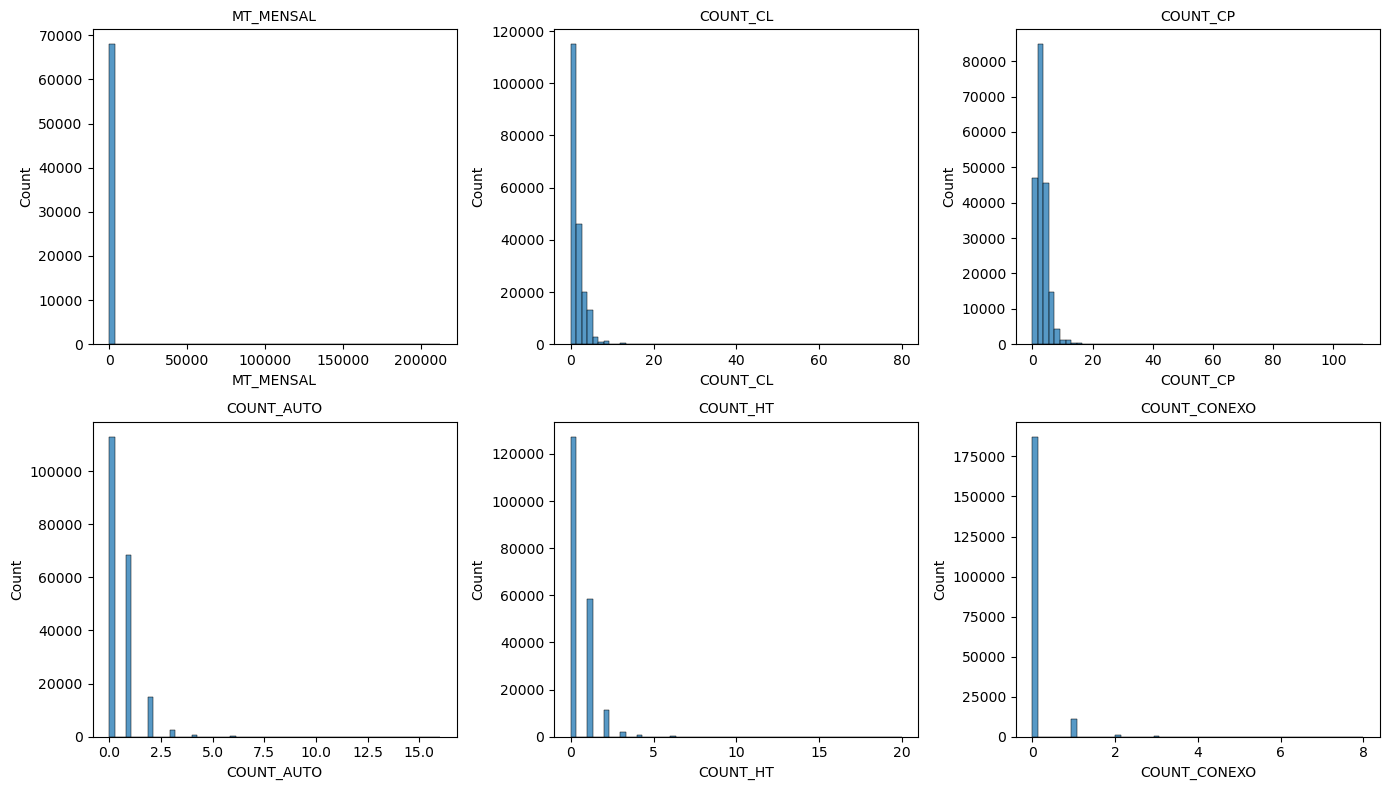

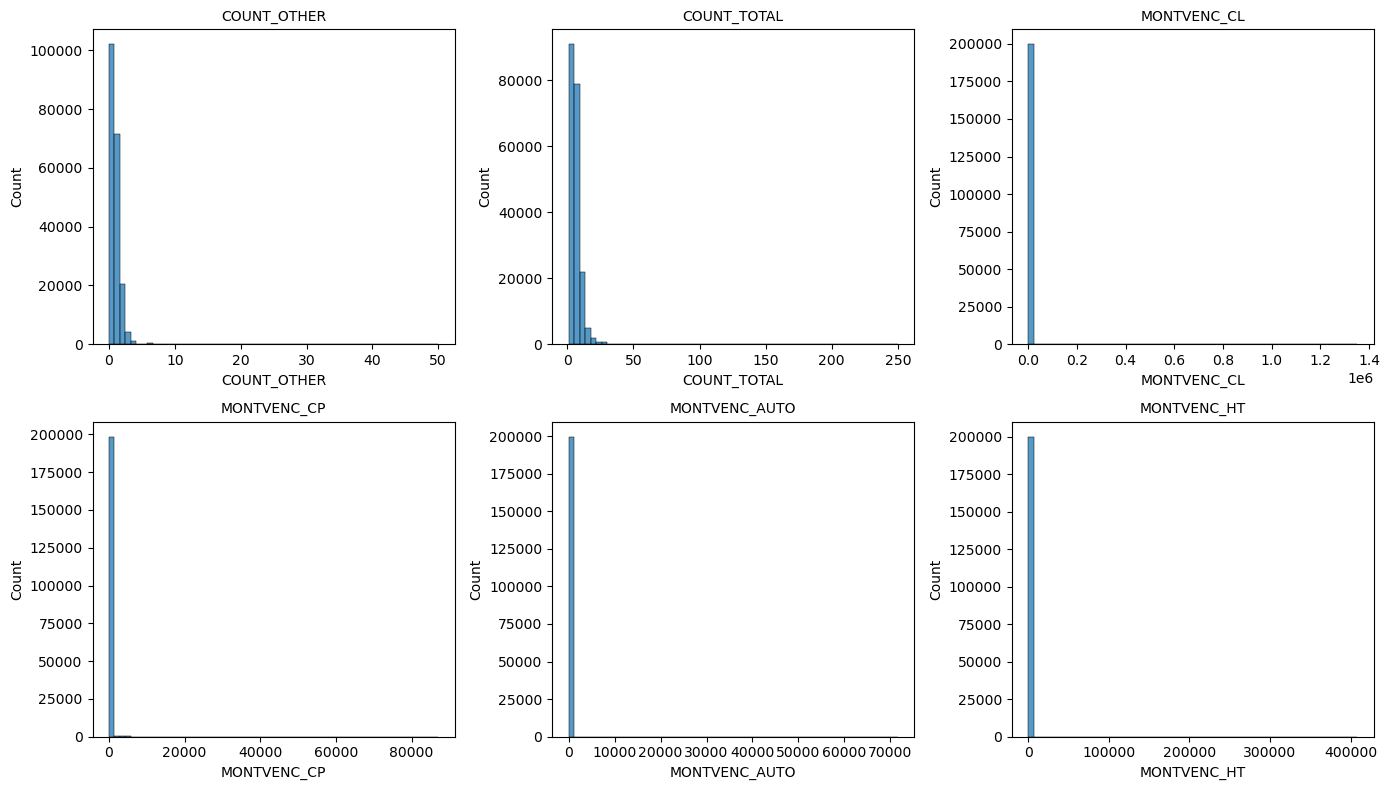

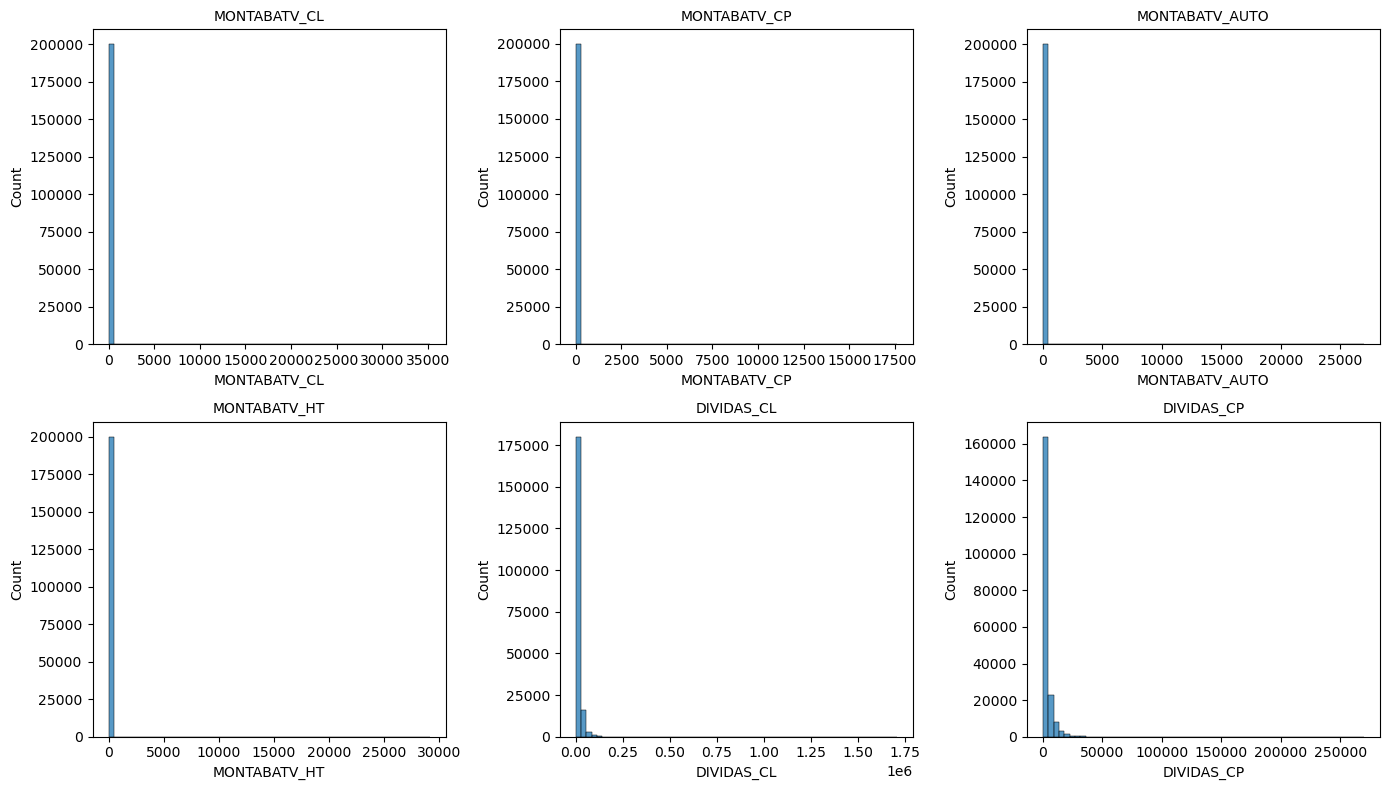

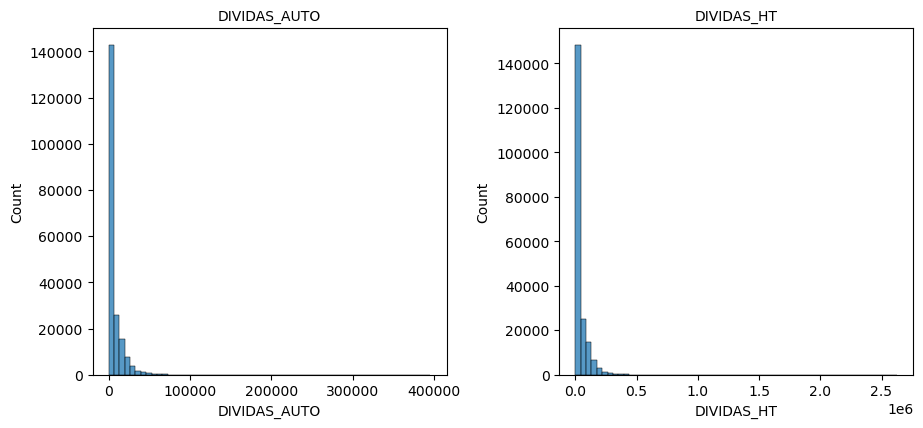

In [40]:
# Sampling
N = 200_000
sample = CRC.sample(n=min(N, len(CRC)), random_state=42)

cols = sample.select_dtypes(include=[np.number]).columns  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

### 2.6. Checking Correlation between variables

In [41]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = CRC[metric_features].corr(method ='spearman')
cor_spearman

,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
MT_MENSAL,1.000000,0.395456,0.236308,0.231944,0.528161,0.272057,0.236045,0.558835,0.003648,-0.000568,0.016154,0.055819,-0.015057,-0.012127,-0.006622,-0.001455,0.533841,0.253331,0.266549,0.549654
COUNT_CL,0.395456,1.000000,0.204948,-0.183313,-0.006950,0.007571,0.086483,0.508537,0.166407,0.095022,0.025574,0.024357,0.022919,0.009356,-0.000684,0.000307,0.754133,0.321823,-0.153515,-0.014785
COUNT_CP,0.236308,0.204948,1.000000,-0.018989,0.130792,0.048963,0.223728,0.792283,-0.009487,0.065507,-0.021295,-0.004927,-0.006277,0.006749,-0.004314,-0.000484,0.197549,0.578446,-0.012727,0.122814
COUNT_AUTO,0.231944,-0.183313,-0.018989,1.000000,0.013875,0.015116,-0.035781,0.133008,-0.019078,-0.003135,0.136465,-0.001945,-0.001732,0.001956,0.011013,-0.003241,-0.231844,-0.033016,0.949972,0.016585
COUNT_HT,0.528161,-0.006950,0.130792,0.013875,1.000000,0.320383,0.221910,0.369609,-0.055014,-0.045006,-0.036792,0.113256,-0.009013,-0.011366,-0.005470,0.006431,0.014450,0.026859,0.011636,0.960529
COUNT_CONEXO,0.272057,0.007571,0.048963,0.015116,0.320383,1.000000,0.091806,0.195976,-0.018923,-0.018080,-0.010738,0.040709,-0.000477,-0.002240,-0.001672,-0.001178,0.017701,0.034912,0.012127,0.281941
COUNT_OTHER,0.236045,0.086483,0.223728,-0.035781,0.221910,0.091806,1.000000,0.464314,-0.006671,-0.008518,-0.019657,0.027521,-0.001341,0.000122,-0.001632,-0.001998,0.098743,0.129794,-0.035553,0.190432
COUNT_TOTAL,0.558835,0.508537,0.792283,0.133008,0.369609,0.195976,0.464314,1.000000,0.052153,0.069136,0.016794,0.041150,0.003689,0.006556,-0.001466,0.000327,0.398894,0.532123,0.133098,0.338988
MONTVENC_CL,0.003648,0.166407,-0.009487,-0.019078,-0.055014,-0.018923,-0.006671,0.052153,1.000000,0.464612,0.237175,0.113478,0.065208,0.077152,0.017712,0.007293,0.123688,0.078203,-0.017696,-0.055038
MONTVENC_CP,-0.000568,0.095022,0.065507,-0.003135,-0.045006,-0.018080,-0.008518,0.069136,0.464612,1.000000,0.230611,0.095578,0.050279,0.075669,0.011731,0.000846,0.074388,0.167852,-0.002428,-0.044053


In [42]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

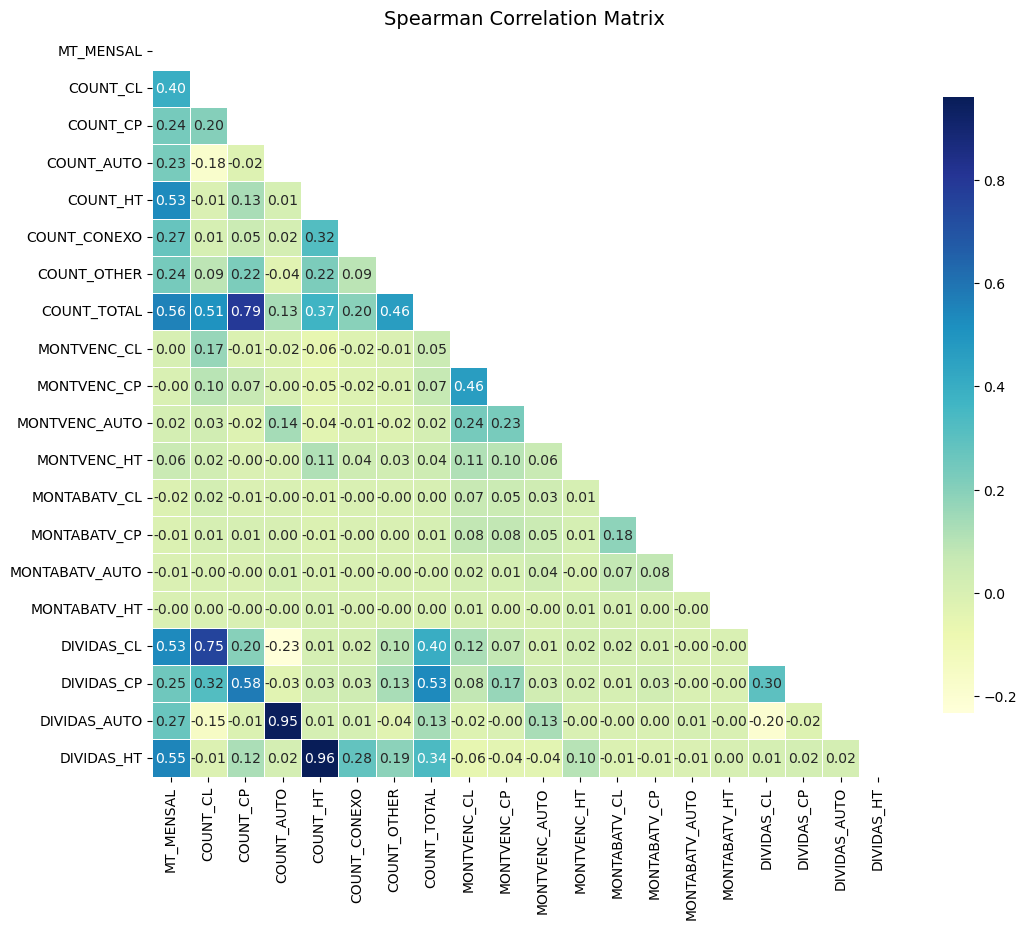

In [43]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

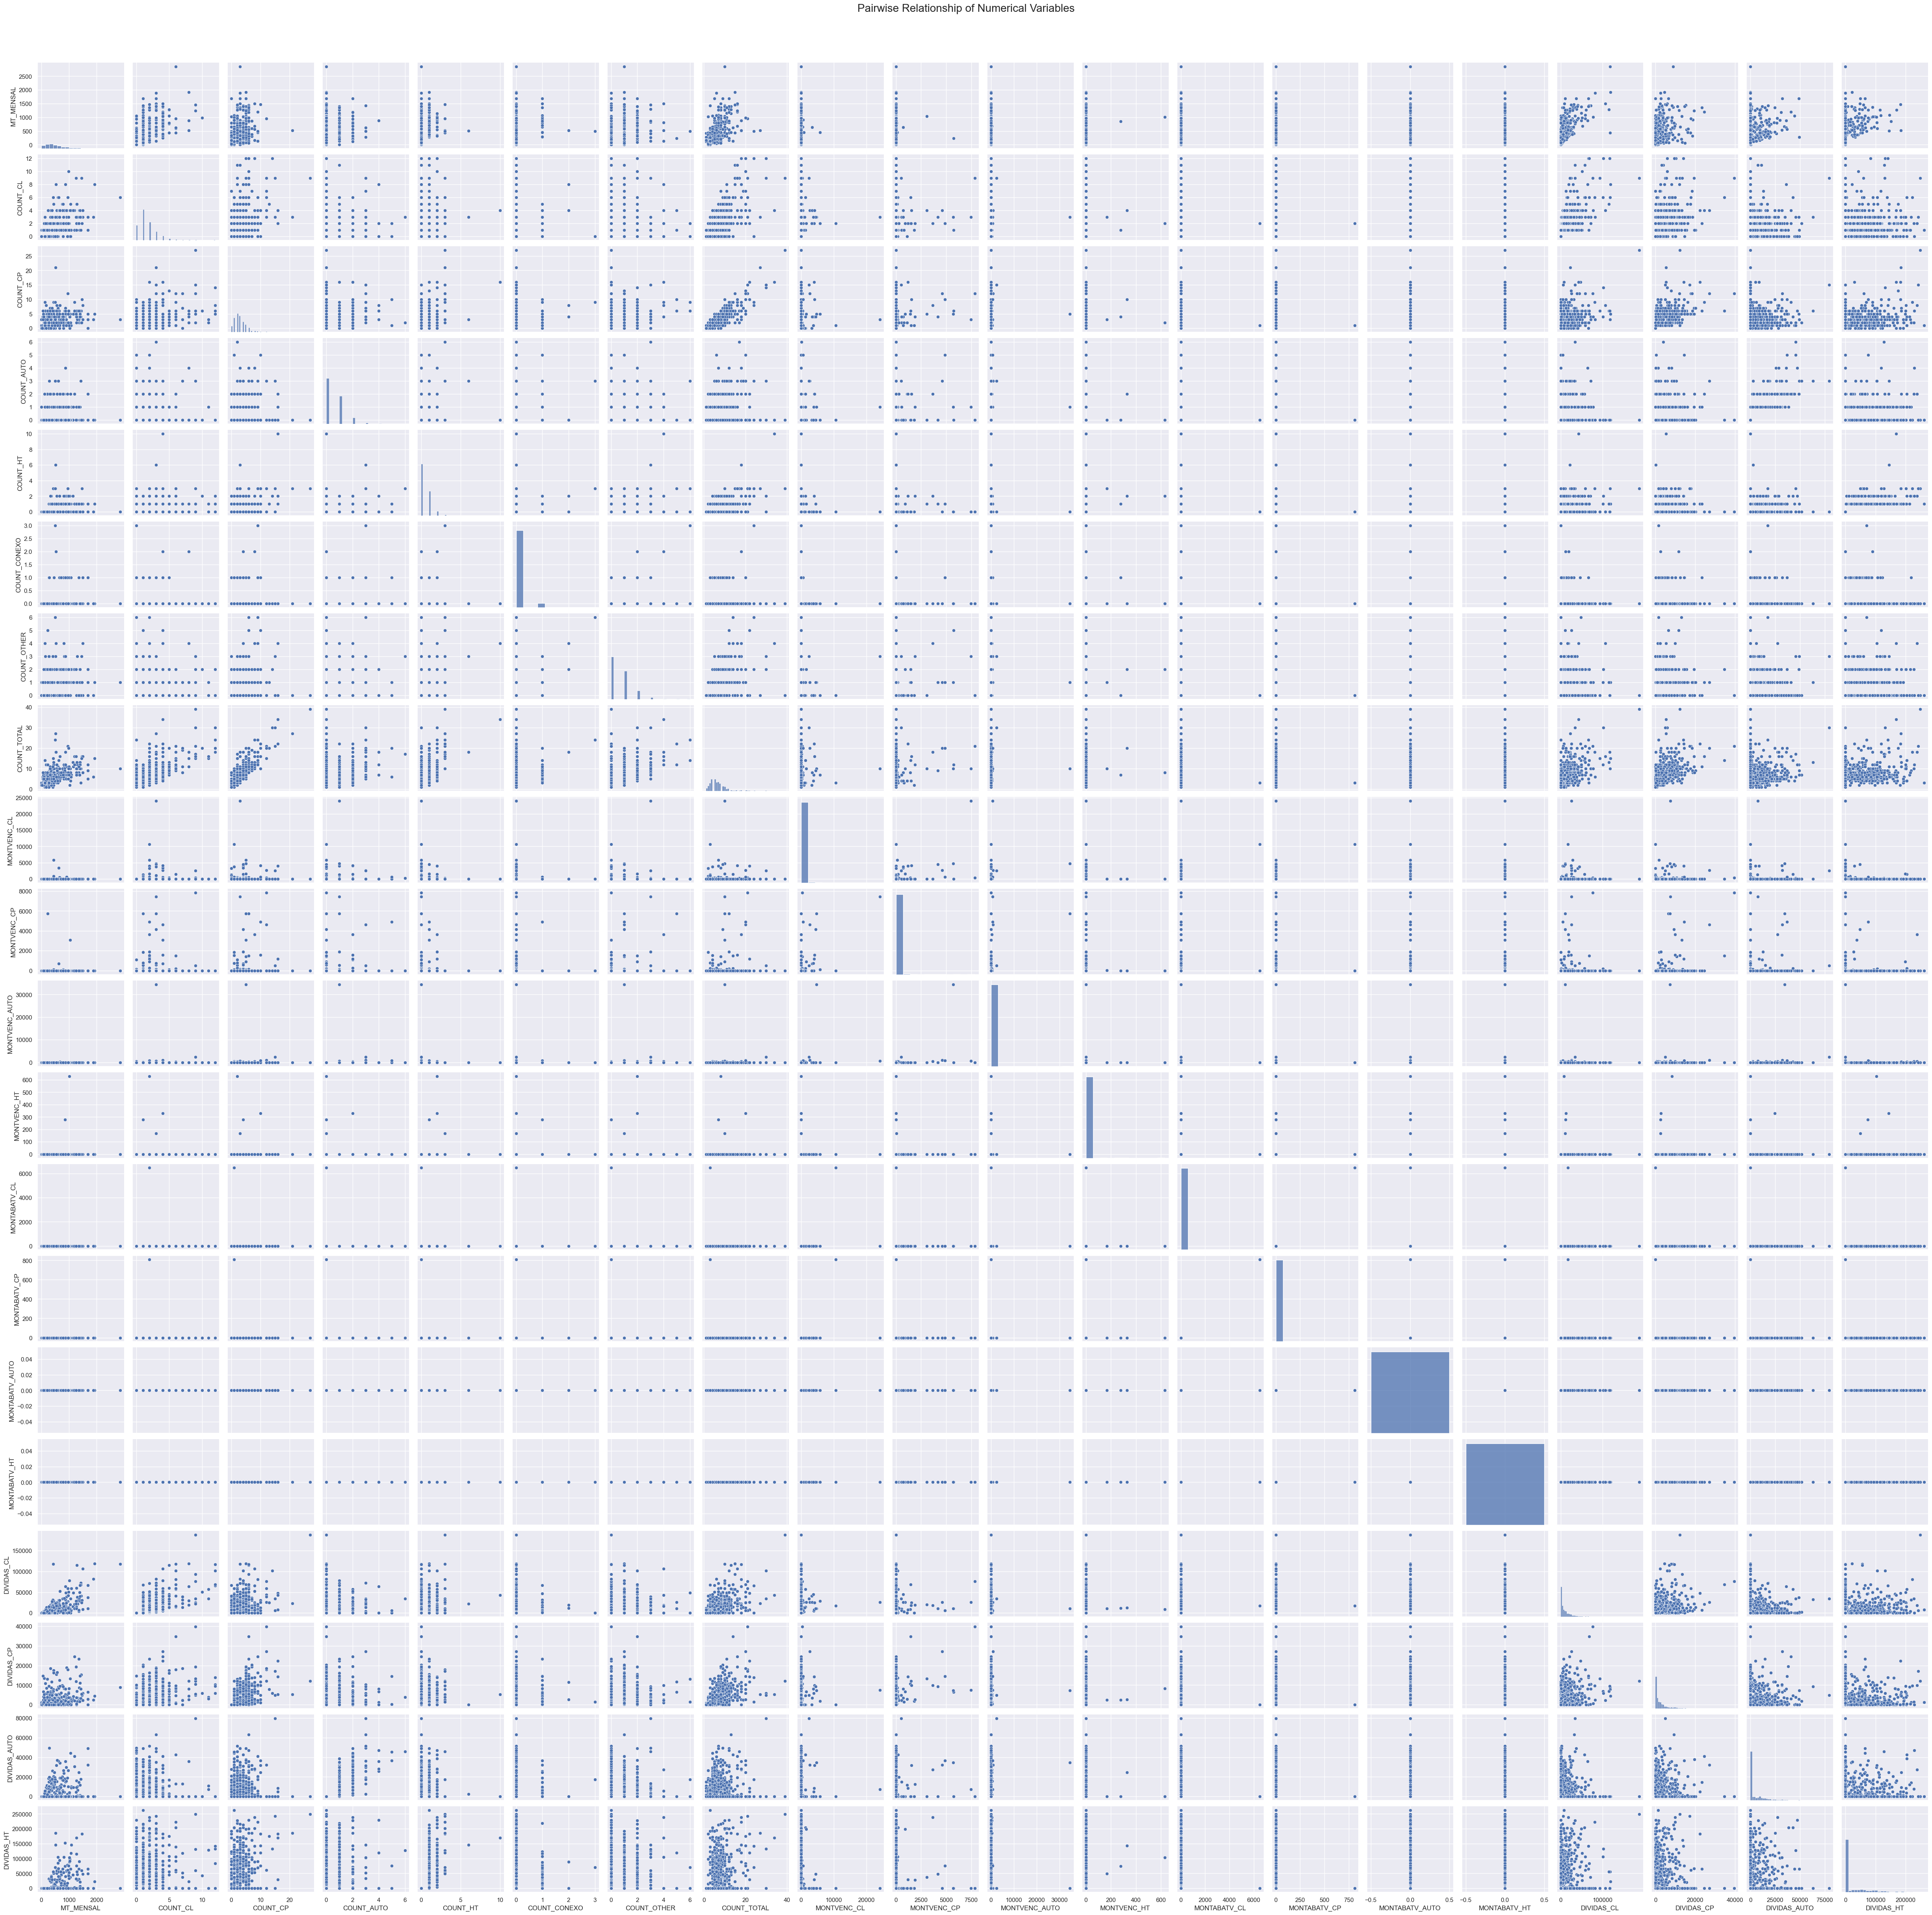

In [44]:
sns.set()

sample_df = df[metric_features].sample(1000, random_state=42)

sns.pairplot(
    sample_df,
    diag_kind="hist"
)

plt.subplots_adjust(top=0.95)
plt.suptitle(
    "Pairwise Relationship of Numerical Variables",
    fontsize=20
)

plt.show()

### 2.7. Checking Incoherencies

In [36]:
CRC[CRC['COUNT_CL'] > CRC['DIVIDAS_CL']]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
2669300,004a4844d13c19d1ece1ba9d054f9f649722fc769d1b74...,2025-10-31,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2791906,004a4844d13c19d1ece1ba9d054f9f649722fc769d1b74...,2025-11-30,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2913915,004a4844d13c19d1ece1ba9d054f9f649722fc769d1b74...,2025-12-31,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
119230,004eb27ba7cf84b926c7fc7e61bfa841e1386f1704e440...,2024-01-31,0.0,1.0,3.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1585.08,0.0,0.0
238612,004eb27ba7cf84b926c7fc7e61bfa841e1386f1704e440...,2024-02-29,0.0,1.0,3.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1605.02,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808962,ffeaef675c35b6708e168516178f2f503b4ee56f4499a9...,2025-02-28,NaN,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
1931416,ffeaef675c35b6708e168516178f2f503b4ee56f4499a9...,2025-03-31,NaN,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2054001,ffeaef675c35b6708e168516178f2f503b4ee56f4499a9...,2025-04-30,NaN,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2176935,ffeaef675c35b6708e168516178f2f503b4ee56f4499a9...,2025-05-31,NaN,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0


In [37]:
CRC[CRC['COUNT_CP'] > CRC['DIVIDAS_CP']]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
1078224,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-09-30,NaN,0.0,4.0,1.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.65,16000.0,0.0
1199421,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-10-31,NaN,0.0,4.0,1.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.65,16000.0,0.0
2913788,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2025-12-31,515.57,3.0,2.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18566.68,0.00,0.0,0.0
1078230,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,2024-09-30,113.79,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3153.88,0.00,0.0,0.0
1199427,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,2024-10-31,113.79,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3153.88,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2546130,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-08-31,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0
2669165,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-09-30,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0
2791771,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-10-31,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0
2913782,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-11-30,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0


In [38]:
CRC[
    CRC['COUNT_CL'] +
    CRC['COUNT_CP'] +
    CRC['COUNT_AUTO'] +
    CRC['COUNT_HT'] +
    CRC['COUNT_CONEXO'] +
    CRC['COUNT_OTHER']
    != CRC['COUNT_TOTAL']
]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a class="anchor" id="2.2 Analysing the Data">

## 3. Data Preparation
    
</a>

### 3.1. Changing Datatypes

In [48]:
#CRC.set_index('CONTRIB', inplace = True)

In [39]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

### 3.2. Handling Missing Values

In [40]:
#handling missing values of 172 rows
CRC = CRC.dropna(subset=['COUNT_CL'])

In [41]:
#droping MT_MENSAL due to its elevated number of missing values
CRC = CRC.drop(columns=['MT_MENSAL'])

In [42]:
#checking number of missing values
CRC.isna().sum()

CONTRIB           0
OBS_DATE          0
COUNT_CL          0
COUNT_CP          0
COUNT_AUTO        0
COUNT_HT          0
COUNT_CONEXO      0
COUNT_OTHER       0
COUNT_TOTAL       0
MONTVENC_CL       0
MONTVENC_CP       0
MONTVENC_AUTO     0
MONTVENC_HT       0
MONTABATV_CL      0
MONTABATV_CP      0
MONTABATV_AUTO    0
MONTABATV_HT      0
DIVIDAS_CL        0
DIVIDAS_CP        0
DIVIDAS_AUTO      0
DIVIDAS_HT        0
dtype: int64

### 3.3. Handling Outliers

In [43]:
CRC['COUNT_CL'] = CRC['COUNT_CL'].clip(upper=50)
CRC['COUNT_CP'] = CRC['COUNT_CP'].clip(upper=100)
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].clip(upper=15)
CRC['COUNT_HT'] = CRC['COUNT_HT'].clip(upper=20)
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].clip(upper=10)
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].clip(upper=30)
CRC['MONTVENC_CL'] = CRC['MONTVENC_CL'].clip(upper=300000)
CRC['MONTVENC_CP'] = CRC['MONTVENC_CP'].clip(upper=60000)
CRC['MONTVENC_AUTO'] = CRC['MONTVENC_AUTO'].clip(upper=70000)
CRC['MONTVENC_HT'] = CRC['MONTVENC_HT'].clip(upper=400000)
CRC['MONTABATV_CL'] = CRC['MONTABATV_CL'].clip(upper=50000)
CRC['MONTABATV_CP'] = CRC['MONTABATV_CP'].clip(upper=30000)
CRC['MONTABATV_AUTO'] = CRC['MONTABATV_AUTO'].clip(upper=10000)
CRC['MONTABATV_HT'] = CRC['MONTABATV_HT'].clip(upper=100000)
CRC['DIVIDAS_CL'] = CRC['DIVIDAS_CL'].clip(upper=1000000)
CRC['DIVIDAS_CP'] = CRC['DIVIDAS_CP'].clip(upper=200000)
CRC['DIVIDAS_AUTO'] = CRC['DIVIDAS_AUTO'].clip(upper=300000)
CRC['DIVIDAS_HT'] = CRC['DIVIDAS_HT'].clip(upper=300000)

In [44]:
#checking if 'COUNT_TOTAL' is well calculated after handling outliers
CRC[
    CRC['COUNT_CL'] +
    CRC['COUNT_CP'] +
    CRC['COUNT_AUTO'] +
    CRC['COUNT_HT'] +
    CRC['COUNT_CONEXO'] +
    CRC['COUNT_OTHER']
    != CRC['COUNT_TOTAL']
]

,CONTRIB,OBS_DATE,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
2055922,03fa3b9ee220e31ec1afec987415381b44adc5949427cb...,2025-05-31,50,42,0,0,0,14,112,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,342581.12,14731.22,0.00,0.00
2304598,0936721438501acbc795a6387613bc404e7abba151a771...,2025-07-31,50,21,3,0,0,0,102,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,102512.19,28161.00,4016.46,0.00
7732,10d819a5d3374566b01cc287e212bfd30ccabb911bacf7...,2023-12-31,0,15,3,20,0,9,57,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.00,16445.31,53071.71,300000.00
2308862,1207c086761e8786304bfaf2e9bdc13d8f3779d369a8ee...,2025-07-31,3,12,3,20,0,6,54,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,132085.50,20438.91,51452.01,300000.00
1450953,122e4fee986fba2e4d2f30ef65c723c6b7c799840ec8f4...,2024-12-31,0,6,6,6,0,30,54,0.00,0.00,70000.0,86640.54,0.0,11867.16,0.0,0.0,0.00,11867.16,77937.42,86640.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2401974,d36407864d679f4bc0c802e1b8ad3859d81e7e466787c3...,2025-07-31,12,48,6,12,10,0,90,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,71484.36,50225.70,10663.02,75195.54
3016859,da3a6b0258652edaf2d9f6037c2723082bc955cf403d03...,2025-12-31,50,18,0,0,0,18,90,273069.45,41917.32,0.0,0.00,50000.0,0.00,0.0,0.0,603017.55,50917.32,0.00,0.00
222105,dd6a5d10ef30f26d94746a23eced2d881720efd4c90d2d...,2024-01-31,8,24,15,8,0,8,64,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,360000.00,3061.68,31592.40,300000.00
2043434,ea28a585535db68ed229f3c0cc10584aca186d022b3c28...,2025-04-30,6,39,3,20,0,6,78,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,580.38,2751.33,58604.01,300000.00


In [45]:
components = [
    'COUNT_CL',
    'COUNT_CP',
    'COUNT_AUTO',
    'COUNT_HT',
    'COUNT_CONEXO',
    'COUNT_OTHER'
]

# Calculate the correct sum
component_sum = CRC[components].sum(axis=1)

# Replace COUNT_TOTAL only where it is different
CRC.loc[CRC['COUNT_TOTAL'] != component_sum, 'COUNT_TOTAL'] = component_sum

### 3.4. Feature Engineering

In [47]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3034749 entries, 0 to 2546133
Data columns (total 21 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   COUNT_CL        Int32         
 3   COUNT_CP        Int32         
 4   COUNT_AUTO      Int32         
 5   COUNT_HT        Int32         
 6   COUNT_CONEXO    Int32         
 7   COUNT_OTHER     Int32         
 8   COUNT_TOTAL     Int32         
 9   MONTVENC_CL     float64       
 10  MONTVENC_CP     float64       
 11  MONTVENC_AUTO   float64       
 12  MONTVENC_HT     float64       
 13  MONTABATV_CL    float64       
 14  MONTABATV_CP    float64       
 15  MONTABATV_AUTO  float64       
 16  MONTABATV_HT    float64       
 17  DIVIDAS_CL      float64       
 18  DIVIDAS_CP      float64       
 19  DIVIDAS_AUTO    float64       
 20  DIVIDAS_HT      float64       
dtypes: Int32(7), datetime64[ns](1), float64(12), object(1)
memo

In [48]:
#creating 'SUBCOUNT_TOTAL'
CRC['SUBCOUNT_TOTAL'] = CRC[
    ['COUNT_CL','COUNT_CP','COUNT_AUTO','COUNT_HT']
].sum(axis=1)

In [49]:
#creating 'MONTVENC_TOTAL'
CRC['MONTVENC_TOTAL'] = CRC[
    ['MONTVENC_CL','MONTVENC_CP','MONTVENC_AUTO','MONTVENC_HT']
].sum(axis=1)

In [50]:
#creating 'MONTABATV_TOTAL'
CRC['MONTABATV_TOTAL'] = CRC[
    ['MONTABATV_CL','MONTABATV_CP','MONTABATV_AUTO','MONTABATV_HT']
].sum(axis=1)

In [51]:
#creating 'DIVIDAS_TOTAL'
CRC['DIVIDAS_TOTAL'] = CRC[
    ['DIVIDAS_CL','DIVIDAS_CP','DIVIDAS_AUTO','DIVIDAS_HT']
].sum(axis=1)

In [52]:
pd.set_option('display.max_columns', None)
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])
CRC.tail(30)

,CONTRIB,OBS_DATE,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT,SUBCOUNT_TOTAL,MONTVENC_TOTAL,MONTABATV_TOTAL,DIVIDAS_TOTAL
717013,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-05-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17345.04,3320.12,0.00,0.0,3,0.00,0.0,20665.16
837416,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-06-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
957819,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-07-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
1078222,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-08-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
1199420,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-09-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17218.32,3011.78,0.00,0.0,3,0.00,0.0,20230.10
1320617,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-10-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17218.32,3011.78,0.00,0.0,3,0.00,0.0,20230.10
1442298,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-11-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17143.40,3272.10,0.00,0.0,3,0.00,0.0,20415.50
1564571,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-12-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17067.34,3158.29,0.00,0.0,3,0.00,0.0,20225.63
1686627,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-01-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,16991.81,2885.36,0.00,0.0,3,0.00,0.0,19877.17
1809009,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-02-28,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,16914.79,2949.03,0.00,0.0,3,0.00,0.0,19863.82


### 3.5. Data Aggregation

In [53]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [54]:
#aggregating CRC's variables 
CRC_agg = (
    CRC
    .groupby("CONTRIB", as_index=True)
    .agg(
        count_cl_mean=("COUNT_CL", "mean"),
        #count_cl_mode=("COUNT_CL", moda),
        #count_cp_mean=("COUNT_CP", "mean"),
        #count_cp_mode=("COUNT_CP", moda),
        #count_auto_mean=("COUNT_AUTO", "mean"),
        #count_auto_mode=("COUNT_AUTO", moda),
        #count_ht_mean=("COUNT_HT", "mean"),
        #count_ht_mode=("COUNT_HT", moda),
        #count_conexo_mean=("COUNT_CONEXO", "mean"),
        #count_conexo_mode=("COUNT_CONEXO", moda),
        #count_other_mean=("COUNT_OTHER", "mean"),
        #count_other_mode=("COUNT_OTHER", moda),
        montvenc_cl_mean= ("MONTVENC_CL", "mean"),
        #montvenc_cl_mode= ("MONTVENC_CL", moda),
        #montvenc_cp_mean= ("MONTVENC_CP", "mean"),
        #montvenc_cp_mode= ("MONTVENC_CP", moda),
        #montvenc_auto_mean= ("MONTVENC_AUTO", "mean"),
        #montvenc_auto_mode= ("MONTVENC_AUTO", moda),
        #montvenc_ht_mean= ("MONTVENC_HT", "mean"),
        #montvenc_ht_mode= ("MONTVENC_HT", moda),
        montabatv_cl_mean= ("MONTABATV_CL", "mean"),
        #montabatv_cl_mode= ("MONTABATV_CL", moda),
        #montabatv_cp_mean= ("MONTABATV_CP", "mean"),
        #montabatv_cp_mode= ("MONTABATV_CL", moda),
        #montabatv_auto_mean= ("MONTABATV_AUTO", "mean"),
        #montabatv_auto_mode= ("MONTABATV_AUTO", moda),
        #montabatv_ht_mean= ("MONTABATV_HT", "mean"),
        #montabatv_ht_mode= ("MONTABATV_HT", moda),
        #balance_cl_mean=("BALANCE_CL", "mean"),
        #balance_cl_mode=("BALANCE_CL", moda),
        #balance_cp_mean=("BALANCE_CP", "mean"),
        #balance_cp_mode=("BALANCE_CP", moda),
        #balance_auto_mean=("BALANCE_AUTO", "mean"),
        #balance_auto_mode=("BALANCE_AUTO", moda),
        #balance_ht_mean=("BALANCE_HT", "mean"),
        #balance_ht_mode=("BALANCE_HT", moda),
        dividas_cl_mean=("DIVIDAS_CL", "mean"),
        #dividas_cl_mode=("DIVIDAS_CL", moda),
        #dividas_cp_mean=("DIVIDAS_CP", "mean"),
        #dividas_cp_mode=("DIVIDAS_CP", moda),
        #dividas_auto_mean=("DIVIDAS_AUTO", "mean"),
        #dividas_auto_mode=("DIVIDAS_AUTO", moda),
        #dividas_ht_mean=("DIVIDAS_HT", "mean"),
        #dividas_ht_mode=("DIVIDAS_HT", moda),
        subcount_total_mean=("SUBCOUNT_TOTAL", "mean"),
        montenc_total_mean=("MONTVENC_TOTAL", "mean"),
        montabatv_total_mean=("MONTABATV_TOTAL", "mean"),
        dividas_total_mean=("DIVIDAS_TOTAL", "mean") 
              
    )
)

In [55]:
#has the client default history?
CRC_agg['HIGH_RISK_CURRENT'] = (
    (CRC_agg['montenc_total_mean'] > 0) | 
    (CRC_agg['montabatv_total_mean'] > 0)
).astype(int)

In [56]:
CRC_agg[CRC_agg['HIGH_RISK_CURRENT'] == 1].count()

count_cl_mean           32098
montvenc_cl_mean        32098
montabatv_cl_mean       32098
dividas_cl_mean         32098
subcount_total_mean     32098
montenc_total_mean      32098
montabatv_total_mean    32098
dividas_total_mean      32098
HIGH_RISK_CURRENT       32098
dtype: int64

In [57]:
CRC_agg.head()

,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT
CONTRIB,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,0.36,0.00000,0.0,2565.793600,5.28,0.000000,0.0,17196.20760,0
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,4.32,0.00000,0.0,26448.032000,9.72,0.000000,0.0,34000.14920,0
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1.04,0.00000,0.0,2082.786000,8.32,0.000000,0.0,93756.88440,0
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08,3.0,0.00000,0.0,22980.086400,4.28,0.000000,0.0,23082.37120,0
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,9.75,2416.34125,0.0,55289.663333,13.625,4038.840833,0.0,60154.73875,1


In [58]:
#checking umber of missing values in each column as a percentage
CRC_agg.isna().sum()/len(CRC_agg) * 100

count_cl_mean           0.0
montvenc_cl_mean        0.0
montabatv_cl_mean       0.0
dividas_cl_mean         0.0
subcount_total_mean     0.0
montenc_total_mean      0.0
montabatv_total_mean    0.0
dividas_total_mean      0.0
HIGH_RISK_CURRENT       0.0
dtype: float64

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# CREDSCORE Dataset
       
</div>

**METADATA**:
- *sys_numero_submissao*: Submission number. 
- *sys_data_procura*: Date of risk probing.
- *kp_sqe*: Risk score of known customers based on behavior: A-X, A is better, null= unknown.
- *ks_score_tier*: risk score for granting (all customers) lower is better.

<a class="anchor" id="2.2 Analysing the Data">

## 2. Analysing the Data
    
</a>

### 2.1. Data Overview

In [59]:
CREDSCORE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63704 entries, 0 to 63703
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CONTRIB               63704 non-null  object        
 1   sys_numero_submissao  63704 non-null  float64       
 2   sys_data_procura      63704 non-null  datetime64[ns]
 3   kp_sqe                45653 non-null  object        
 4   ks_score_tier         63704 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.4+ MB


In [60]:
CREDSCORE.describe().round(2)

,sys_numero_submissao,sys_data_procura,ks_score_tier
count,63704.00,63704,63704.00
mean,5.86,2024-08-26 19:30:49.503955968,1.59
min,0.00,2020-08-12 00:00:00,1.00
25%,3.00,2023-12-07 00:00:00,1.00
50%,5.00,2024-10-10 00:00:00,1.00
75%,8.00,2025-06-05 00:00:00,2.00
max,62.00,2025-12-15 00:00:00,5.00
std,4.19,NaN,0.84


In [61]:
#descriptive statistics for categorical data
CREDSCORE.describe(include = ['O'])

,CONTRIB,kp_sqe
count,63704,45653
unique,62173,15
top,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9...,A
freq,20,6977


In [62]:
#how many clients exists for each classification (Alphabetical order)
CREDSCORE['kp_sqe'] \
    .value_counts(dropna=False) \
    .sort_index()

kp_sqe
A        6977
B        5404
C        4205
D        4638
E        6300
F        6085
G        3386
H        4788
I        1476
J         665
K         499
M         155
U         600
V         128
W         347
None    18051
Name: count, dtype: int64

- We can see the most common classification is 'A' which is a good indicator, and there is no client with classification 'X' (the worst)
- We should see what classification is considered risky

In [63]:
CREDSCORE['ks_score_tier'].value_counts(dropna=False)

ks_score_tier
1.0    39117
2.0    12670
3.0    10961
4.0      633
5.0      323
Name: count, dtype: int64

- The most common one is 1, which is also a good indicator.

### 2.2. Checking Duplicates

In [64]:
#checking number of duplicates
CREDSCORE.duplicated().sum()

np.int64(831)

In [65]:
dups = CREDSCORE[CREDSCORE.duplicated(subset=["CONTRIB"], keep=False)].sort_values("CONTRIB")
display(dups.head(20))

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
47,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,1.0,2024-03-20,H,2.0
48,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,1.0,2024-03-20,H,1.0
202,00c37349b39ab60123c5f27d2a6dbed7491c55650506d6...,1.0,2023-09-12,D,3.0
203,00c37349b39ab60123c5f27d2a6dbed7491c55650506d6...,1.0,2023-09-12,D,2.0
249,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,1.0,2023-06-15,U,3.0
250,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,1.0,2023-06-15,U,3.0
263,01075c43c0ff8ec7ff76ffe65db4231a528099497f5d7d...,1.0,2025-08-19,None,5.0
264,01075c43c0ff8ec7ff76ffe65db4231a528099497f5d7d...,1.0,2025-08-19,None,2.0
341,01528f21434f34c7976541dca95691cea0b4778577c537...,1.0,2024-07-04,None,4.0
342,01528f21434f34c7976541dca95691cea0b4778577c537...,1.0,2024-07-04,None,2.0


In [66]:
CREDSCORE = CREDSCORE.sort_values(['CONTRIB'])

In [67]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show full content of each column (no truncation)
pd.set_option('display.max_colwidth', None)

# Optional: increase display width for better readability
pd.set_option('display.width', 200)

# Display the first 10 duplicated rows sorted by 'CONTRIB'
duplicated_rows = CREDSCORE[CREDSCORE.duplicated()]
duplicated_rows.sort_values(['CONTRIB']).head(10)

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
250,00f7e9f67656f7f492faef74c1452f49148c0969f54e3522c3ff7ea0e9fa5e56,1.0,2023-06-15,U,3.0
371,0177cc8863841377a2e828078db37e3ef370e41c07a74754f76bccce11470b1e,1.0,2025-11-20,None,5.0
795,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2023-03-23,H,2.0
1036,0409d4ca80af441a716c8306061d0e3b1b93bd75143c3c9b1d9f360d8488c368,0.0,2024-07-17,G,2.0
1105,044f2375bbefdd1d9f5bca900e22eca71f7a87e0a06cf214c78d1efa02513086,0.0,2023-09-06,E,1.0
1139,0472bdf64157b19fa8fd7bd32d3cd0a7c0de3d1490e857677fa1d30516f206cb,1.0,2025-03-11,C,1.0
1169,048dcfd5d00fc43a1b8c23283cbd8ff885013f437451214eb5fe93e458ca7ec5,1.0,2025-12-10,I,2.0
1203,04af1626e026f1237ed33a6e9904c44f9748ee04c58a5d4ca057bd1b3a9ff695,1.0,2025-05-26,E,3.0
1229,04cd1bc1a93cad7b0d1cd894f6fcad04f970491ba0f64013c52f1563189f1eca,1.0,2024-12-26,G,2.0
1247,04e6b3fd5cd02bfdd96f6d85f5f85decdd259a5b969f24a2646e9075e75493f9,0.0,2023-09-26,U,1.0


### 2.3. Checking Incoherencies

In [68]:
print("shape:", CREDSCORE.shape)
print("clientes únicos:", CREDSCORE['CONTRIB'].nunique())
print("duplicados por cliente:", CREDSCORE.duplicated(subset=['CONTRIB']).sum())

shape: (63704, 5)
clientes únicos: 62173
duplicados por cliente: 1531


- There are 700 duplicates in *CONTRIB*

In [69]:
CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'], errors='coerce')

# número de datas diferentes por cliente
dates_per_client = CREDSCORE.groupby('CONTRIB')['sys_data_procura'].nunique()

print("Clients with >1 date:", (dates_per_client > 1).sum())

Clients with >1 date: 106


- There are 106 clients that have more than 1 date, which is not possible because in this dataset we are only considering the date of client's last credit proposal.

In [70]:
CREDSCORE[CREDSCORE['CONTRIB']=='0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557']

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
811,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2025-05-20,None,5.0
810,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2025-02-05,None,5.0
809,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-07-26,None,5.0
808,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-07-23,None,5.0
806,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-05-23,None,5.0
805,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-05-15,None,5.0
804,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-05-07,None,5.0
803,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-04-02,None,5.0
802,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-02-14,None,5.0
807,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557,0.0,2024-05-27,None,5.0


### 2.4. Checking Missing Values

In [71]:
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].astype(str).str.strip().str.upper()
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].replace({'NULL': np.nan, 'NONE': np.nan})

In [72]:
#checking umber of missing values in each column as a percentage
CREDSCORE.isna().sum()/len(CREDSCORE) * 100

CONTRIB                  0.00000
sys_numero_submissao     0.00000
sys_data_procura         0.00000
kp_sqe                  28.33574
ks_score_tier            0.00000
dtype: float64

In [73]:
#checking number of missing values
CREDSCORE.isna().sum()

CONTRIB                     0
sys_numero_submissao        0
sys_data_procura            0
kp_sqe                  18051
ks_score_tier               0
dtype: int64

- This missing values correspond to unknown clients.

### 2.5. Checking Outliers

In [74]:
metric_features= ['ks_score_tier']

In [86]:
def plot_boxplot(data, feat='ks_score_tier', title="Box Plot (>0 only)"):
    
    # Keep only values strictly greater than 0
    values = data[feat]
    values = values[(values > 0) & (values.notna())]
    
    plt.figure(figsize=(6, 4.5))
    
    if len(values) > 0:
        sns.boxplot(x=values)
        plt.title(feat, fontsize=10)
    else:
        plt.title(f"{feat} (no >0 values)", fontsize=10)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

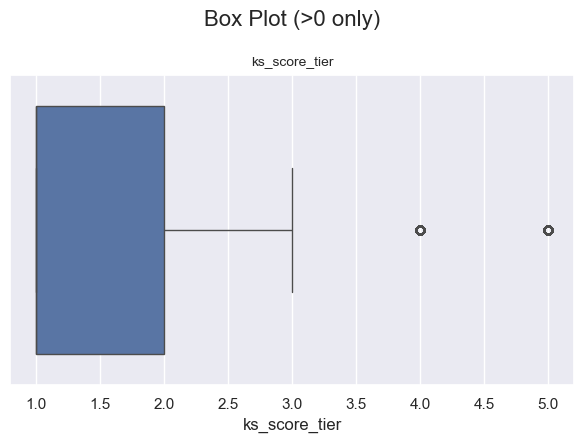

In [87]:
#applying the function to our numerical features
plot_boxplot(CREDSCORE)

In [75]:
CREDSCORE[CREDSCORE['ks_score_tier'] > 4].count()

CONTRIB                 323
sys_numero_submissao    323
sys_data_procura        323
kp_sqe                    9
ks_score_tier           323
dtype: int64

### 2.6. Checking Distribution

#### 2.6.1. Numerical Variable

In [89]:
df= pd.DataFrame(CREDSCORE[metric_features])

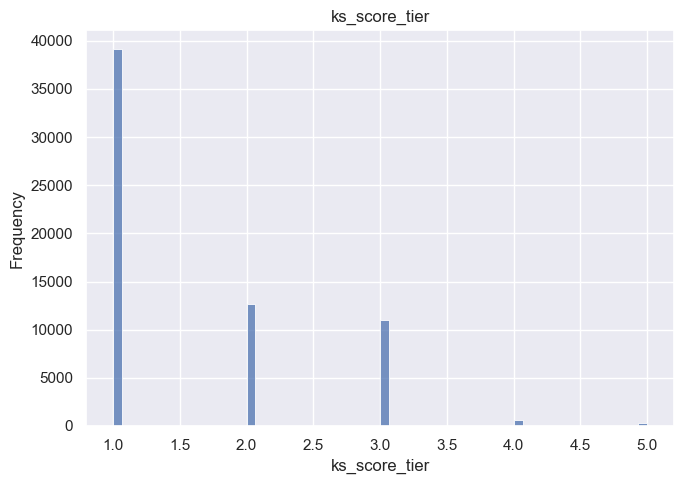

In [90]:
# Sampling
N = min(200_000, len(CREDSCORE))
sample = CREDSCORE.sample(n=N, random_state=42)

col = metric_features[0]   # 'ks_score_tier'

fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)

ax.set_title(col, fontsize=12)
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 2.6.2. Categorical Variable

In [91]:
'''import matplotlib.pyplot as plt
import seaborn as sns

# Set white background style
sns.set_style('white')

# Function to generate a palette based on number of unique categories
def get_palette(CREDSCORE, column):
    n = CREDSCORE[column].nunique()
    return sns.color_palette("tab20", n) if n <= 20 else sns.color_palette("husl", n)

# Specify the variable to plot
column_to_plot = 'kp_sqe'  # replace with your actual column name

# Generate palette
palette = get_palette(CREDSCORE, column_to_plot)

# Create figure
plt.figure(dpi=300, figsize=(12, 6))
plt.gcf().patch.set_facecolor('white')

# Create count plot
sns.countplot(
    data=CREDSCORE,
    x=column_to_plot,
    hue=column_to_plot,
    palette=palette,
    dodge=False
)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Remove legend (optional)
plt.legend([],[], frameon=False)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()'''

'import matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Set white background style\nsns.set_style(\'white\')\n\n# Function to generate a palette based on number of unique categories\ndef get_palette(CREDSCORE, column):\n    n = CREDSCORE[column].nunique()\n    return sns.color_palette("tab20", n) if n <= 20 else sns.color_palette("husl", n)\n\n# Specify the variable to plot\ncolumn_to_plot = \'kp_sqe\'  # replace with your actual column name\n\n# Generate palette\npalette = get_palette(CREDSCORE, column_to_plot)\n\n# Create figure\nplt.figure(dpi=300, figsize=(12, 6))\nplt.gcf().patch.set_facecolor(\'white\')\n\n# Create count plot\nsns.countplot(\n    data=CREDSCORE,\n    x=column_to_plot,\n    hue=column_to_plot,\n    palette=palette,\n    dodge=False\n)\n\n# Rotate x-axis labels for readability\nplt.xticks(rotation=90)\n\n# Remove legend (optional)\nplt.legend([],[], frameon=False)\n\n# Adjust layout\nplt.tight_layout()\n\n# Show plot\nplt.show()'

C:\Users\jcari\AppData\Local\Temp\ipykernel_38896\1099526685.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


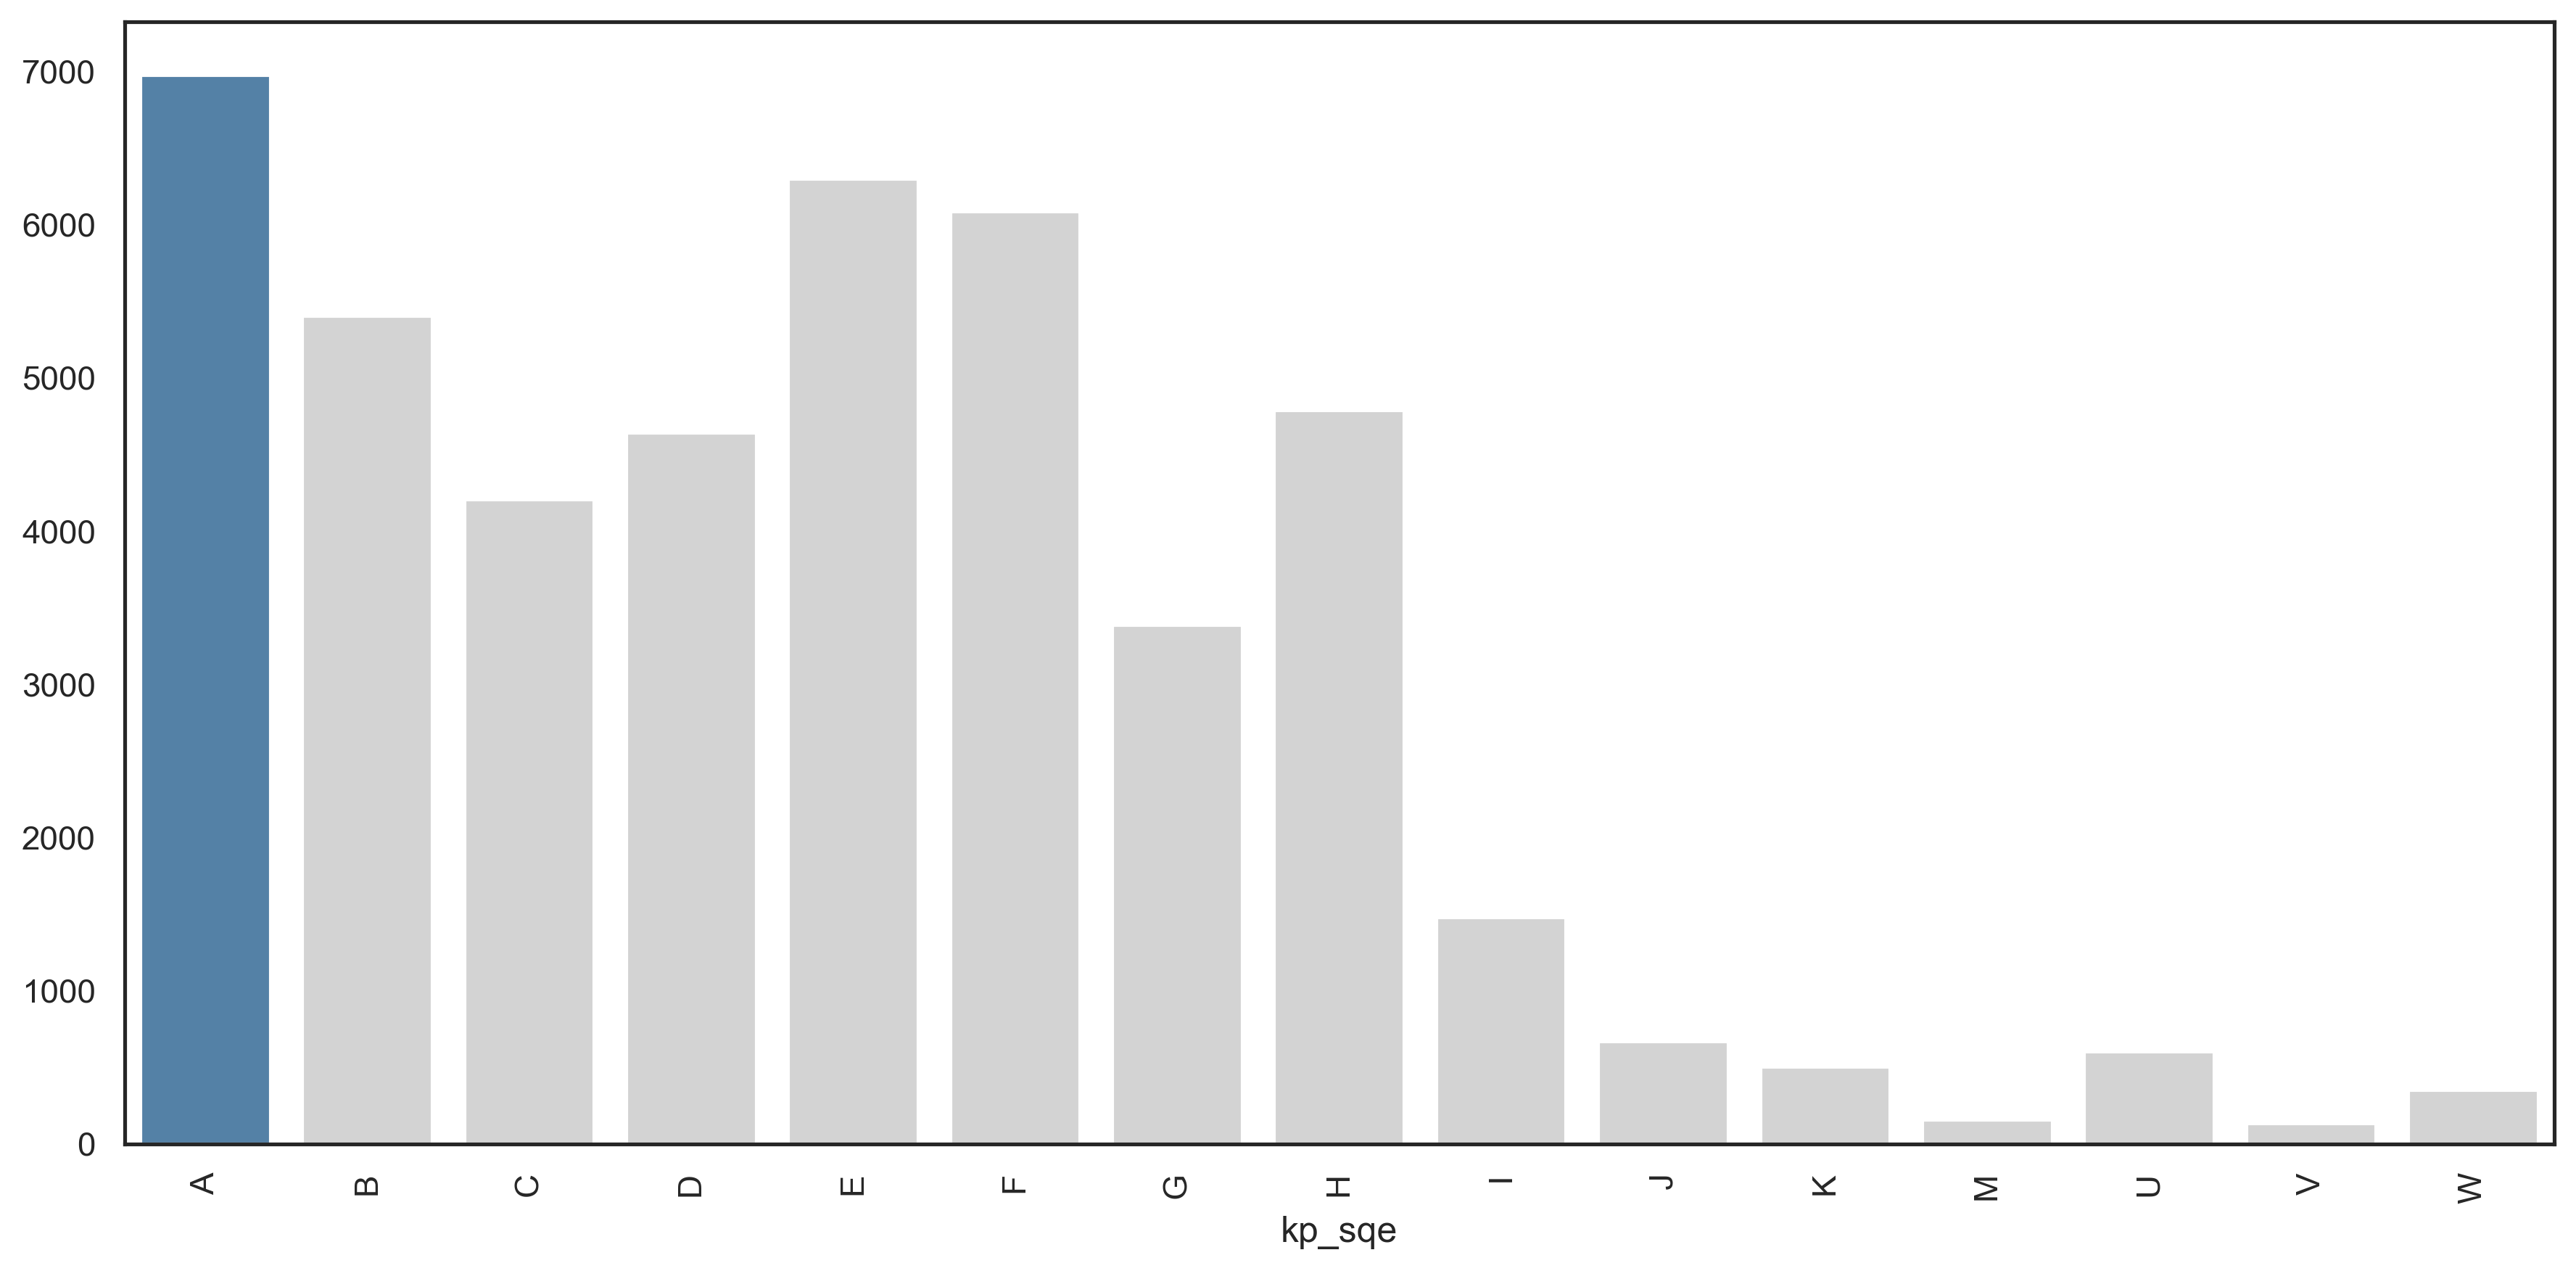

In [92]:
# Set white background style
sns.set_style('white')

# Column to plot
column_to_plot = 'kp_sqe'  # replace if needed

# Count observations per category
counts = CREDSCORE[column_to_plot].value_counts().sort_index()

# Category with the highest number of observations
max_category = counts.idxmax()

# Define colors
default_color = "lightgray"
highlight_color = "steelblue"

# Create palette
palette = [
    highlight_color if cat == max_category else default_color
    for cat in counts.index
]

# Plot
plt.figure(dpi=300, figsize=(12,6))
plt.gcf().patch.set_facecolor('white')

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=palette
)

# Rotate labels
plt.xticks(rotation=90)

# Layout
plt.tight_layout()

# Show
plt.show()


<a class="anchor" id="2.2 Analysing the Data">

## 3. Data Preparation
    
</a>

### 3.1. Handling Incoherencies

- Keeping only the last line (the most recent date) for each client.

In [76]:
CREDSCORE = CREDSCORE.sort_values(['CONTRIB','sys_data_procura'])
CREDSCORE = CREDSCORE.groupby('CONTRIB', as_index=False).tail(1)

In [77]:
print("shape:", CREDSCORE.shape)
print("clientes únicos:", CREDSCORE['CONTRIB'].nunique())
print("duplicados por cliente:", CREDSCORE.duplicated(subset=['CONTRIB']).sum())

shape: (62173, 5)
clientes únicos: 62173
duplicados por cliente: 0


In [78]:
# remover colunas técnicas
CREDSCORE = CREDSCORE.drop(columns=['sys_numero_submissao','sys_data_procura'], errors='ignore')

In [79]:
CREDSCORE.groupby(CREDSCORE['kp_sqe'].isna())['ks_score_tier'].describe()

,count,mean,std,min,25%,50%,75%,max
kp_sqe,,,,,,,,
False,44389.0,1.463944,0.738791,1.0,1.0,1.0,2.0,5.0
True,17784.0,1.844861,0.941910,1.0,1.0,2.0,3.0,5.0


- To analyse the *ks_score_tier* of the values with and without *kp_sqe* (tue= with missing values).
- In average, the clients with missing values have the average of the highest score, which means higher risk (as the company has less trust in them, it assumes higher incertainty).

### 3.2. Removing Duplicates

In [80]:
#droping duplicate rows 
CREDSCORE = CREDSCORE.drop_duplicates()

In [81]:
for col in CREDSCORE.columns:
    print(f"'{col}'")

'CONTRIB'
'kp_sqe'
'ks_score_tier'


In [99]:
'''CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'])

CREDSCORE = CREDSCORE.loc[
    CREDSCORE.groupby('CONTRIB')['sys_data_procura'].idxmax()
]

print(CREDSCORE)'''

"CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'])\n\nCREDSCORE = CREDSCORE.loc[\n    CREDSCORE.groupby('CONTRIB')['sys_data_procura'].idxmax()\n]\n\nprint(CREDSCORE)"

### 3.3. Handling Missing Values

In [82]:
#filling missing values
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].fillna('Unknown')

### 3.4. Handling Outliers

In [101]:
#CREDSCORE['ks_score_tier'] = CREDSCORE['ks_score_tier'].clip(upper=4)

### 3.5. Feature Engineering

In [83]:
#creating is_risky 
CREDSCORE['is_risky'] = (
    (CREDSCORE['kp_sqe'] > 'D') |
    (CREDSCORE['ks_score_tier'] > 2)
)

In [84]:
CREDSCORE['is_risky'].value_counts(dropna=False)

is_risky
True     42302
False    19871
Name: count, dtype: int64

In [85]:
CREDSCORE.head()

,CONTRIB,kp_sqe,ks_score_tier,is_risky
0,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,H,2.0,True
1,0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,D,1.0,False
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,F,3.0,True
3,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6eb42a2afd52d4e0d4a,A,1.0,False
4,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,H,1.0,True


<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# FAMA Dataset
       
</div>

**METADATA**
- *Date_Obs*: Observation Date (MMYY).
- *ALLBD_N_Dossiers__N*: Distinct count of Dossiers.
- *ALLBD_N_CL__N*: Distinct count of Dossiers for CL.
- *ALLBD_N_CP__N*: Distinct count of Dossiers for CP.
- *ALLBD_A_CL__N*: Distinct count of Dossiers for active CL.
- *ALLBD_A_CP__N*: Distinct count of Dossiers for active CP.
- *ALLBD_MTFINO_CL__N*: Number financings on CL - Total ammount.
- *ALLBD_MTFINO_CP__N*: Number financings on CP -Total ammount.
- *ALLBD_MTFIN_CL__N*: Presently financed on CL -present.
- *ALLBD_MTFIN_CP__N*: presently financed on CP -present.
- *ALLBD_IDADE_MSA__N*: max antiquity of contracts.
- *ALLBD_IDADE_MIN__N*: min antiquity of contracts.
- *ALLBD_IDADE_MEAN__N*: mean antiquity of contracts.
- *ALLBD_SUM_NUMFIN_CP__N*: Number Financings on CP  -lifetime.
- *ALLBD_mean_active_resso__N*: Average income from active contracts.
- *ALLBD_max_active_resso__N*: Maximum income from active contracts.
- *ALLBD_mean_duration_CL__N*: Average duration of CL contracts.
- *ALLBD_mean_lifecycle_CL__N*: Average lifecycle by duration on CL.
- *ALLBD_N_events__N*: Number of Contracts changes.
- *sdem_SITFAM*: Family Situation (C – married, D – divorced, S – single, U – cohabiting / partnered, V – widowed, X – other).
- *sdem_HABITAT*: Housing Situation (A – Access to property (loan), E – Housed by the employer (workplace), F – Housed by family, L – Tenant (rental), O – Other, P – Owner, X – Unknown). 
- *sdem_age*: Client's age.

<a class="anchor" id="2.2 Analysing the Data">

## 2. Analysing the Data
    
</a>

### 2.1. Data Overview

Neste dataset vamos olhar para o historico do cliente e nao para o que esta ativo.

In [86]:
FAMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141115 entries, 0 to 141114
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CONTRIB                     141115 non-null  object        
 1   Date_Obs                    141115 non-null  datetime64[ms]
 2   ALLBD_N_Dossiers__N         141115 non-null  float64       
 3   ALLBD_N_CL__N               141115 non-null  float64       
 4   ALLBD_N_CP__N               141115 non-null  float64       
 5   ALLBD_A_CL__N               141115 non-null  float64       
 6   ALLBD_A_CP__N               141115 non-null  float64       
 7   ALLBD_MTFINO_CL__N          141115 non-null  float64       
 8   ALLBD_MTFINO_CP__N          141115 non-null  float64       
 9   ALLBD_MTFIN_CL__N           141115 non-null  float64       
 10  ALLBD_MTFIN_CP__N           141115 non-null  float64       
 11  ALLBD_IDADE_MSA__N          141115 non-

In [87]:
num_cols = FAMA.select_dtypes(include=['number']).columns
obj_cols = FAMA.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(obj_cols))

Numerical: 19
Categorical: 3


In [88]:
pd.set_option('display.max_columns', None)
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b3ac4c2861934bdb984,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.0,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f4203e0d7e946045b89a7b,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.0,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d09e751e15cf4b6c2029,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.0,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c72305edb48e7f3bfa2396,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.0,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc19d5017c0c672a8de6,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.0,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [89]:
FAMA.describe().T

,count,mean,min,25%,50%,75%,max,std
Date_Obs,141115,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,NaN
ALLBD_N_Dossiers__N,141115.0,8.569727,1.0,4.0,7.0,11.0,136.0,6.21527
ALLBD_N_CL__N,141115.0,5.796868,0.0,3.0,5.0,8.0,91.0,4.768982
ALLBD_N_CP__N,141115.0,2.772859,0.0,1.0,2.0,4.0,81.0,2.302179
ALLBD_A_CL__N,141115.0,0.782319,0.0,0.0,1.0,1.0,7.0,0.61869
ALLBD_A_CP__N,141115.0,0.682911,0.0,0.0,1.0,1.0,9.0,0.79483
ALLBD_MTFINO_CL__N,141115.0,17305.858039,0.0,5000.0,11000.0,22324.89,436815.12,19565.305925
ALLBD_MTFINO_CP__N,141115.0,2890.91579,0.0,0.0,0.0,3187.78,322929.95,6739.935575
ALLBD_MTFIN_CL__N,141115.0,17459.8429,0.0,5000.0,11000.0,22500.0,996095.0,20332.811246
ALLBD_MTFIN_CP__N,141115.0,83.288209,-2649.0,0.0,0.0,9.485,8574.36,289.391822


In [90]:
#descriptive statistics for categorical data
FAMA.describe(include = ['O'])

,CONTRIB,sdem_SITFAM,sdem_HABITAT
count,141115,141115,141115
unique,141115,8,8
top,44ca1997fb28fe89d7114f2ff4c81d2619615bf6d5e736b451ca12a484b41973,C,A
freq,1,52752,45453


In [91]:
FAMA.shape

(141115, 23)

In [92]:
FAMA['CONTRIB'].nunique()

141115

In [93]:
FAMA['sdem_SITFAM'].value_counts(dropna=False)

sdem_SITFAM
C    52752
X    29322
S    27440
U    13184
D     9859
F     3163
P     2854
V     2541
Name: count, dtype: int64

- There are a large number of married (C), other (X), single (S) and cohabiting (U) people. 
- The least common are widowed

In [94]:
FAMA['sdem_HABITAT'].value_counts(dropna=False)

sdem_HABITAT
A    45453
F    40816
P    39321
L    14971
O      234
X      170
E      147
0        3
Name: count, dtype: int64

- Most people have access to property (loan), are housed by family and owned or rent a house.
- The least common is 'other' and housed by the employer.

### 2.2. Checking Duplicates

In [95]:
#checking number of duplicates
FAMA.duplicated().sum()

np.int64(0)

### 2.3. Checking Missing Values

In [96]:
#checking number of missing values
FAMA.isna().sum()

CONTRIB                       0
Date_Obs                      0
ALLBD_N_Dossiers__N           0
ALLBD_N_CL__N                 0
ALLBD_N_CP__N                 0
ALLBD_A_CL__N                 0
ALLBD_A_CP__N                 0
ALLBD_MTFINO_CL__N            0
ALLBD_MTFINO_CP__N            0
ALLBD_MTFIN_CL__N             0
ALLBD_MTFIN_CP__N             0
ALLBD_IDADE_MSA__N            0
ALLBD_IDADE_MIN__N            0
ALLBD_IDADE_MEAN__N           0
ALLBD_SUM_NUMFIN_CP__N        0
ALLBD_mean_active_resso__N    0
ALLBD_max_active_resso__N     0
ALLBD_mean_duration_CL__N     0
ALLBD_mean_lifecycle_CL__N    0
ALLBD_N_events__N             0
sdem_SITFAM                   0
sdem_HABITAT                  0
sdem_age                      0
dtype: int64

### 2.4. Checking Outliers

In [116]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

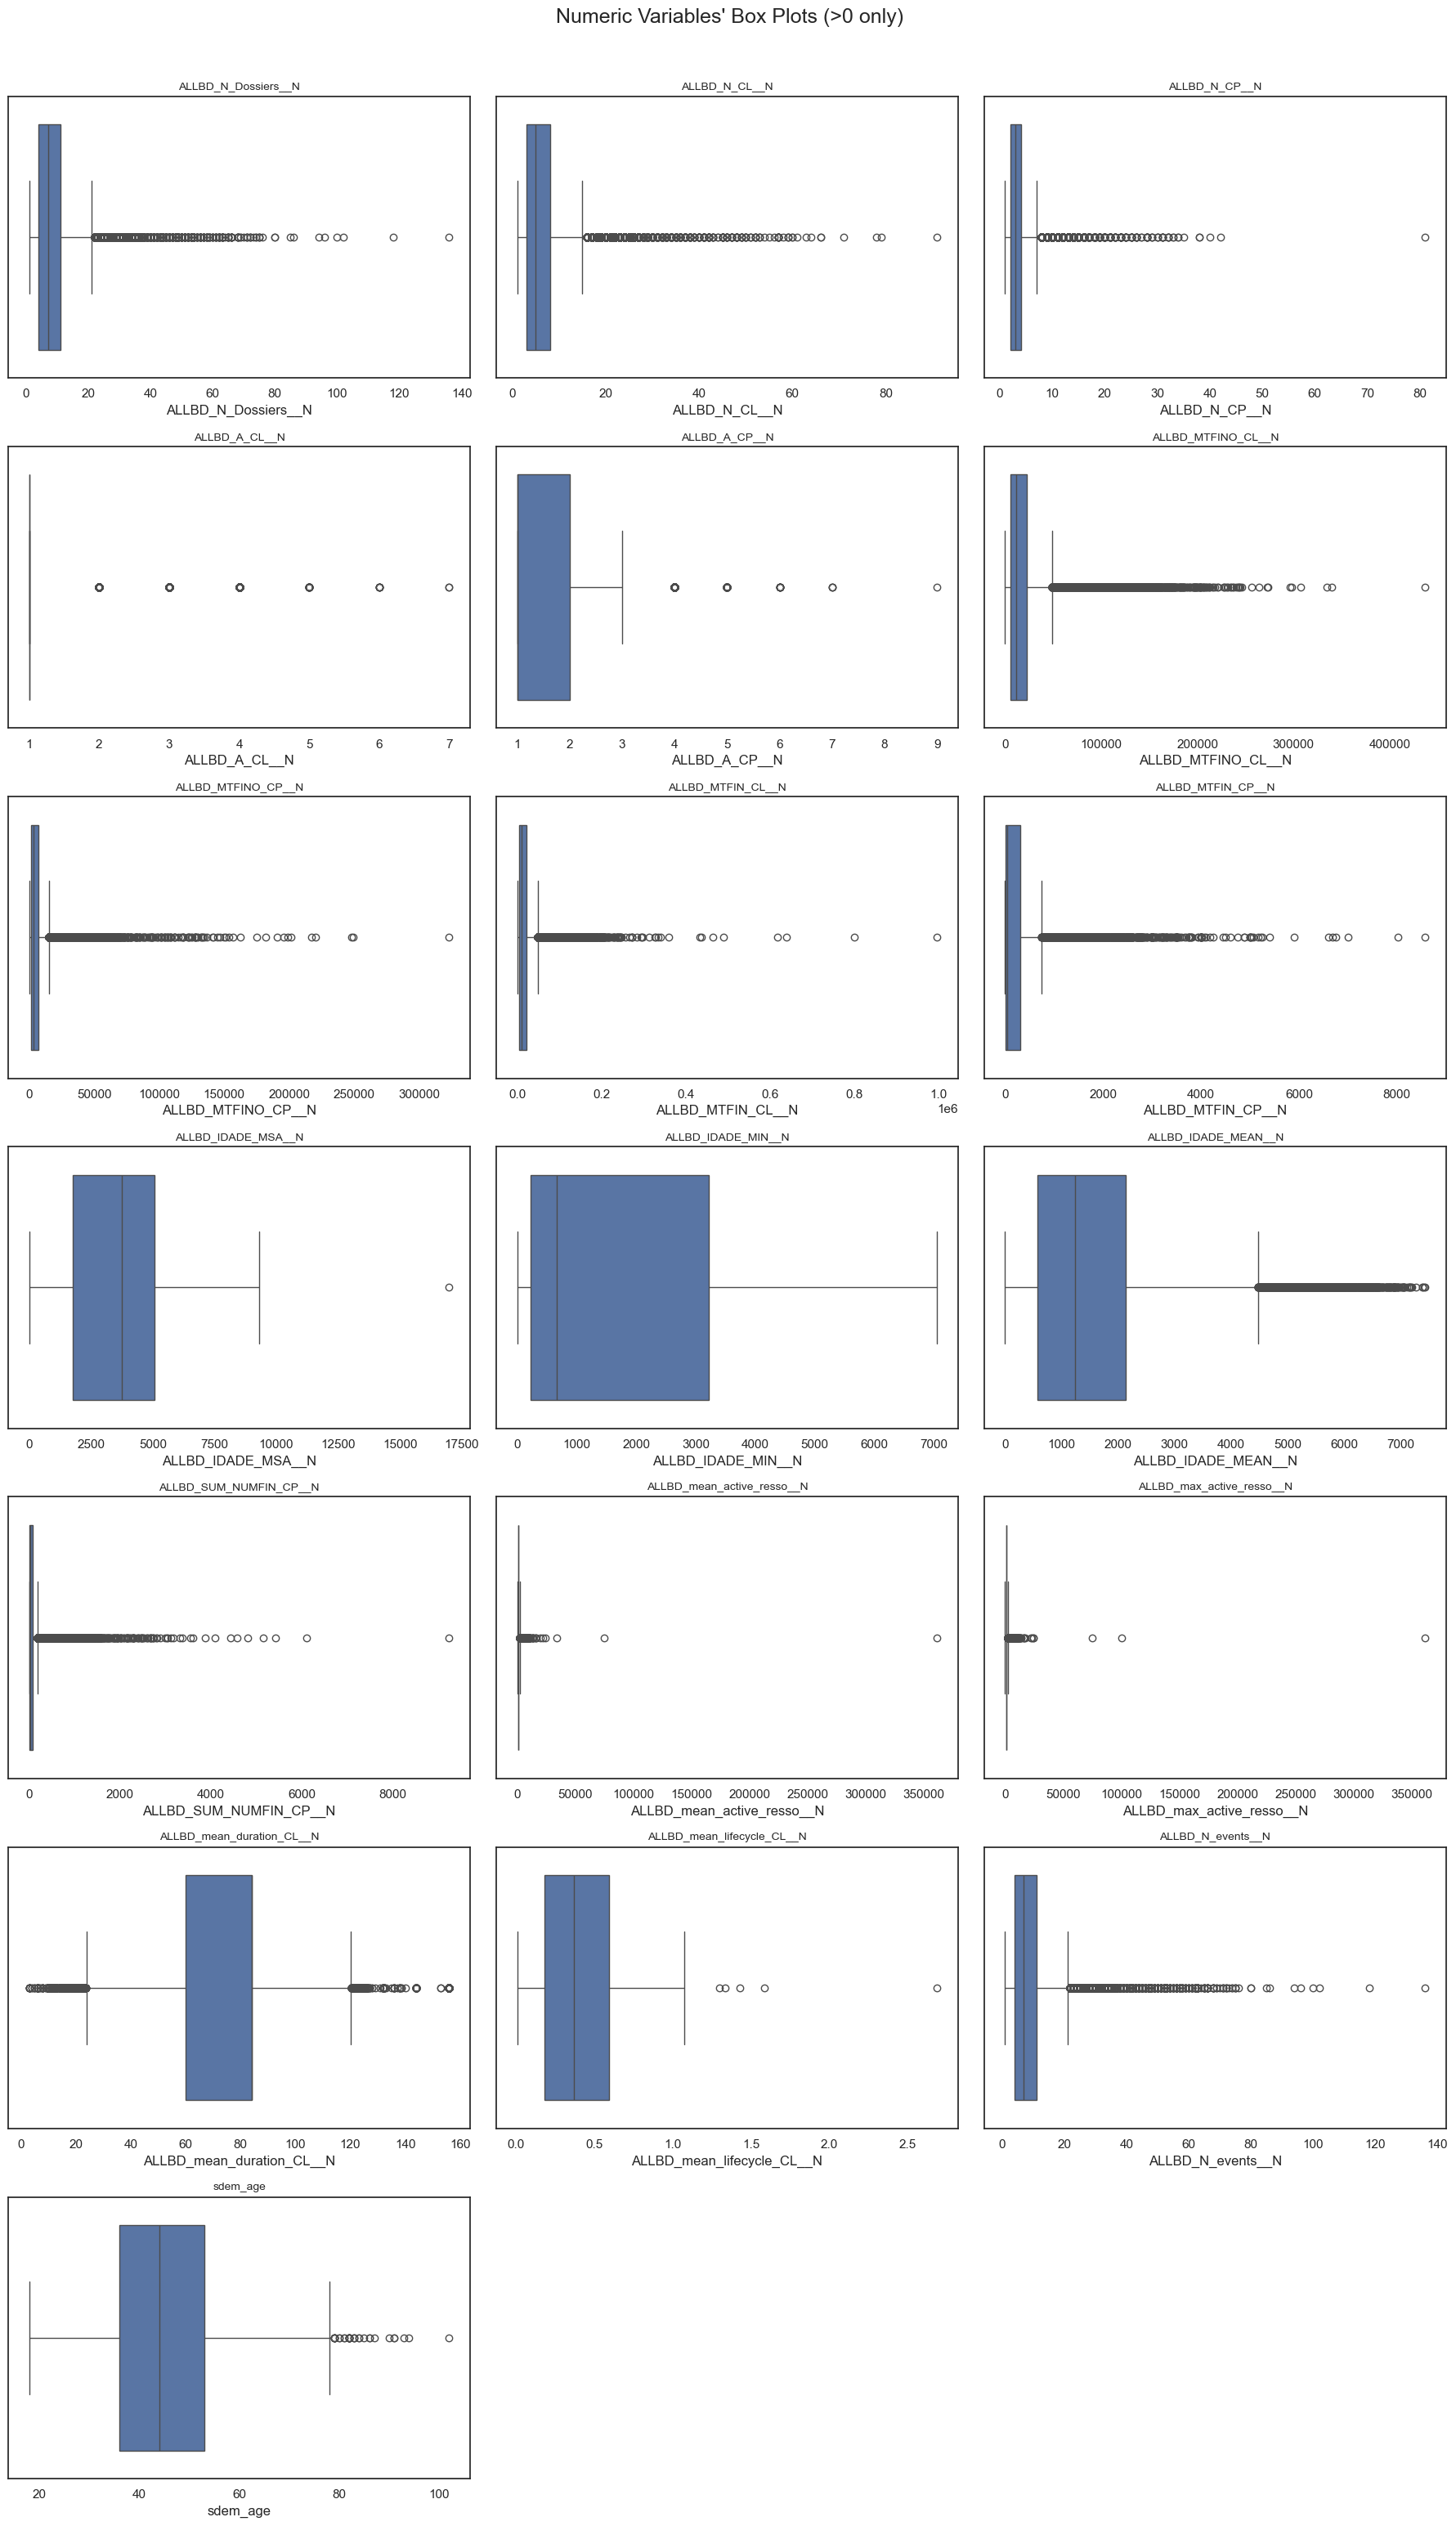

In [117]:
plot_multiple_boxplots(FAMA, num_cols)

In [97]:
FAMA[FAMA['ALLBD_N_Dossiers__N'] > 70].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [98]:
FAMA[FAMA['ALLBD_N_CL__N'] > 55].count()

CONTRIB                       24
Date_Obs                      24
ALLBD_N_Dossiers__N           24
ALLBD_N_CL__N                 24
ALLBD_N_CP__N                 24
ALLBD_A_CL__N                 24
ALLBD_A_CP__N                 24
ALLBD_MTFINO_CL__N            24
ALLBD_MTFINO_CP__N            24
ALLBD_MTFIN_CL__N             24
ALLBD_MTFIN_CP__N             24
ALLBD_IDADE_MSA__N            24
ALLBD_IDADE_MIN__N            24
ALLBD_IDADE_MEAN__N           24
ALLBD_SUM_NUMFIN_CP__N        24
ALLBD_mean_active_resso__N    24
ALLBD_max_active_resso__N     24
ALLBD_mean_duration_CL__N     24
ALLBD_mean_lifecycle_CL__N    24
ALLBD_N_events__N             24
sdem_SITFAM                   24
sdem_HABITAT                  24
sdem_age                      24
dtype: int64

In [99]:
FAMA[FAMA['ALLBD_N_CP__N'] > 30].count()

CONTRIB                       19
Date_Obs                      19
ALLBD_N_Dossiers__N           19
ALLBD_N_CL__N                 19
ALLBD_N_CP__N                 19
ALLBD_A_CL__N                 19
ALLBD_A_CP__N                 19
ALLBD_MTFINO_CL__N            19
ALLBD_MTFINO_CP__N            19
ALLBD_MTFIN_CL__N             19
ALLBD_MTFIN_CP__N             19
ALLBD_IDADE_MSA__N            19
ALLBD_IDADE_MIN__N            19
ALLBD_IDADE_MEAN__N           19
ALLBD_SUM_NUMFIN_CP__N        19
ALLBD_mean_active_resso__N    19
ALLBD_max_active_resso__N     19
ALLBD_mean_duration_CL__N     19
ALLBD_mean_lifecycle_CL__N    19
ALLBD_N_events__N             19
sdem_SITFAM                   19
sdem_HABITAT                  19
sdem_age                      19
dtype: int64

In [100]:
FAMA[FAMA['ALLBD_A_CL__N'] > 4].count()

CONTRIB                       35
Date_Obs                      35
ALLBD_N_Dossiers__N           35
ALLBD_N_CL__N                 35
ALLBD_N_CP__N                 35
ALLBD_A_CL__N                 35
ALLBD_A_CP__N                 35
ALLBD_MTFINO_CL__N            35
ALLBD_MTFINO_CP__N            35
ALLBD_MTFIN_CL__N             35
ALLBD_MTFIN_CP__N             35
ALLBD_IDADE_MSA__N            35
ALLBD_IDADE_MIN__N            35
ALLBD_IDADE_MEAN__N           35
ALLBD_SUM_NUMFIN_CP__N        35
ALLBD_mean_active_resso__N    35
ALLBD_max_active_resso__N     35
ALLBD_mean_duration_CL__N     35
ALLBD_mean_lifecycle_CL__N    35
ALLBD_N_events__N             35
sdem_SITFAM                   35
sdem_HABITAT                  35
sdem_age                      35
dtype: int64

In [101]:
FAMA[FAMA['ALLBD_A_CP__N'] > 5].count()

CONTRIB                       12
Date_Obs                      12
ALLBD_N_Dossiers__N           12
ALLBD_N_CL__N                 12
ALLBD_N_CP__N                 12
ALLBD_A_CL__N                 12
ALLBD_A_CP__N                 12
ALLBD_MTFINO_CL__N            12
ALLBD_MTFINO_CP__N            12
ALLBD_MTFIN_CL__N             12
ALLBD_MTFIN_CP__N             12
ALLBD_IDADE_MSA__N            12
ALLBD_IDADE_MIN__N            12
ALLBD_IDADE_MEAN__N           12
ALLBD_SUM_NUMFIN_CP__N        12
ALLBD_mean_active_resso__N    12
ALLBD_max_active_resso__N     12
ALLBD_mean_duration_CL__N     12
ALLBD_mean_lifecycle_CL__N    12
ALLBD_N_events__N             12
sdem_SITFAM                   12
sdem_HABITAT                  12
sdem_age                      12
dtype: int64

In [102]:
FAMA[FAMA['ALLBD_MTFINO_CL__N'] > 250000].count()

CONTRIB                       10
Date_Obs                      10
ALLBD_N_Dossiers__N           10
ALLBD_N_CL__N                 10
ALLBD_N_CP__N                 10
ALLBD_A_CL__N                 10
ALLBD_A_CP__N                 10
ALLBD_MTFINO_CL__N            10
ALLBD_MTFINO_CP__N            10
ALLBD_MTFIN_CL__N             10
ALLBD_MTFIN_CP__N             10
ALLBD_IDADE_MSA__N            10
ALLBD_IDADE_MIN__N            10
ALLBD_IDADE_MEAN__N           10
ALLBD_SUM_NUMFIN_CP__N        10
ALLBD_mean_active_resso__N    10
ALLBD_max_active_resso__N     10
ALLBD_mean_duration_CL__N     10
ALLBD_mean_lifecycle_CL__N    10
ALLBD_N_events__N             10
sdem_SITFAM                   10
sdem_HABITAT                  10
sdem_age                      10
dtype: int64

In [103]:
FAMA[FAMA['ALLBD_MTFINO_CP__N'] > 150000].count()

CONTRIB                       16
Date_Obs                      16
ALLBD_N_Dossiers__N           16
ALLBD_N_CL__N                 16
ALLBD_N_CP__N                 16
ALLBD_A_CL__N                 16
ALLBD_A_CP__N                 16
ALLBD_MTFINO_CL__N            16
ALLBD_MTFINO_CP__N            16
ALLBD_MTFIN_CL__N             16
ALLBD_MTFIN_CP__N             16
ALLBD_IDADE_MSA__N            16
ALLBD_IDADE_MIN__N            16
ALLBD_IDADE_MEAN__N           16
ALLBD_SUM_NUMFIN_CP__N        16
ALLBD_mean_active_resso__N    16
ALLBD_max_active_resso__N     16
ALLBD_mean_duration_CL__N     16
ALLBD_mean_lifecycle_CL__N    16
ALLBD_N_events__N             16
sdem_SITFAM                   16
sdem_HABITAT                  16
sdem_age                      16
dtype: int64

In [104]:
FAMA[FAMA['ALLBD_MTFIN_CL__N'] > 250000].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [105]:
FAMA[FAMA['ALLBD_MTFIN_CP__N'] > 4000].count()

CONTRIB                       29
Date_Obs                      29
ALLBD_N_Dossiers__N           29
ALLBD_N_CL__N                 29
ALLBD_N_CP__N                 29
ALLBD_A_CL__N                 29
ALLBD_A_CP__N                 29
ALLBD_MTFINO_CL__N            29
ALLBD_MTFINO_CP__N            29
ALLBD_MTFIN_CL__N             29
ALLBD_MTFIN_CP__N             29
ALLBD_IDADE_MSA__N            29
ALLBD_IDADE_MIN__N            29
ALLBD_IDADE_MEAN__N           29
ALLBD_SUM_NUMFIN_CP__N        29
ALLBD_mean_active_resso__N    29
ALLBD_max_active_resso__N     29
ALLBD_mean_duration_CL__N     29
ALLBD_mean_lifecycle_CL__N    29
ALLBD_N_events__N             29
sdem_SITFAM                   29
sdem_HABITAT                  29
sdem_age                      29
dtype: int64

In [106]:
FAMA[FAMA['ALLBD_IDADE_MSA__N'] > 10000].count()

CONTRIB                       1
Date_Obs                      1
ALLBD_N_Dossiers__N           1
ALLBD_N_CL__N                 1
ALLBD_N_CP__N                 1
ALLBD_A_CL__N                 1
ALLBD_A_CP__N                 1
ALLBD_MTFINO_CL__N            1
ALLBD_MTFINO_CP__N            1
ALLBD_MTFIN_CL__N             1
ALLBD_MTFIN_CP__N             1
ALLBD_IDADE_MSA__N            1
ALLBD_IDADE_MIN__N            1
ALLBD_IDADE_MEAN__N           1
ALLBD_SUM_NUMFIN_CP__N        1
ALLBD_mean_active_resso__N    1
ALLBD_max_active_resso__N     1
ALLBD_mean_duration_CL__N     1
ALLBD_mean_lifecycle_CL__N    1
ALLBD_N_events__N             1
sdem_SITFAM                   1
sdem_HABITAT                  1
sdem_age                      1
dtype: int64

In [107]:
FAMA[FAMA['ALLBD_SUM_NUMFIN_CP__N'] > 3000].count()

CONTRIB                       17
Date_Obs                      17
ALLBD_N_Dossiers__N           17
ALLBD_N_CL__N                 17
ALLBD_N_CP__N                 17
ALLBD_A_CL__N                 17
ALLBD_A_CP__N                 17
ALLBD_MTFINO_CL__N            17
ALLBD_MTFINO_CP__N            17
ALLBD_MTFIN_CL__N             17
ALLBD_MTFIN_CP__N             17
ALLBD_IDADE_MSA__N            17
ALLBD_IDADE_MIN__N            17
ALLBD_IDADE_MEAN__N           17
ALLBD_SUM_NUMFIN_CP__N        17
ALLBD_mean_active_resso__N    17
ALLBD_max_active_resso__N     17
ALLBD_mean_duration_CL__N     17
ALLBD_mean_lifecycle_CL__N    17
ALLBD_N_events__N             17
sdem_SITFAM                   17
sdem_HABITAT                  17
sdem_age                      17
dtype: int64

In [108]:
FAMA[FAMA['ALLBD_mean_active_resso__N'] > 10000].count()

CONTRIB                       24
Date_Obs                      24
ALLBD_N_Dossiers__N           24
ALLBD_N_CL__N                 24
ALLBD_N_CP__N                 24
ALLBD_A_CL__N                 24
ALLBD_A_CP__N                 24
ALLBD_MTFINO_CL__N            24
ALLBD_MTFINO_CP__N            24
ALLBD_MTFIN_CL__N             24
ALLBD_MTFIN_CP__N             24
ALLBD_IDADE_MSA__N            24
ALLBD_IDADE_MIN__N            24
ALLBD_IDADE_MEAN__N           24
ALLBD_SUM_NUMFIN_CP__N        24
ALLBD_mean_active_resso__N    24
ALLBD_max_active_resso__N     24
ALLBD_mean_duration_CL__N     24
ALLBD_mean_lifecycle_CL__N    24
ALLBD_N_events__N             24
sdem_SITFAM                   24
sdem_HABITAT                  24
sdem_age                      24
dtype: int64

In [109]:
FAMA[FAMA['ALLBD_max_active_resso__N'] > 15000].count()

CONTRIB                       11
Date_Obs                      11
ALLBD_N_Dossiers__N           11
ALLBD_N_CL__N                 11
ALLBD_N_CP__N                 11
ALLBD_A_CL__N                 11
ALLBD_A_CP__N                 11
ALLBD_MTFINO_CL__N            11
ALLBD_MTFINO_CP__N            11
ALLBD_MTFIN_CL__N             11
ALLBD_MTFIN_CP__N             11
ALLBD_IDADE_MSA__N            11
ALLBD_IDADE_MIN__N            11
ALLBD_IDADE_MEAN__N           11
ALLBD_SUM_NUMFIN_CP__N        11
ALLBD_mean_active_resso__N    11
ALLBD_max_active_resso__N     11
ALLBD_mean_duration_CL__N     11
ALLBD_mean_lifecycle_CL__N    11
ALLBD_N_events__N             11
sdem_SITFAM                   11
sdem_HABITAT                  11
sdem_age                      11
dtype: int64

In [110]:
FAMA[FAMA['ALLBD_mean_lifecycle_CL__N'] > 1].count()

CONTRIB                       16
Date_Obs                      16
ALLBD_N_Dossiers__N           16
ALLBD_N_CL__N                 16
ALLBD_N_CP__N                 16
ALLBD_A_CL__N                 16
ALLBD_A_CP__N                 16
ALLBD_MTFINO_CL__N            16
ALLBD_MTFINO_CP__N            16
ALLBD_MTFIN_CL__N             16
ALLBD_MTFIN_CP__N             16
ALLBD_IDADE_MSA__N            16
ALLBD_IDADE_MIN__N            16
ALLBD_IDADE_MEAN__N           16
ALLBD_SUM_NUMFIN_CP__N        16
ALLBD_mean_active_resso__N    16
ALLBD_max_active_resso__N     16
ALLBD_mean_duration_CL__N     16
ALLBD_mean_lifecycle_CL__N    16
ALLBD_N_events__N             16
sdem_SITFAM                   16
sdem_HABITAT                  16
sdem_age                      16
dtype: int64

In [111]:
FAMA[FAMA['ALLBD_N_events__N'] > 70].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [112]:
FAMA[FAMA['sdem_age'] > 85].count()

CONTRIB                       9
Date_Obs                      9
ALLBD_N_Dossiers__N           9
ALLBD_N_CL__N                 9
ALLBD_N_CP__N                 9
ALLBD_A_CL__N                 9
ALLBD_A_CP__N                 9
ALLBD_MTFINO_CL__N            9
ALLBD_MTFINO_CP__N            9
ALLBD_MTFIN_CL__N             9
ALLBD_MTFIN_CP__N             9
ALLBD_IDADE_MSA__N            9
ALLBD_IDADE_MIN__N            9
ALLBD_IDADE_MEAN__N           9
ALLBD_SUM_NUMFIN_CP__N        9
ALLBD_mean_active_resso__N    9
ALLBD_max_active_resso__N     9
ALLBD_mean_duration_CL__N     9
ALLBD_mean_lifecycle_CL__N    9
ALLBD_N_events__N             9
sdem_SITFAM                   9
sdem_HABITAT                  9
sdem_age                      9
dtype: int64

### 2.5. Checking Distribution

#### 2.5.1. Numerical Variables

In [134]:
df= pd.DataFrame(FAMA[num_cols])

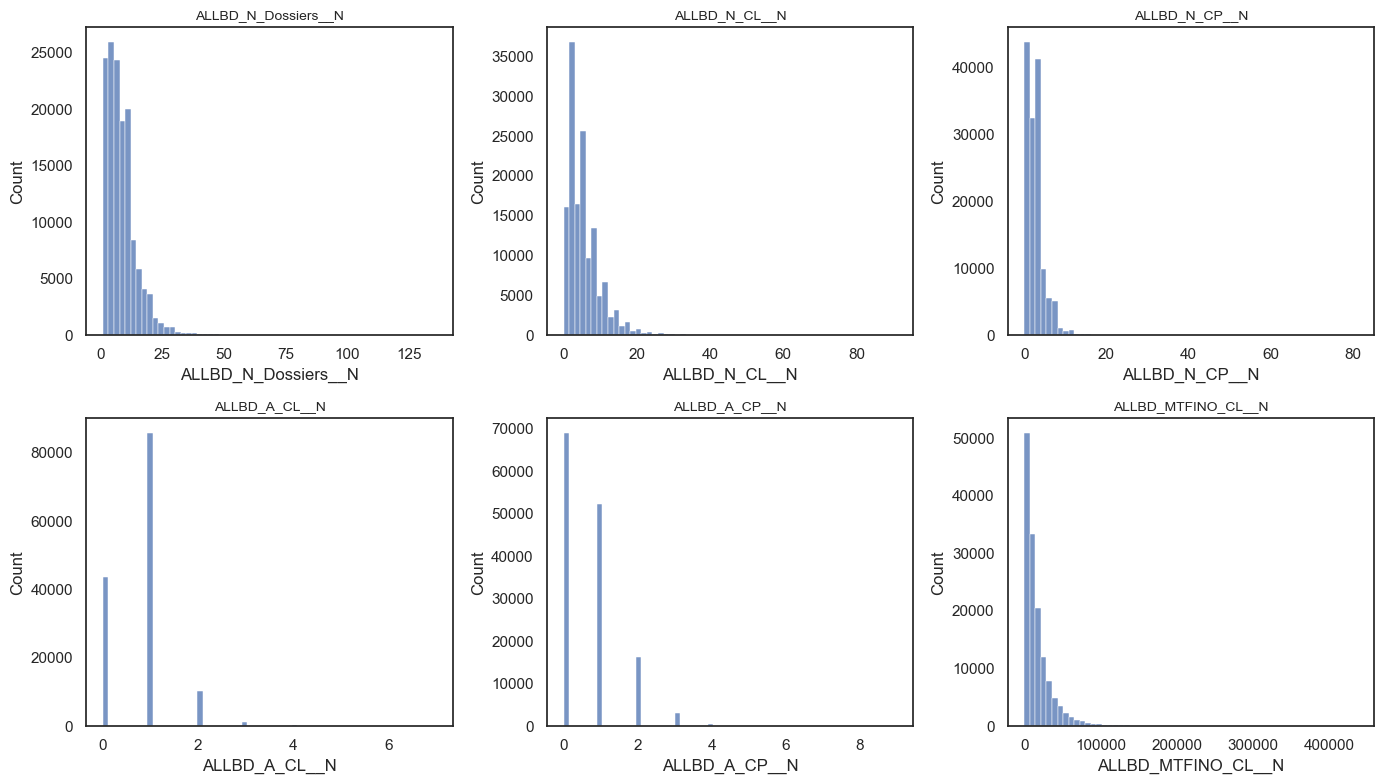

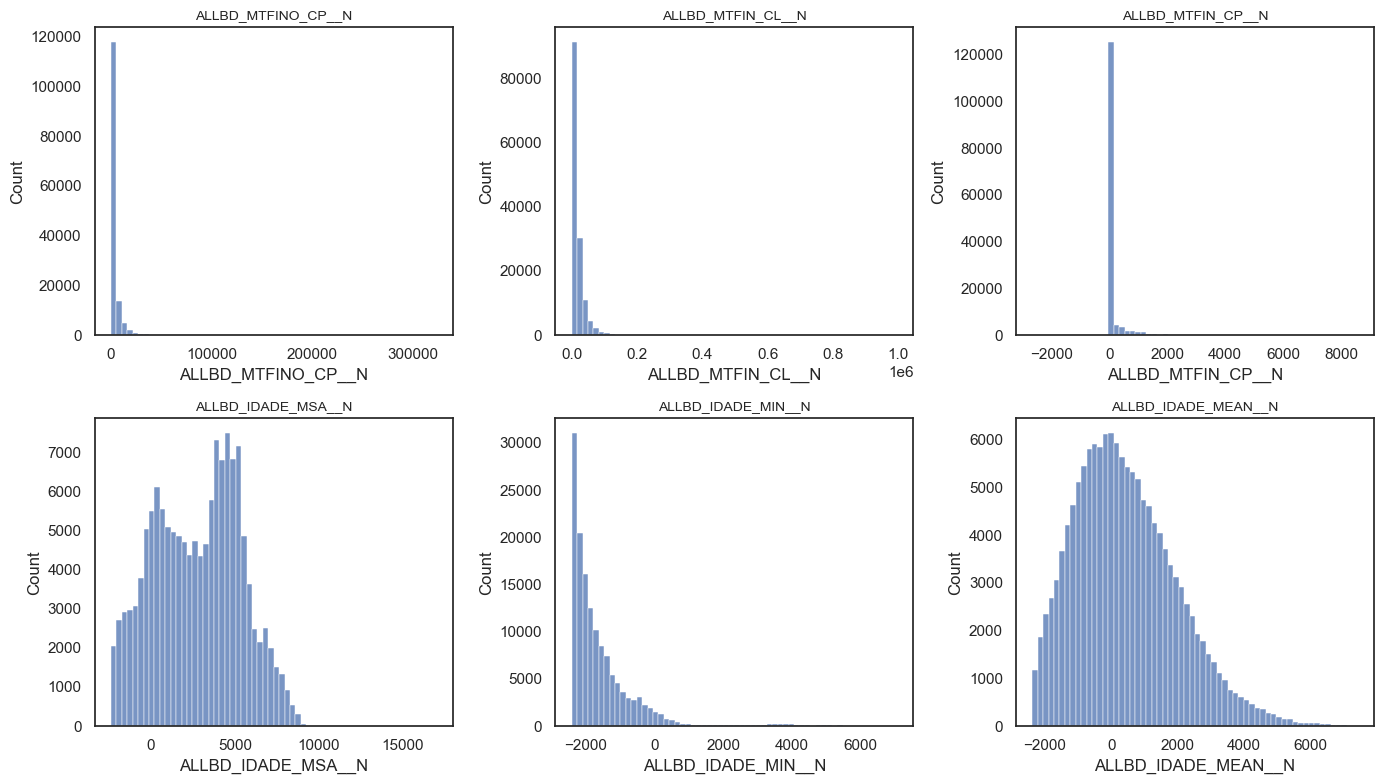

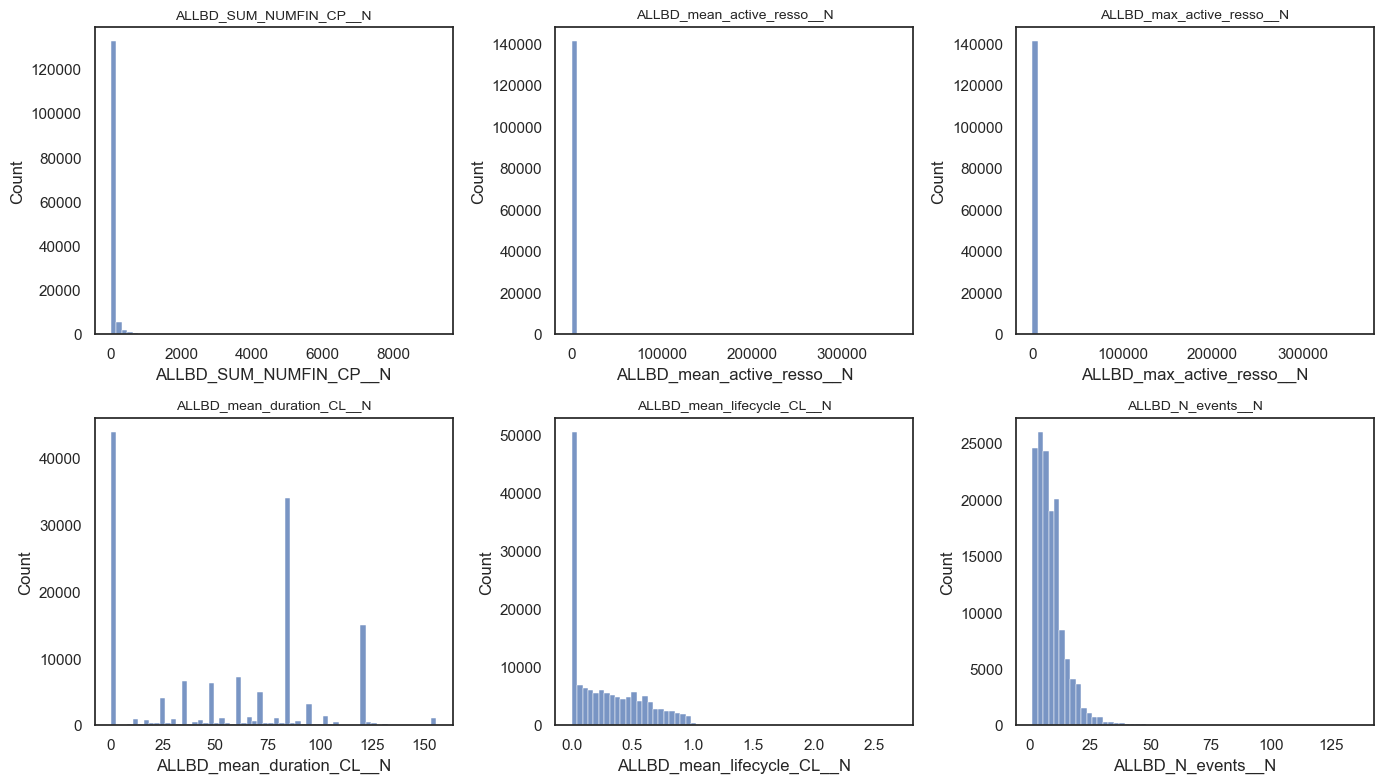

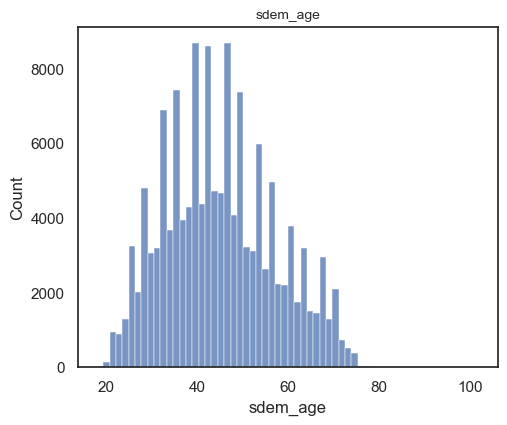

In [135]:
# Sampling
N = 200_000
sample = FAMA.sample(n=min(N, len(FAMA)), random_state=42)

cols = sample.select_dtypes(include=[np.number]).columns  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

#### 2.5.2. Categorical Variables

In [136]:
# Set white background style
sns.set_style('white')


# Loop through each variable
for column in obj_cols:
    
    # Count observations per category
    counts = CREDSCORE[column].value_counts().sort_index()

    # Category with the highest number of observations
    max_category = counts.idxmax()

    # Define colors
    default_color = "lightgray"
    highlight_color = "steelblue"

    # Create palette
    palette = [
        highlight_color if cat == max_category else default_color
        for cat in counts.index
    ]

    # Plot
    plt.figure(dpi=300, figsize=(12,6))
    plt.gcf().patch.set_facecolor('white')

    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette=palette
    )

    # Title
    plt.title(f'Distribution of {column}')

    # Rotate labels
    plt.xticks(rotation=90)

    # Layout
    plt.tight_layout()

    # Show
    plt.show()

C:\Users\jcari\AppData\Local\Temp\ipykernel_38896\1837695137.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jcari\AppData\Local\Temp\ipykernel_38896\1837695137.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 

In [ ]:
# Set white background style
sns.set_style("white")

# Create subplots
fig, axes = plt.subplots(1, len(obj_cols), figsize=(18,5), dpi=300)

# Ensure axes is iterable if only one plot
if len(obj_cols) == 1:
    axes = [axes]

for ax, column in zip(axes, obj_cols):

    counts = CREDSCORE[column].value_counts()
    max_category = counts.idxmax()

    # Create palette
    palette = {
        cat: "steelblue" if cat == max_category else "lightgray"
        for cat in CREDSCORE[column].dropna().unique()
    }

    sns.countplot(
        data=CREDSCORE,
        x=column,
        palette=palette,
        order=sorted(CREDSCORE[column].dropna().unique()),
        ax=ax
    )

    ax.set_title(f'Distribution of {column}')
    ax.tick_params(axis='x', rotation=90)

# Layout
plt.tight_layout()
plt.show()

### 2.6. Checking Correlation between variables

In [137]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = FAMA[num_cols].corr(method ='spearman')
cor_spearman

,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age
ALLBD_N_Dossiers__N,1.000000,0.927566,0.731157,0.108140,0.246939,0.388763,0.284660,0.392554,0.192713,0.486802,-0.252399,0.315369,0.276960,0.166793,0.183376,0.098130,0.021250,0.999999,0.107667
ALLBD_N_CL__N,0.927566,1.000000,0.452514,0.134069,0.105994,0.448910,0.168801,0.452658,0.100483,0.444684,-0.234501,0.288707,0.163949,0.133789,0.146695,0.121406,0.035402,0.927565,0.111628
ALLBD_N_CP__N,0.731157,0.452514,1.000000,0.022706,0.420731,0.134530,0.396886,0.137201,0.293239,0.394368,-0.189690,0.258184,0.386518,0.164473,0.182269,0.018513,-0.010357,0.731158,0.068914
ALLBD_A_CL__N,0.108140,0.134069,0.022706,1.000000,0.067870,0.308200,0.028831,0.305528,0.046033,-0.046302,-0.274658,-0.162982,0.033178,0.399688,0.423781,0.746659,0.750407,0.108142,-0.015952
ALLBD_A_CP__N,0.246939,0.105994,0.420731,0.067870,1.000000,-0.004449,0.831273,-0.004615,0.669278,0.049498,-0.194734,-0.057555,0.810063,0.330669,0.370518,0.007268,0.030222,0.246944,0.013055
ALLBD_MTFINO_CL__N,0.388763,0.448910,0.134530,0.308200,-0.004449,1.000000,0.018045,0.998125,-0.020906,0.219766,-0.014698,0.157703,0.004661,0.223295,0.241692,0.455095,0.184296,0.388761,0.162105
ALLBD_MTFINO_CP__N,0.284660,0.168801,0.396886,0.028831,0.831273,0.018045,1.000000,0.019218,0.696048,0.119279,-0.142322,0.033532,0.966993,0.273915,0.313260,-0.008823,0.000644,0.284665,0.047066
ALLBD_MTFIN_CL__N,0.392554,0.452658,0.137201,0.305528,-0.004615,0.998125,0.019218,1.000000,-0.021329,0.229486,-0.012624,0.166521,0.005734,0.222905,0.241318,0.452091,0.182433,0.392553,0.167999
ALLBD_MTFIN_CP__N,0.192713,0.100483,0.293239,0.046033,0.669278,-0.020906,0.696048,-0.021329,1.000000,-0.000997,-0.250088,-0.104876,0.688639,0.250848,0.273812,-0.007455,-0.016425,0.192715,-0.043044
ALLBD_IDADE_MSA__N,0.486802,0.444684,0.394368,-0.046302,0.049498,0.219766,0.119279,0.229486,-0.000997,1.000000,0.122483,0.859910,0.104160,0.075105,0.085475,-0.004586,-0.007312,0.486804,0.477206


In [138]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

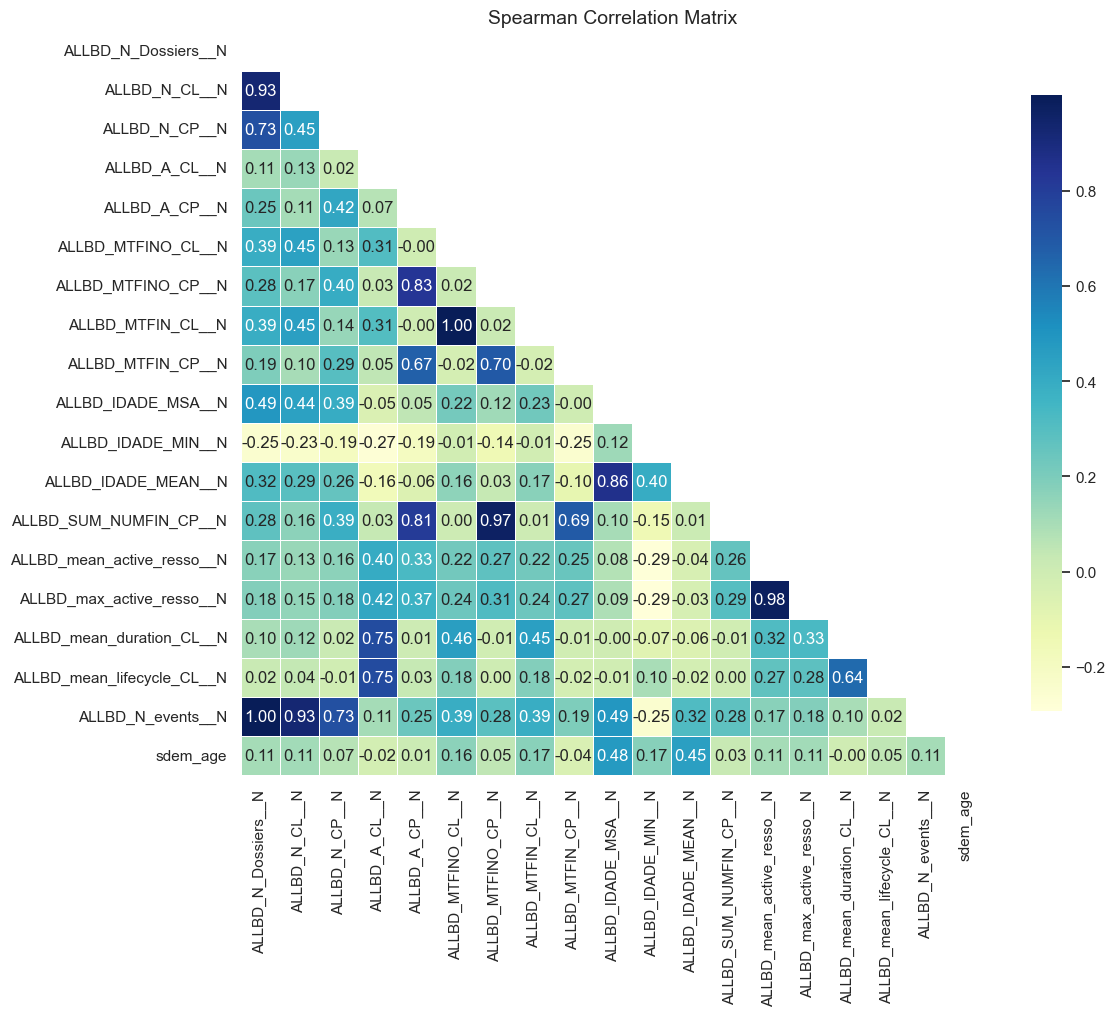

In [139]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

**Redundant Variables**:
- *ALLBD_N_CL__N* vs *ALLBD_N_Dossiers__N* (0.93)
- *ALLBD_N_Dossiers__N* vs *ALLBD_N_events__N* (1.00)
- *ALLBD_N_events__N* vs *ALLBD_N_CL__N* (0.93)

<a class="anchor" id="2.2 Analysing the Data">

## 3. Data Preparation
    
</a>

### 3.1. Handling Outliers

In [113]:
FAMA['ALLBD_N_Dossiers__N'] = FAMA['ALLBD_N_Dossiers__N'].clip(upper=70)
FAMA['ALLBD_N_CL__N'] = FAMA['ALLBD_N_CL__N'].clip(upper=55)
FAMA['ALLBD_N_CP__N'] = FAMA['ALLBD_N_CP__N'].clip(upper=30)
FAMA['ALLBD_A_CL__N'] = FAMA['ALLBD_A_CL__N'].clip(upper=4)
FAMA['ALLBD_A_CP__N'] = FAMA['ALLBD_A_CP__N'].clip(upper=5)
FAMA['ALLBD_MTFINO_CL__N'] = FAMA['ALLBD_MTFINO_CL__N'].clip(upper=250000)
FAMA['ALLBD_MTFINO_CP__N'] = FAMA['ALLBD_MTFINO_CP__N'].clip(upper=150000)
FAMA['ALLBD_MTFIN_CL__N'] = FAMA['ALLBD_MTFIN_CL__N'].clip(upper=250000)
FAMA['ALLBD_MTFIN_CP__N'] = FAMA['ALLBD_MTFIN_CP__N'].clip(upper=4000)
FAMA['ALLBD_IDADE_MSA__N'] = FAMA['ALLBD_IDADE_MSA__N'].clip(upper=10000)
FAMA['ALLBD_SUM_NUMFIN_CP__N'] = FAMA['ALLBD_SUM_NUMFIN_CP__N'].clip(upper=3000)
FAMA['ALLBD_mean_active_resso__N'] = FAMA['ALLBD_mean_active_resso__N'].clip(upper=10000)
FAMA['ALLBD_max_active_resso__N'] = FAMA['ALLBD_max_active_resso__N'].clip(upper=15000)
FAMA['ALLBD_mean_lifecycle_CL__N'] = FAMA['ALLBD_mean_lifecycle_CL__N'].clip(upper=1)
FAMA['ALLBD_N_events__N'] = FAMA['ALLBD_N_events__N'].clip(upper=70)
FAMA['sdem_age'] = FAMA['sdem_age'].clip(upper=85)

### 3.2. Feature Engineering

In [114]:
# proporção de créditos ativos

FAMA["active_credit_ratio"] = (
    FAMA["ALLBD_A_CL__N"] + FAMA["ALLBD_A_CP__N"]
) / (
    FAMA["ALLBD_N_CL__N"] + FAMA["ALLBD_N_CP__N"] + 1
)

In [115]:
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b3ac4c2861934bdb984,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.0,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62,0.062500
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f4203e0d7e946045b89a7b,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.0,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65,0.428571
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d09e751e15cf4b6c2029,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.0,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65,0.111111
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c72305edb48e7f3bfa2396,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.0,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69,0.250000
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc19d5017c0c672a8de6,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.0,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68,0.100000


In [143]:
# carga financeira (montante de crédito vs rendimento)
'''FAMA["debt_income_ratio"] = (
    FAMA["ALLBD_MTFIN_CL__N"] /
    (FAMA["ALLBD_mean_active_resso__N"] + 1)
)'''

'FAMA["debt_income_ratio"] = (\n    FAMA["ALLBD_MTFIN_CL__N"] /\n    (FAMA["ALLBD_mean_active_resso__N"] + 1)\n)'

In [144]:
# ratio de progresso do crédito

'''FAMA["credit_progress"] = (
    FAMA["ALLBD_MTFIN_CL__N "] /
    (FAMA["ALLBD_MTFINO_CL__N "] + 1)
)'''

'FAMA["credit_progress"] = (\n    FAMA["ALLBD_MTFIN_CL__N "] /\n    (FAMA["ALLBD_MTFINO_CL__N "] + 1)\n)'

In [145]:
# percentagem de credito por pagar

'''FAMA["credit_remaining_ratio"] = (
    FAMA["ALLBD_MTFIN_CL__N"] /
    (FAMA["ALLBD_MTFINO_CL__N"] + 1)
)'''

'FAMA["credit_remaining_ratio"] = (\n    FAMA["ALLBD_MTFIN_CL__N"] /\n    (FAMA["ALLBD_MTFINO_CL__N"] + 1)\n)'

In [116]:
drop=['Date_Obs', 'ALLBD_N_Dossiers__N', 'ALLBD_N_CL__N', 
      'ALLBD_N_CP__N', 'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 
      'ALLBD_MTFINO_CL__N', 'ALLBD_MTFINO_CP__N', 
      'ALLBD_MTFIN_CL__N', 'ALLBD_MTFIN_CP__N', 
      'ALLBD_IDADE_MSA__N', 'ALLBD_IDADE_MIN__N',
      'ALLBD_IDADE_MEAN__N', 'ALLBD_SUM_NUMFIN_CP__N', 
      'ALLBD_max_active_resso__N', 'ALLBD_mean_active_resso__N']
FAMA= FAMA.drop(columns=drop, errors='ignore')

- We have decided to drop these variables due to their amount of incoherencies and the redundance between some of them. 

In [117]:
FAMA.head()

,CONTRIB,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b3ac4c2861934bdb984,120.0,0.425000,15.0,C,P,62,0.062500
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f4203e0d7e946045b89a7b,72.0,0.138889,6.0,C,A,65,0.428571
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d09e751e15cf4b6c2029,36.0,0.277778,8.0,C,L,65,0.111111
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c72305edb48e7f3bfa2396,72.0,0.138889,3.0,V,P,69,0.250000
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc19d5017c0c672a8de6,48.0,0.916667,9.0,C,A,68,0.100000


<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# BDOSS Dataset
       
</div>

<a class="anchor" id="2.2 Analysing the Data">

## 2. Analysing the Data
    
</a>

**METADATA**
- *DOSSIER*: Dossier Number.
- *POLE*: Business unit (D - D & A; N - NCP; P - Direct).
- *TYPEPROD*: Product Type (CL - Classic; CP - Permanent Account).
- *PRODALP*: Product Type (AUR, AX7, B2K, BM7, etc).
- *BICONTRATO*: Co-signataries
- *POS*: Dossier classification (SOL – client settles on the contract‑termination date; SAN – client settles before that date).
- *OBS_DATE*: Observation Date.
- *DCREAT*: Dossier Creation Date.
- *DATFIN*: Last financing date.
- *D1FIN*: First financing date.
- *DPOS*: Dossier position date.
- *DURDEG*: Number of regularizations (instalments).
- *RANGPRO*: Number of regularizations payed.
- *RANGCLI*: Maximum number of monthly payment delays.
- *MTFINO*: Amount financed from dossier opening.
- *MTFIN*: Fiananced amount in dossier.
- *MENSALIDADE*: Monthly instalment.
- *MENSALIDADE_CORR*: Current Monthly instalment.
- *CRD*: Capital Amount still due.
- *SREC*: Outstanding Balance.
- *ACTIVIDADE_GLOBAL*: Dossier Global activity (Active; Ex-Active; Inactive).
- *RN*: How many times in the last 12 months a payment was not made in due time. 
- *RD*: Whenever a payment is not due in time, it takes more or less time to reciver, this isthe accumulated number of months that a payment took to be collected. 
- *RISK*: Chain with risk positions in last 24 months.
- *RISKA*: Dossier risk position on the last month.
- *AGFIN*: Financing agency.
- *PAGAMENTO*: Selected payment option for installments.
- *RESSO*: Wage of the contract’s primary holder.
- *CSP*: Socio‑professional code (10 – Merchants; 15 – Service Providers; 20 – Managing Partners/Partners; 30 – Private Directors – Senior Management; 31 – Private Department Heads – Middle Management; 40 – Public Directors – Senior Management; 41 – Public Department Heads – Middle Management; 60 – Office Employees – Commerce; 70 – Public Employees; 74 – Military/Police; 80 – Workers; 81 – Driver‑Security; 86 – Cleaning Staff; 90 – Retired Private‑Sector; 91 – Retired Public‑Sector; 92 – Unemployed/No Profession; 96 – Fixed‑term/Temporary Contractor; 99 – Indeterminate; 25 – Pension Income;
32 – Health Professional; 33 – Nurse; 34 – Doctor; 35 – Teacher).
- *DCSP*: Date of the socio‑professional code.
- *NATIO*: Nationality (C – European Union; D – Other; P – Portuguese; X – Unknown).
- *PTT*: Postal code. 
- *NBENF*: Number of dependents. 
- *MODCONTACTO*: Contact mode (A – Credscore; C – Mail; E – Outbound calls;
H – Homebanking; K – Click-to-call; M – Email; Q – Telematics; S – SMS; T – Telephone; V – Agency visit; W – Web telematics; X – Cetelem Center).

### 2.1. Data Overview

In [118]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [119]:
pd.set_option('display.max_columns', None)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32a1a99618e5be83ced1,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e717514560542d65af5e63e2157,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e61d70dcb3944412ecac,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6236580eb19aa138a56,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A


In [120]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [121]:
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bdc4db94c94e6646dde6,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


### 2.2. Checking Duplicates

In [122]:
BDOSS.duplicated().sum()

np.int64(0)

### 2.3. Checking Missing Values

In [123]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [124]:
#checking number of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

### 2.4. Checking Outliers

In [125]:
num_cols_DB = BDOSS.select_dtypes(include=['number']).columns
obj_cols_DB = BDOSS.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols_DB))
print("Categorical:", len(obj_cols_DB))

Numerical: 19
Categorical: 11


In [156]:
from math import ceil

def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep all non-null values
        values = data[feat].dropna()
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
plot_multiple_boxplots(BDOSS, num_cols_DB)

In [126]:
BDOSS[BDOSS['MTFINO'] > 80000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [127]:
BDOSS[BDOSS['MTFIN'] > 80000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [128]:
BDOSS[BDOSS['MENSALIDADE'] > 4000].count()

CONTRIB              10
DOSSIER              10
POLE                 10
TYPEPROD             10
PRODALP              10
BICONTRATO           10
POS                  10
OBS_DATE             10
DCREAT               10
DATFIN               10
D1FIN                10
DPOS                 10
DURDEG               10
RANGPRO              10
RANGCLI              10
MTFINO               10
MTFIN                10
MENSALIDADE          10
MENSALIDADE_CORR      0
CRD                  10
SREC                 10
ACTIVIDADE_GLOBAL     0
RN                   10
RD                   10
RISK                 10
RISKA                10
AGFIN                10
PAGAMENTO            10
RESSO                10
CSP                  10
DCSP                 10
NATIO                10
PTT                  10
NBENF                10
MODCONTACTO          10
dtype: int64

In [129]:
BDOSS[BDOSS['CRD'] > 100000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [130]:
BDOSS[BDOSS['SREC'] > 40000].count()

CONTRIB              12
DOSSIER              12
POLE                 12
TYPEPROD             12
PRODALP              12
BICONTRATO           12
POS                  12
OBS_DATE             12
DCREAT               12
DATFIN               12
D1FIN                12
DPOS                 12
DURDEG               12
RANGPRO              12
RANGCLI              12
MTFINO               12
MTFIN                12
MENSALIDADE          12
MENSALIDADE_CORR      0
CRD                  12
SREC                 12
ACTIVIDADE_GLOBAL     0
RN                   12
RD                   12
RISK                 12
RISKA                12
AGFIN                12
PAGAMENTO            12
RESSO                12
CSP                  12
DCSP                 10
NATIO                12
PTT                  12
NBENF                12
MODCONTACTO          12
dtype: int64

In [131]:
BDOSS[BDOSS['RESSO'] > 700000].count()

CONTRIB              12
DOSSIER              12
POLE                 12
TYPEPROD             12
PRODALP              12
BICONTRATO           12
POS                  12
OBS_DATE             12
DCREAT               12
DATFIN               12
D1FIN                12
DPOS                 12
DURDEG               12
RANGPRO              12
RANGCLI              12
MTFINO               12
MTFIN                12
MENSALIDADE          12
MENSALIDADE_CORR      0
CRD                  12
SREC                 12
ACTIVIDADE_GLOBAL     0
RN                   12
RD                   12
RISK                 12
RISKA                12
AGFIN                12
PAGAMENTO            12
RESSO                12
CSP                  12
DCSP                  8
NATIO                12
PTT                  12
NBENF                12
MODCONTACTO          12
dtype: int64

In [132]:
BDOSS[BDOSS['NBENF'] > 10].count()

CONTRIB              10
DOSSIER              10
POLE                 10
TYPEPROD             10
PRODALP              10
BICONTRATO           10
POS                  10
OBS_DATE             10
DCREAT               10
DATFIN               10
D1FIN                10
DPOS                 10
DURDEG               10
RANGPRO              10
RANGCLI              10
MTFINO               10
MTFIN                10
MENSALIDADE          10
MENSALIDADE_CORR      0
CRD                  10
SREC                 10
ACTIVIDADE_GLOBAL     0
RN                   10
RD                   10
RISK                 10
RISKA                10
AGFIN                10
PAGAMENTO            10
RESSO                10
CSP                  10
DCSP                 10
NATIO                10
PTT                  10
NBENF                10
MODCONTACTO          10
dtype: int64

### 2.5. Checking Distributions

#### 2.5.1. Numerical Variables

In [164]:
df= pd.DataFrame(BDOSS[num_cols_DB])

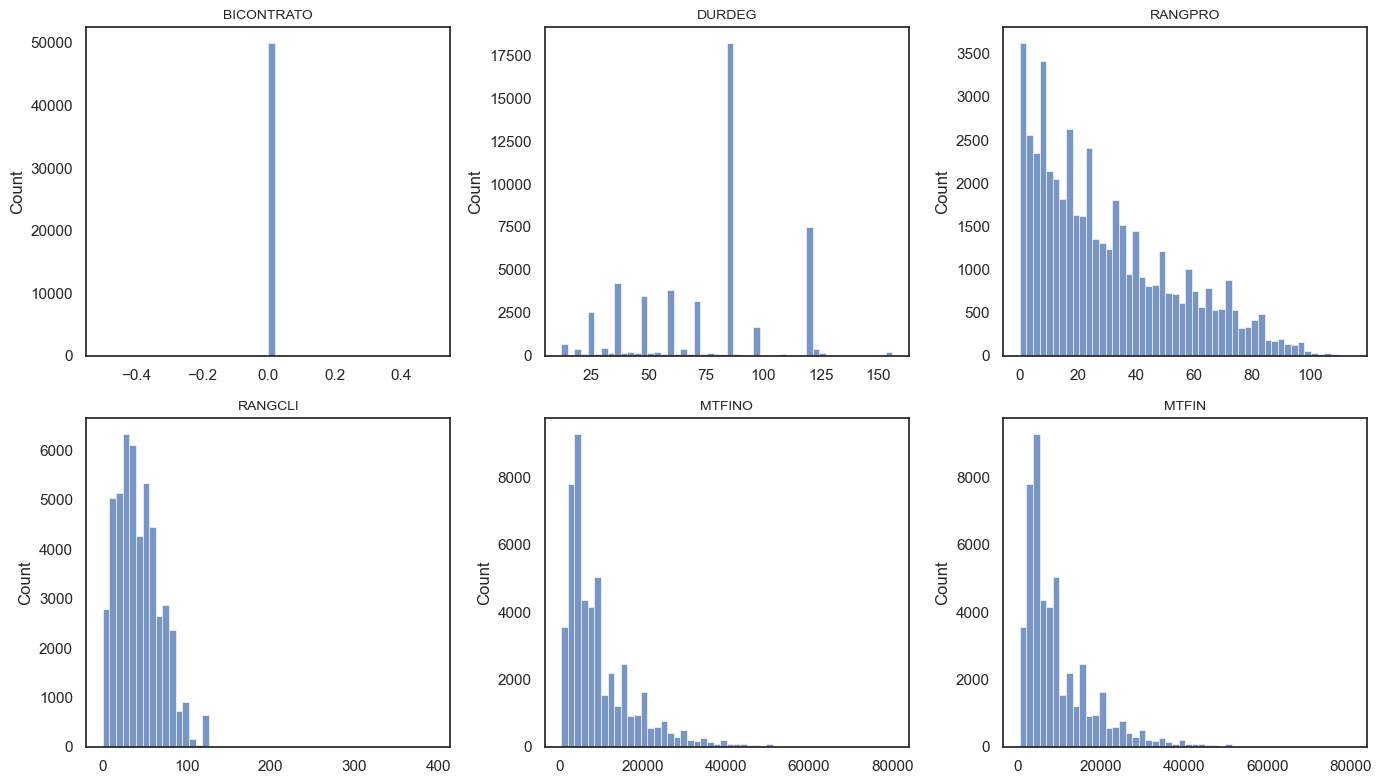

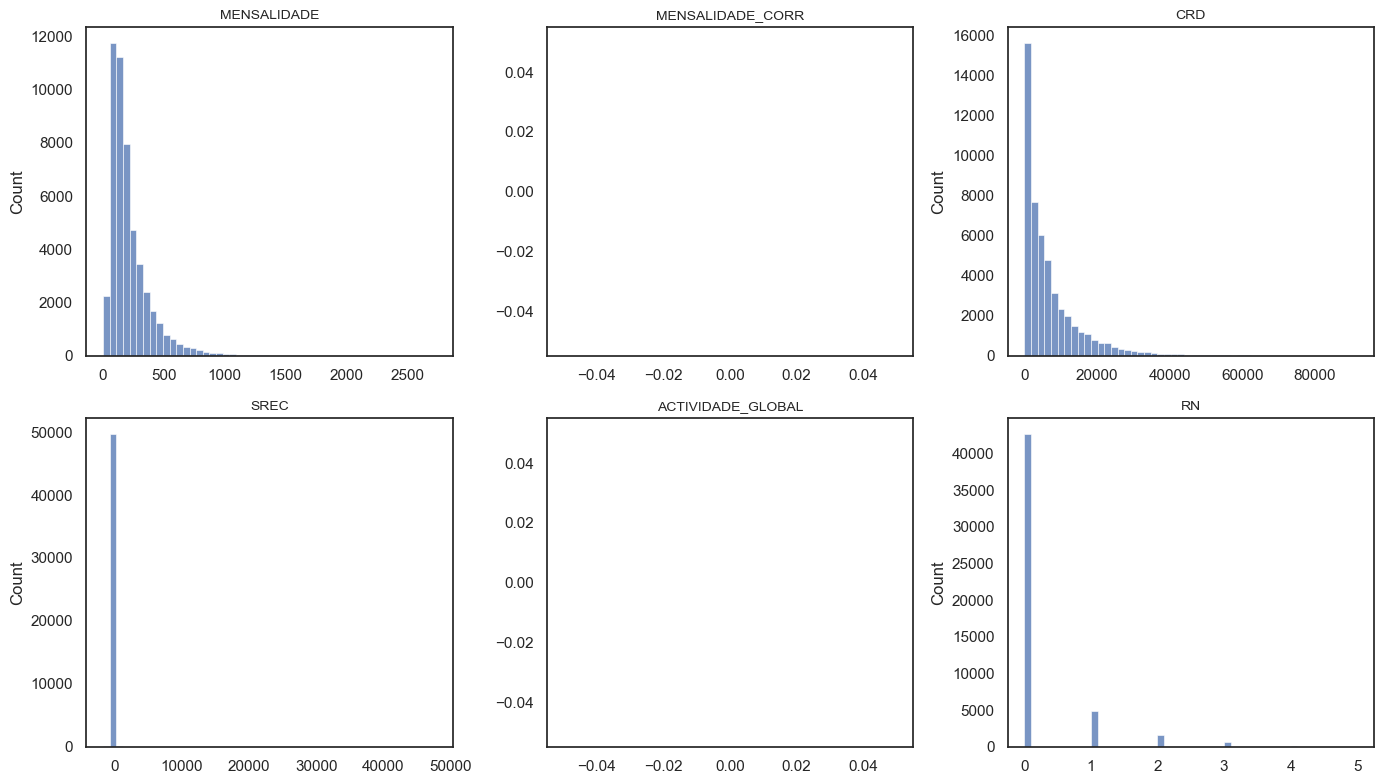

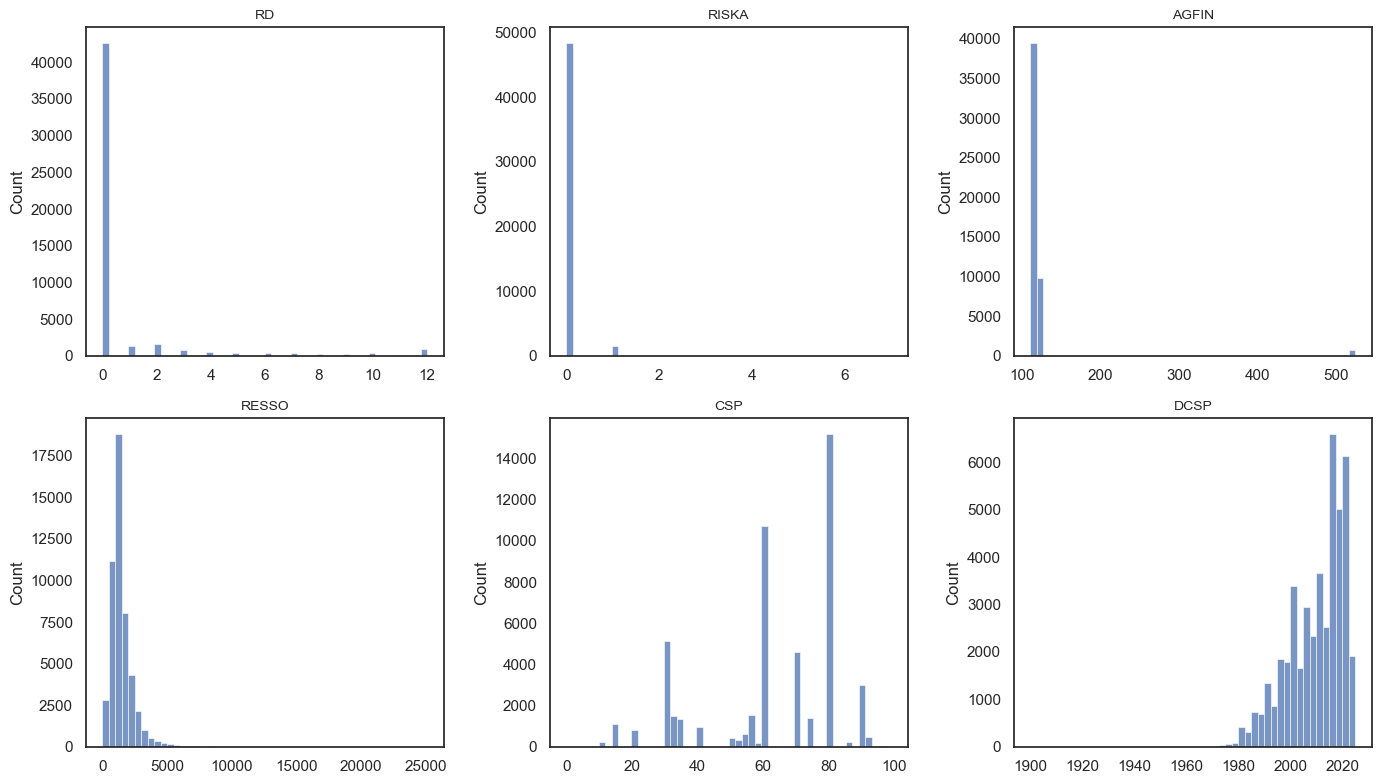

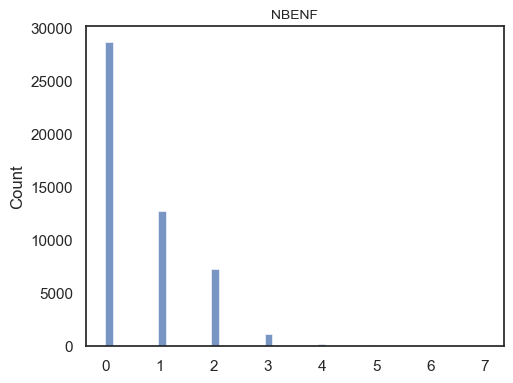

In [165]:
# Sampling (50k is usually enough for distributions)
N = 50_000
sample = BDOSS.sample(n=min(N, len(BDOSS)), random_state=42)

# Numeric columns
cols = sample.select_dtypes(include=[np.number]).columns

plots_per_fig = 6
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):

    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]

    n_plots = len(subset_cols)
    n_rows = ceil(n_plots / 3)

    fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, subset_cols):
        values = sample[col].dropna().values
        sns.histplot(values, bins=50, ax=ax)
        ax.set_title(col, fontsize=10)

    # Remove unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#### 2.5.2. Categorical Variable

In [ ]:
sns.set_style("white")

plots_per_fig = 6
n_figs = ceil(len(obj_cols_DB) / plots_per_fig)

for f in range(n_figs):
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = obj_cols_DB[start:end]

    n_plots = len(subset_cols)
    n_rows = ceil(n_plots / 3)

    fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4*n_rows), dpi=150)
    axes = axes.flatten()

    for ax, col in zip(axes, subset_cols):
        counts = BDOSS[col].value_counts()
        max_category = counts.idxmax()

        colors = [
            "steelblue" if cat == max_category else "lightgray"
            for cat in counts.index
        ]

        ax.bar(counts.index.map(str), counts.values, color=colors)
        ax.set_title(col, fontsize=10)
        ax.tick_params(axis='x', rotation=90)

    # Remove empty axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### 2.6. Checking Correlation between variables

In [166]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = BDOSS[num_cols_DB].corr(method ='spearman')
cor_spearman

,BICONTRATO,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISKA,AGFIN,RESSO,CSP,DCSP,NBENF
BICONTRATO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DURDEG,NaN,1.000000,0.364130,0.306403,0.678258,0.678291,0.341605,NaN,0.510962,-0.063407,NaN,0.032983,0.030945,0.020154,-0.011308,-0.003946,0.020566,-0.104580,0.073626
RANGPRO,NaN,0.364130,1.000000,0.629326,0.268217,0.268225,0.096455,NaN,-0.123273,-0.046085,NaN,0.030191,0.031083,0.025452,0.025405,-0.085924,0.055227,-0.250384,0.042637
RANGCLI,NaN,0.306403,0.629326,1.000000,0.246725,0.246774,0.119923,NaN,-0.021387,-0.032302,NaN,0.042116,0.041237,-0.003847,-0.142835,0.024162,0.037726,-0.307816,0.034233
MTFINO,NaN,0.678258,0.268217,0.246725,1.000000,0.999978,0.875974,NaN,0.654177,-0.075268,NaN,-0.005928,-0.004466,0.003301,-0.065762,0.113562,-0.033091,-0.121003,0.049988
MTFIN,NaN,0.678291,0.268225,0.246774,0.999978,1.000000,0.875981,NaN,0.654203,-0.075264,NaN,-0.005887,-0.004433,0.003296,-0.065711,0.113531,-0.033048,-0.120966,0.049993
MENSALIDADE,NaN,0.341605,0.096455,0.119923,0.875974,0.875981,1.000000,NaN,0.575626,-0.067251,NaN,-0.018618,-0.015734,0.000704,-0.064483,0.138536,-0.044722,-0.082188,0.017147
MENSALIDADE_CORR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRD,NaN,0.510962,-0.123273,-0.021387,0.654177,0.654203,0.575626,NaN,1.000000,-0.114531,NaN,-0.048013,-0.046455,0.034666,-0.044136,0.096028,-0.043185,0.018859,0.026285
SREC,NaN,-0.063407,-0.046085,-0.032302,-0.075268,-0.075264,-0.067251,NaN,-0.114531,1.000000,NaN,-0.058779,-0.055721,-0.078877,-0.002627,0.010513,-0.026158,0.008712,0.021880


In [167]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

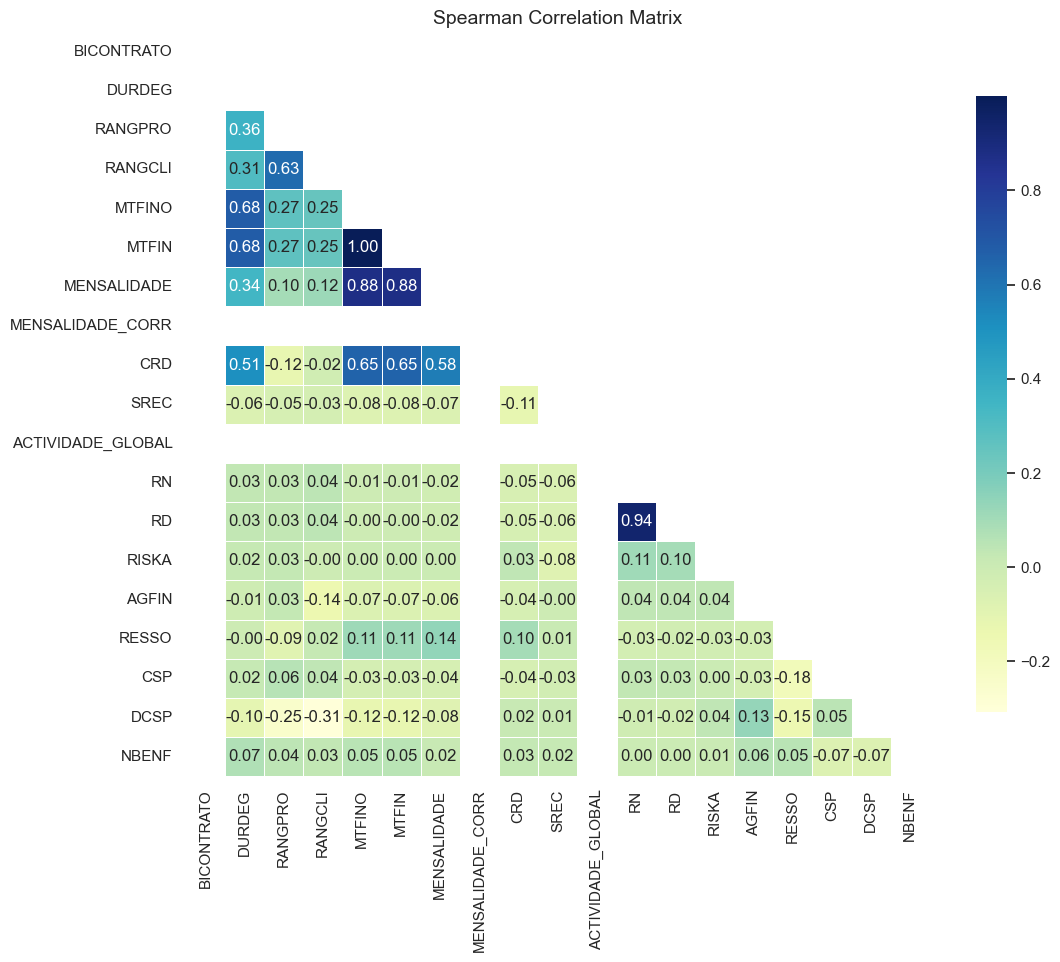

In [168]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

**Redundant Variables**:
- *MTFIN* vs *MTFINO* (1.00)
- *RN* vs *RD* (0.94)
- *MENSALIDADE* vs *MTFIN* AND *MTFINO* (0.88)

### 2.4. Checking Incoherencies

**- Constant Features**

In [133]:
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [134]:
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [135]:
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [136]:
BDOSS['BICONTRATO'].unique()

array([0.])

**- more data analysis**

In [137]:
BDOSS['RISK'].value_counts()

RISK
000000000000000000000000    2327930
444444444444444444444444      23863
000000000000000000000001      16652
000000000000000000000010       7487
000000000000000000000100       6278
                             ...   
010000100001000111122010          1
000000100000000010101010          1
012222222122221221111221          1
000001122222221221122100          1
000110210110000000211221          1
Name: count, Length: 77475, dtype: int64

In [138]:
BDOSS['RISKA'].value_counts()

RISKA
0.0    2571156
1.0      79077
7.0       7954
Name: count, dtype: int64

In [139]:
BDOSS['NBENF'].value_counts() 

NBENF
0.0     1538648
1.0      664154
2.0      385790
3.0       59785
4.0        7713
5.0        1288
8.0          23
7.0          23
10.0         11
52.0          8
6.0           6
90.0          2
Name: count, dtype: int64

In [140]:
BDOSS['AGFIN'].value_counts()

AGFIN
118.0    1229325
117.0     720161
120.0     518201
119.0     146805
525.0      39560
112.0       3963
111.0         66
500.0         48
503.0         46
116.0          6
100.0          6
Name: count, dtype: int64

In [141]:
BDOSS['POS'].unique()

array(['ENC', 'SAN', 'SOL', 'RBT'], dtype=object)

Meanings of POS's unique values:
- ENC: Normal state;
- SAN: Client settles before date;
- SOL: Client settles on contract termination date;
- RBT: Same as SAN (business wise).

Since RBT is the same as SAN, we will update our dataset so that every RBT turns into SAN.

In [142]:
BDOSS['RN'].value_counts()

RN
0.0    2270299
1.0     257370
2.0      88703
3.0      34114
4.0       6707
5.0        970
6.0         24
Name: count, dtype: int64

RN is a red flag feature, the higher it's value, the higher the chance a client will churn.

In [143]:
BDOSS['POLE'].value_counts()

POLE
P    2615205
N      42982
Name: count, dtype: int64

Not specified in MetaData, however, we were told that:
- P: Direct business;
- N: Sales for business partners.

**- PRODALP**

In [144]:
BDOSS['PRODALP'].value_counts()

PRODALP
EP     1912612
EPF     394887
EXT     287176
DEF      63512
Name: count, dtype: int64

None of these unique values appear in our MetaData. However, we were told that:
- EP - most used when the clients want to churn; 
- EXT, EPF, DEF: Personal loans.

**- CSP**

In [145]:
BDOSS['CSP'].unique()

array([80., 91., 35., 60., 90., 54., 70., 31., 74., 20., 58., 15., 41.,
       10., 50., 33., 56., 55., 86., 32., 30., 92., 57., 52., 53., 34.,
       40., 81., 99.,  0., 96., 25., 51.])

The values 54, 58, 50, 56, 55, 57, 52, 53, 0 and 51 also don't appear in our MetaData.

In [146]:
missing = [54, 58, 50, 56, 55, 57, 52, 53, 0, 51]
result = 0
for num in BDOSS['CSP']:
    if num in missing:
        result = result + 1
print(result)

161453


In [147]:
result / len(BDOSS['CSP']) * 100

6.073801429320059

These values correspond to around 6% of our data

**- RISK AND RISKA**

In [148]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6236580eb19aa138a56,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
53,00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bccd4bf8dce4665e2303,64f6c53b0b8e111e029da5ea073196dbd89ae6025fd9a71125070fca88f38625,P,CL,EP,0.0,SAN,2024-01-31,2022-12-29,2023-01-05,2023-01-05,2023-12-11,22.0,11.0,11.0,2500.0,2500.0,147.925036,NaN,0.000,0.000,NaN,1.0,3.0,000000000000020000101011,0.0,118.0,P,1451.493,80.0,2021.0,D,8125,2.0,W
57,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1aa20e6edf4ce631f4e,2b075e5032a850f4290d1b23e68320cd36cffb93f7dcc8215e7c6ed10b3824e0,P,CL,EP,0.0,SAN,2024-01-31,2022-02-02,2022-02-03,2022-02-03,2023-06-05,60.0,16.0,37.0,2500.0,2500.0,61.538164,NaN,0.000,0.000,NaN,3.0,9.0,000000002110122200122001,0.0,118.0,P,2009.717,10.0,2018.0,P,3090,2.0,W
72,002ddf74dace98336bfd869bdf44deab63ab07753122d6336e1076b940009faa,2a0c6243fee831fa936fc507b331b614dc6ad6b53910d6096b2c457312479cbf,P,CL,EP,0.0,SOL,2024-01-31,2014-01-09,2014-01-22,2014-01-09,2022-10-04,84.0,81.0,81.0,5000.0,5000.0,118.518615,NaN,0.000,0.000,NaN,3.0,5.0,221111222112012212220111,0.0,119.0,P,1231.996,70.0,2009.0,P,7580,0.0,T
122,004cc9fa8892482a26231071d03ecb17c5a8779b683804c9075c7dc0ea10a89d,56ca44ed01b953656bd0b46454b894de6b39d882e52279491e084250263da9eb,P,CL,EXT,0.0,ENC,2024-01-31,2023-04-26,2023-05-08,2023-05-05,2024-01-23,84.0,9.0,9.0,10343.0,10343.0,233.912421,NaN,11549.523,0.000,NaN,0.0,0.0,000000000000000000010110,1.0,118.0,P,2523.423,35.0,2009.0,P,2775,2.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658123,ffddc57160d56f6899d2daa5e1a1720b5903a6e665354fc5e1bda5faa6d8f7ed,c56d1af3fdeeceb79806b8dd25b0495f25f225b5428e88b488381acf4dcddb37,P,CL,EPF,0.0,ENC,2025-11-30,2022-01-09,2022-02-16,2022-02-16,2024-09-09,84.0,45.0,45.0,5000.0,5000.0,107.643659,NaN,3307.841,0.000,NaN,0.0,0.0,000010000000000000000000,1.0,118.0,P,313.084,52.0,NaN,P,2415,0.0,W
2658149,ffec38e28088b6290ec9ed851675f19b0182cecd14a105eb3fd58866e690bea5,7bcb4d654fd5736dcc83846e861dfb7b2fab4b21bf7180f81105384e50823e06,P,CL,EPF,0.0,ENC,2025-11-30,2022-10-06,2022-10-14,2022-10-14,2025-11-28,84.0,38.0,38.0,11000.0,11000.0,244.084787,NaN,8467.150,0.000,NaN,0.0,0.0,000000000010001000000101,0.0,117.0,P,861.102,80.0,2000.0,P,3720,0.0,A
2658180,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a976298f14134a4b0a710,9638a80107e20c8cbf33e66fe0ffc642fee561907852dc721ebe503a221d6a1d,P,CL,EXT,0.0,SAN,2025-11-30,2023-08-01,2023-08-21,2023-08-18,2025-08-12,84.0,23.0,23.0,24750.0,24750.0,584.152276,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000001111111,0.0,118.0,P,1253.882,80.0,1995.0,P,4425,1.0,W
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7a4e15a2b1365e14fd8,P,CL,EPF,0.0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84.0,83.0,83.0,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0.0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W


In [149]:
168528 / len(BDOSS) * 100

6.339960281199178

Here, we can see that only around 6% of our data has a RISKA value diferent than the last number of RISK.

**- RANGPRO AND DURDEG**

In [150]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
13373,1eeda66678fe87887b4e435aa1ac405c4ee922ad6bed980a526af9c162868c11,6a73d420a9c4629486e6f5dda41f27e14de45734f835ab26a77b84c1a5626065,P,CL,EP,0.0,SOL,2024-01-31,2017-09-14,2017-09-21,2017-09-21,2023-12-01,72.0,73.0,73.0,7000.00,7000.00,157.190164,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1181.441,70.0,1987.0,P,2350,0.0,A
14809,22535d3248147b8e894c46602e349876a2b7a58252a7b07a61181680ff2f5d99,d55babf7dbe197586e7b624efb0da2d1898a90f918b7acaf380e210eaf2096e7,P,CL,EPF,0.0,SOL,2024-01-31,2015-05-22,2015-05-28,2015-05-22,2023-08-04,84.0,85.0,85.0,9000.46,9000.46,199.519797,NaN,0.0,0.0,NaN,1.0,1.0,100000000000000121212121,0.0,118.0,N,1851.117,90.0,2000.0,P,3610,1.0,None
23704,366d5bd958989f93f6e20d957959f964ddf065149bd715a8f3d1fac7ac3d88c5,7e205ecd82246afc84cc94105be457755e0fe7ccd65b2f3ed9dd5bb5eb5345e2,P,CL,EPF,0.0,SOL,2024-01-31,2016-08-08,2016-08-23,2016-08-08,2023-11-21,84.0,85.0,85.0,10500.00,10500.00,238.839973,NaN,0.0,0.0,NaN,1.0,0.0,000000110100200111000011,0.0,117.0,P,901.600,70.0,2012.0,P,2410,1.0,None
48850,7013a45ea15ab41a281691a85a99c53bb650d7b6d127450dbd93fedd33a7a417,e0cfdfb6402b13a9540add0d348ad1d166ff5de5b99d1f0514824286fc1753f5,P,CL,EPF,0.0,SOL,2024-01-31,2016-10-14,2016-10-24,2016-10-14,2024-01-01,84.0,85.0,85.0,15000.60,15000.60,341.476332,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000001000000,0.0,117.0,P,836.839,80.0,1993.0,P,7370,0.0,None
53702,7b2db95efe1f3f55ae0566731a18ef153f7ada276c4fc3bbfab60ea391c7c013,7c2e2cb7b349743596bd6087f9b55d20d0d2ffae927505635daee5cfbb50410f,P,CL,EP,0.0,SOL,2024-01-31,2017-10-03,2017-10-09,2017-10-09,2024-01-01,72.0,73.0,73.0,15000.00,15000.00,344.638483,NaN,0.0,0.0,NaN,0.0,0.0,000000000000010000000000,0.0,118.0,P,1045.234,60.0,2012.0,P,2675,0.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591774,747283c8dd6c2be7c5e4d86c4adcd653c3f9381b4f0e6af86bcecb096604efc8,66bb8e8c16bac641e2ff3f1cfbb4f760c310ae3c652d9e9c4be74e349fc41cfb,P,CL,EP,0.0,SOL,2025-11-30,2017-05-06,2017-07-12,2017-07-12,2025-09-10,96.0,97.0,97.0,25000.00,25000.00,476.003055,NaN,0.0,0.0,NaN,1.0,2.0,002210000000000000002211,0.0,118.0,P,2710.636,81.0,2016.0,P,2430,2.0,W
2592547,761e197ef3212fef89be1a88eb9d46d862c72e699dc9f6b117211e6506ea3af3,91f180eb8d37733c4bd4a1c1f40cce541a84039790e78d40a9e5e36bb23cec08,P,CL,EP,0.0,SOL,2025-11-30,2019-07-02,2019-07-08,2019-07-08,2025-10-01,72.0,73.0,73.0,11000.00,11000.00,248.800673,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,662.454,20.0,2015.0,P,4500,2.0,A
2595126,7b4ae59459f74157e8dd76f2cb2a4418dae8818d89758c0e7b659faaa7a25317,735d4904fb0d6a5daf2298cd7a3f1c6d2e419fc470ea3c0c858ac20a205e9c0b,P,CL,EP,0.0,SOL,2025-11-30,2023-08-31,2023-08-31,2023-08-31,2025-09-05,24.0,25.0,25.0,4000.00,4000.00,215.810828,NaN,0.0,0.0,NaN,2.0,7.0,020000000000000000000100,0.0,117.0,P,1238.833,74.0,2017.0,P,9300,1.0,A
2632092,c91a7037a2ec427dfb5398e8db01c486ae872b2604c0a57bb0b84042a5366e01,4f998ab6e24407fc3d5259d9de75fa9146bc833541686e32d7924603260b7fbb,P,CL,EPF,0.0,SOL,2025-11-30,2019-04-29,2019-04-29,2019-04-29,2025-08-11,72.0,73.0,73.0,16000.00,16000.00,374.958776,NaN,0.0,0.0,NaN,0.0,0.0,000000010000000000000000,0.0,118.0,P,2993.089,31.0,1998.0,P,3870,1.0,A


In [151]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] == 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
7,000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,a23e77794a2b9ab78303d8c540bd7f73ac3e3fce788fcaa0a0120c5da8a52764,P,CL,EP,0.0,SOL,2024-01-31,2018-07-31,2018-08-17,2018-08-17,2023-09-01,60.0,60.0,60.0,5000.0,5000.0,128.983684,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,912.411,60.0,2000.0,P,9680,2.0,A
80,00373284a84ad063cf446d3ddcd3b581093360d90f868dbccf24b86489105fe7,4f54a4a12cc205c0486eab64b9cc3b88f64f3d0d331684414a9b5d9e0a7f98a4,P,CL,EP,0.0,SOL,2024-01-31,2019-11-15,2019-11-18,2019-11-18,2023-12-01,48.0,48.0,48.0,4000.0,4000.0,120.673502,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,4075.148,60.0,2004.0,P,4405,0.0,A
82,0037926b6b79ef354a08b184866c44f60dcdb4c9e6bbce79d216d8235476a874,e168885d792bd5b71ded787bc796f50c8715e6519fd380b458aa6e0fb947bdda,P,CL,EP,0.0,SOL,2024-01-31,2022-01-31,2022-02-04,2022-02-04,2024-02-01,24.0,24.0,24.0,2550.0,2550.0,130.562159,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1030.291,60.0,2021.0,P,2655,0.0,W
84,003847aa9634135bca3145e5a494f81bdf3d888e97b26cf517fb2321c9e61a71,2ac8e2bbefdaf86ad0adad6350d0a3631b0dc97506eceeae5e65a5e7a68cc2dd,P,CL,EP,0.0,SOL,2024-01-31,2019-04-12,2019-04-16,2019-04-16,2024-01-02,56.0,56.0,56.0,10000.0,10000.0,247.929850,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,2503.747,60.0,2015.0,P,2675,0.0,W
152,006035d67ee018b0ef98b09a75b921601bb8eebb76b44caa0ca71c173b4b7393,e9a06a469636f9dd6a20ba110a7b3bfbfcce301d3d485da081ca5ac3cc4c14dd,P,CL,EP,0.0,SOL,2024-01-31,2018-02-06,2018-02-12,2018-02-12,2024-02-01,72.0,72.0,72.0,2500.0,2500.0,57.396444,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,831.451,86.0,1998.0,P,4595,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658094,ffce63610dbb460be5181d993711dce04a91258e18659ef32c2909162dcd0f79,7419ce475632f1f2cea9cd315bb5d001cc9fa36a1cf009c09b7a4eb2446efa3d,P,CL,EP,0.0,SOL,2025-11-30,2023-01-17,2023-02-01,2023-02-01,2025-08-01,30.0,30.0,73.0,1500.0,1500.0,68.447232,NaN,0.0,0.0,NaN,1.0,8.0,000000000000000000000000,0.0,118.0,P,1115.982,60.0,2022.0,P,9500,0.0,W
2658109,ffd469fd2b43c5de080a48312af88069823680eb1d86f2a00e7128ced991322d,5e853d677ae5d207d07ff52d5c43b82e7407f8c516101fa2677e1a7fd32cd0af,P,CL,EP,0.0,SOL,2025-11-30,2023-08-10,2023-08-14,2023-08-14,2025-08-01,24.0,24.0,24.0,5500.0,5500.0,311.509961,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1582.440,74.0,1994.0,P,2970,2.0,W
2658137,ffe7a79c9555711286b52c99ddae968134558142c6400d4e36fefaf39005e11d,98d451dabef588274b9eef60a64943a5370a5ed22f2915969236e29890ca51b9,P,CL,EP,0.0,SOL,2025-11-30,2018-06-10,2018-07-16,2018-07-16,2025-08-01,84.0,84.0,84.0,7000.0,7000.0,132.402437,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,694.528,31.0,2017.0,P,4560,2.0,W
2658162,fff437ed8b6c8eb46dee5ab5968d2abb4eabd769eac974278f206402a109576d,c267c3b05999dfecbdc5b40c725b6611982fb0f02bf2dc60608b8597d9c478dc,P,CL,EP,0.0,SOL,2025-11-30,2023-02-09,2023-03-06,2023-03-06,2025-09-01,30.0,30.0,30.0,2500.0,2500.0,115.844357,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1495.553,80.0,2022.0,P,6060,1.0,W


In the cells above, we can see that there are 253 rows in BDOSS with a RANGPRO value higher than it's respective DURDEG value. We can also see that this diference is exactly 1 in every row.

<a class="anchor" id="2.2 Analysing the Data">

## 3. Data Preparation
    
</a>

### 3.1. Changing Datatypes

In [152]:
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')
BDOSS['RISKA'] = BDOSS['RISKA'].round().astype('Int32')
BDOSS['CSP'] = BDOSS['CSP'].round().astype('Int32')
BDOSS['DCSP'] = BDOSS['DCSP'].round().astype('Int32')

In [153]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         Int32         
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             Int32         
 13  RANGPRO            Int32         
 14  RANGCLI            Int32         
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

### 3.2. Handling Incoherencies

In [154]:
#replacing every RBT with SAN
BDOSS['POS'] = BDOSS['POS'].replace('RBT', 'SAN')

In [155]:
#Correcting observations so every RISKA value corresponds to the last number of it's respective RISK value.
mask = BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)

BDOSS.loc[mask, 'RISK'] = (BDOSS.loc[mask, 'RISK'].astype(str).str[:-1] + 
                           BDOSS.loc[mask, 'RISKA'].astype(str))

BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO


In [156]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']
#BDOSS.loc[mask, 'DURDEG'] = BDOSS.loc[mask, 'RANGPRO']

### 3.3. Handling Missing Values

In [157]:
#checking number of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

In [158]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [159]:
#droping 'MENSALIDADE_CORR' and'ACTIVIDADE_GLOBAL' due to its elevated number of missing values
BDOSS = BDOSS.drop(columns=['MENSALIDADE_CORR'])
BDOSS = BDOSS.drop(columns=['ACTIVIDADE_GLOBAL'])

In [160]:
#filling missing values of categorical variables with mode
for col in ['RANGCLI', 'NATIO', 'MODCONTACTO']:
    BDOSS[col] = BDOSS[col].fillna(BDOSS[col].mode()[0])

'''#filling missing values of numeric variables with median
for col in ['DCSP', 'NBENF']:
    BDOSS[col] = BDOSS[col].fillna(BDOSS[col].median())
'''

"#filling missing values of numeric variables with median\nfor col in ['DCSP', 'NBENF']:\n    BDOSS[col] = BDOSS[col].fillna(BDOSS[col].median())\n"

In [197]:
knn = KNNImputer(n_neighbors=5, weights='distance')

cols = ['NBENF', 'DCSP']

BDOSS[cols] = knn.fit_transform(BDOSS[cols])

KeyboardInterrupt: 

### 3.4. Handling Outliers

In [161]:
BDOSS['MTFINO'] = BDOSS['MTFINO'].clip(upper=80000)
BDOSS['MTFIN'] = BDOSS['MTFIN'].clip(upper=80000)
BDOSS['MENSALIDADE'] = BDOSS['MENSALIDADE'].clip(upper=4000)
BDOSS['CRD'] = BDOSS['CRD'].clip(upper=100000)
BDOSS['SREC'] = BDOSS['SREC'].clip(upper=40000)
BDOSS['RESSO'] = BDOSS['RESSO'].clip(upper=700000)
BDOSS['NBENF'] = BDOSS['NBENF'].clip(upper=10)

### 3.5. Feature Engineering

In [162]:
# garantir ordem temporal
BDOSS = BDOSS.sort_values(['CONTRIB', 'DOSSIER', 'OBS_DATE']).copy()

# contar quantas vezes já apareceu CRD == 0 dentro de cada contrato
zero_count = (
    BDOSS['CRD'].eq(0)
    .groupby([BDOSS['CONTRIB'], BDOSS['DOSSIER']])
    .cumsum()
)

# manter:
# - todas as linhas com CRD != 0
# - apenas a primeira linha com CRD == 0
BDOSS = BDOSS[(BDOSS['CRD'] != 0) | (zero_count == 1)].copy()

In [163]:
BDOSS['DIF_CRD_NEXT'] = BDOSS['CRD'] - (BDOSS.groupby(['CONTRIB', 'DOSSIER'])['CRD'].shift(-1))
col = BDOSS.pop('DIF_CRD_NEXT')
BDOSS.insert(19, 'DIF_CRD_NEXT', col)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,CRD,DIF_CRD_NEXT,SREC,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
576857,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-06-30,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,0,19,8000.0,8000.0,158.359889,9575.287,77.933,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W
694260,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-07-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,1,19,8000.0,8000.0,158.359889,9497.354,78.628,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W
812122,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-08-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,2,19,8000.0,8000.0,158.359889,9418.726,9418.726,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W
930223,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,SAN,2024-09-30,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,0.000,NaN,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W
930224,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,P,CL,EP,0,ENC,2024-09-30,2024-09-13,2024-09-30,2024-09-30,2024-09-30,120,1,19,16000.0,16000.0,280.401466,19336.270,82.508,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W


**- DELAY (amount of time, in months, that the client delayed payments)**

In [164]:
conditions = [
    BDOSS['DIF_CRD_NEXT'] == 0.00,                   # não pagou
    BDOSS['DIF_CRD_NEXT'] > BDOSS['MENSALIDADE'],   # pagou mais
    BDOSS['DIF_CRD_NEXT'] < BDOSS['MENSALIDADE']   # pagou normal
]

choices = [-1, 1, 0]

BDOSS['DELAY'] = np.select(conditions, choices, default=0)

In [165]:
BDOSS

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,CRD,DIF_CRD_NEXT,SREC,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO,DELAY
576857,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-06-30,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,0,19,8000.0,8000.0,158.359889,9575.287,77.933,0.000,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W,0
694260,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-07-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,1,19,8000.0,8000.0,158.359889,9497.354,78.628,0.000,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W,0
812122,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,ENC,2024-08-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,2,19,8000.0,8000.0,158.359889,9418.726,9418.726,0.000,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W,1
930223,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,P,CL,EP,0,SAN,2024-09-30,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,0.000,NaN,0.000,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W,0
930224,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,P,CL,EP,0,ENC,2024-09-30,2024-09-13,2024-09-30,2024-09-30,2024-09-30,120,1,19,16000.0,16000.0,280.401466,19336.270,82.508,0.000,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112222,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a83d25691d13a2764e4,P,CL,EPF,0,ENC,2024-01-31,2022-03-24,2022-03-31,2022-03-31,2023-09-15,84,22,34,12000.0,12000.0,267.471639,11686.385,141.249,0.000,0.0,0.0,000000000000000000100001,1,117.0,P,916.467,80,2014,P,2845,0.0,A,0
226249,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a83d25691d13a2764e4,P,CL,EPF,0,ENC,2024-02-29,2022-03-24,2022-03-31,2022-03-31,2024-02-29,84,23,34,12000.0,12000.0,267.471639,11545.136,11545.136,0.000,0.0,0.0,000000000000000001000000,0,117.0,P,916.467,80,2014,P,2845,0.0,A,1
342740,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a83d25691d13a2764e4,P,CL,EPF,0,SAN,2024-03-31,2022-03-24,2022-03-31,2022-03-31,2024-03-27,84,23,34,12000.0,12000.0,267.471639,0.000,NaN,700.531,0.0,0.0,000000000000000010000010,0,117.0,P,1034.366,80,2014,P,2845,0.0,A,0
112223,ffff943c736f98d4840f65328ba372a29689312dd781b437624e6112d3d6803b,028095f193e6a9ceaf6878e2f08ea30b2218d02b27d23daaf486a33636e4b637,P,CL,EP,0,ENC,2024-01-31,2023-10-23,2023-10-30,2023-10-30,2023-10-30,24,3,6,2500.0,2500.0,135.336545,2572.760,NaN,0.000,1.0,12.0,000000000000000000000101,1,119.0,P,924.580,60,2005,P,2825,0.0,A,0


In [187]:
#survival methods
# ordenar
BDOSS = BDOSS.sort_values(['CONTRIB', 'DOSSIER', 'OBS_DATE']).copy()

# última OBS_DATE de cada dossier, replicada em todas as linhas do grupo
BDOSS['LAST_OBS_DATE'] = BDOSS.groupby(['CONTRIB', 'DOSSIER'])['OBS_DATE'].transform('max')

# tempo em meses inteiros
BDOSS['TIME_MONTHS'] = (
    (BDOSS['LAST_OBS_DATE'].dt.year - BDOSS['DCREAT'].dt.year) * 12
    + (BDOSS['LAST_OBS_DATE'].dt.month - BDOSS['DCREAT'].dt.month)
)

### 3.5. Data Aggregation

**Data Agregation**

We will start by agregating every DOSSIER per client.

In [198]:
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(
    #counting every 'POS' result
    #sol_count = ('POS', lambda x: (x == 'SOL').sum()),
    #san_count = ('POS', lambda x: (x == 'SAN').sum()),
    #enc_count = ('POS', lambda x: (x == 'ENC').sum()),
    #rbt_count = ('POS', lambda x: (x == 'RBT').sum()),
    is_san=('POS', lambda x: int(x.eq('SAN').any())),
    is_sol=('POS', lambda x: int(x.eq('SOL').any())),
    
    #DURDEG, MTFINO and MENSALIDADE are constant in the dossier
    #RANGPRO, RANGCLI e HISTORIAL - max
    #CRD - min 
    #RESSO AND NBENF - mean
    #AGFIN, PAGAMENTO, CSP, NATIO, PTT and MODCONTACTO - mode
    #faltam: POLE, PRODALP, RN, DATAS IMPORTANTES, SHREK
    
    DCREAT = ('DCREAT', 'first'),
    DCRD_0 = ('OBS_DATE', lambda x: x[BDOSS.loc[x.index, 'CRD'] == 0].min()),
    CLOSE_DATE = ('DPOS', lambda x: x[BDOSS.loc[x.index, 'POS'].isin(['SAN','SOL'])].min()),
    TIME_MONTHS = ('TIME_MONTHS', 'first'),

    DURDEG = ('DURDEG', 'first'),
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    delay_sum = ('DELAY', 'sum'),
    
    MENSALIDADE = ('MENSALIDADE', 'first'),     
    CRD_min = ('CRD', 'min'),
    MTFINO = ('MTFINO', 'first'),
    RESSO_mean = ('RESSO', 'mean'),
    RISKA_mean = ('RISKA', 'mean'),
    NBENF_mean = ('NBENF', 'mean'),
    RN_mean = ('RN', 'mean'),
    SREC = ('SREC', 'mean'),

    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

In [167]:
agg_dossier[(agg_dossier['is_sol'] == 1) & (agg_dossier['is_san'] == 1)]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO


In [189]:
agg_dossier.head()


,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,TIME_MONTHS,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
0,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,1,0,2024-06-25,2024-09-30,2024-09-30,3,84,3,19,1,158.359889,0.000,8000.00,1395.9935,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W
1,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,1,0,2024-09-13,2025-11-30,2025-11-30,14,120,13,19,1,280.401466,0.000,16000.00,1513.4660,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W
2,0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43,0,0,2018-03-29,NaT,NaT,92,120,91,91,0,347.447280,8115.247,20000.00,1113.2580,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c,0,1,2001-09-27,2024-03-31,2024-03-31,270,60,21,21,0,184.214593,0.000,5985.57,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,796b87efb05b1ec3f822189b7b5fe25be06390e7462d228bc34ef083de72f011,0,1,2001-09-21,2024-03-31,2024-03-31,270,60,21,21,0,424.699203,0.000,13467.54,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T


In [202]:
dup_check = BDOSS.groupby('DOSSIER')['CONTRIB'].nunique()
dup_check[dup_check > 1]

DOSSIER
460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    2
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
Name: CONTRIB, dtype: int64

After this first agregation we can see that 8 dossiers appear twice on our agg_dossier DataFrame.

We determined that the reason is for the clients to be married and share the dossiers.

In [229]:
def next_valid_dossier(group):
    group = group.sort_values('DCREAT').copy()
    dcreat = group['DCREAT'].tolist()
    end_dates = group['DCRD_0'].tolist()

    next_dates = []
    for i in range(len(group)):
        if pd.isna(end_dates[i]):
            next_dates.append(pd.NaT)
            continue

        end_ym = (end_dates[i].year, end_dates[i].month)
        next_date = pd.NaT

        for j in range(i + 1, len(group)):
            if pd.notna(dcreat[j]) and (dcreat[j].year, dcreat[j].month) >= end_ym:
                next_date = dcreat[j]
                break

        next_dates.append(next_date)

    group['NEXT_DOSSIER_DATE'] = next_dates
    return group

agg_dossier = (
    agg_dossier
    .sort_values(['CONTRIB', 'DCREAT'])
    .groupby('CONTRIB', group_keys=False)
    .apply(next_valid_dossier)
)

agg_dossier['MONTH_DIFF'] = (
    (agg_dossier['NEXT_DOSSIER_DATE'].dt.year - agg_dossier['DCRD_0'].dt.year) * 12
    + (agg_dossier['NEXT_DOSSIER_DATE'].dt.month - agg_dossier['DCRD_0'].dt.month)
)

agg_dossier['DAYS_TO_NEXT'] = (
    agg_dossier['NEXT_DOSSIER_DATE'] - agg_dossier['DCRD_0']
).dt.days

agg_dossier['CHURN'] = np.nan
closed = agg_dossier['DCRD_0'].notna()
agg_dossier.loc[closed, 'CHURN'] = (agg_dossier.loc[closed, 'MONTH_DIFF'] != 1).astype(int)

C:\Users\alano\AppData\Local\Temp\ipykernel_12532\2216238400.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(next_valid_dossier)


In [230]:
agg_dossier[agg_dossier['CHURN'] == 1].sort_values(['CONTRIB', 'DCREAT'])

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,TIME_MONTHS,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,time_to_churn,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,MONTH_DIFF
0,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,1,0,2024-06-25,2024-09-30,2024-10-03,3,84,3,19,1,158.359889,0.0,8000.00,1395.993500,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,3,2024-09-13,-17.0,1.0,0.0
1,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,1,0,2024-09-13,2025-11-30,2025-11-17,14,120,13,19,1,280.401466,0.0,16000.00,1513.466000,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,14,NaT,NaN,1.0,NaN
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,796b87efb05b1ec3f822189b7b5fe25be06390e7462d228bc34ef083de72f011,0,1,2001-09-21,2024-03-31,2014-06-27,270,60,21,21,0,424.699203,0.0,13467.54,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,270,NaT,NaN,1.0,NaN
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c,0,1,2001-09-27,2024-03-31,2014-06-27,270,60,21,21,0,184.214593,0.0,5985.57,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,270,NaT,NaN,1.0,NaN
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32a1a99618e5be83ced1,1,0,2019-01-28,2024-01-31,2022-12-28,60,72,34,34,0,56.017772,0.0,2500.00,838.186000,0.0,0.0,1.0,0.000000,P,EP,120.0,N,91,P,2855,A,60,NaT,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7,78350b49408237d9be0249768a20c97f5b40f8260b0a4632d120c4f4db1d2b68,1,0,2021-10-26,2024-10-31,2024-11-11,36,84,36,61,2,51.206134,0.0,3000.00,1347.630800,0.1,3.0,0.0,0.000000,P,EP,119.0,P,91,P,9500,A,36,NaT,NaN,1.0,NaN
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7,44646b249bca38e9954ca24c81aa0dd55c1f286a257394bc28f2672d2e895ff0,0,1,2022-09-27,2024-09-30,2024-10-01,24,24,24,61,0,268.768666,0.0,5000.00,1346.169444,0.0,3.0,0.0,0.000000,P,EP,117.0,P,91,P,9500,A,24,NaT,NaN,1.0,NaN
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea71582af5034c1e9a250,0,1,2021-02-12,2024-01-31,2023-12-01,35,34,34,34,0,57.095138,0.0,1500.00,896.196000,0.0,1.0,0.0,0.000000,P,EP,118.0,P,80,P,4400,W,35,NaT,NaN,1.0,NaN
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a83d25691d13a2764e4,1,0,2022-03-24,2024-03-31,2024-03-27,24,84,23,34,1,267.471639,0.0,12000.00,955.766667,0.333333,0.0,0.0,233.510333,P,EPF,117.0,P,80,P,2845,A,24,NaT,NaN,1.0,NaN


In [231]:
agg_dossier[
    (agg_dossier['CHURN'] == 0) &
    (agg_dossier.groupby('CONTRIB')['CONTRIB'].transform('count') >= 2) &
    (agg_dossier.groupby('CONTRIB')['DCRD_0'].transform(lambda x: x.notna().any()))
].sort_values(['CONTRIB', 'DCREAT'])

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,TIME_MONTHS,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,time_to_churn,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,MONTH_DIFF
86,001e15da6f3ead7dfbfd602d687d2efebbe7fbb541487de11529f347e29a13ad,555cf446e94b979ad57b249878b5f6b9f5719f65d9e7d273b68fea5593d48627,1,0,2022-03-14,2024-10-31,2024-12-01,31,60,33,33,2,457.819975,0.0,18000.00,2620.4840,0.0,0.0,0.0,0.000000,P,EP,120.0,P,35,P,4400,W,31,2024-11-25,25.0,0.0,1.0
185,004063d402b0a89ff04889fec8f59d5b05e3f71878d9ca44f8b8568429bfb0ee,c575fae241b37687a11ca7c767b7f79eecd762b1faa3c44c3aefd4faea099520,0,1,2024-03-18,2025-03-31,2025-04-01,12,12,12,25,0,261.849278,0.0,2535.23,1437.7350,0.0,1.0,0.0,0.000000,P,EPF,117.0,P,80,P,4760,A,19,2025-04-15,15.0,0.0,1.0
280,00628bbe8cb9cbafba392423d2e0c4b4378f557f0e6a01773b7b5be090e70f1c,a14917cea99d772c2f161dfab106f1e1193a77479efca45e8aa05e05bb92c986,1,0,2025-02-24,2025-06-30,2025-06-16,4,24,3,7,1,230.496307,0.0,4000.00,0.0000,0.0,1.0,0.0,0.000000,P,EP,118.0,P,80,P,2660,W,8,2025-07-23,23.0,0.0,1.0
406,00936059df64b49f9795325b9c49e6c546355810872b885ce3db10c697148cb0,e9518e43d3fee655be35077960be90ec640dae27b1123703a726264ccfddcd6e,1,0,2024-05-26,2024-10-31,2024-11-18,5,84,5,5,1,151.571891,0.0,7000.00,998.9712,0.0,2.0,0.0,0.000000,P,EP,120.0,P,80,P,7400,W,5,2024-11-14,14.0,0.0,1.0
735,01034a0ae160ab703f17e47597f59f64207054807b4878f9b09eb26b26e0ac51,807de7dc60132b63d723e81ef097dc11b78c7baa58531c54fc013ca1297bfa43,1,0,2023-02-20,2024-01-31,2023-10-16,11,60,7,7,0,58.776080,0.0,2500.00,1156.8770,0.0,0.0,0.0,0.000000,P,EP,117.0,P,31,P,2700,A,14,2024-02-27,27.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185051,ff40b8018a2a7ec6024d7a6e03eed1c1a7f0bdf47c9d782e28c1207c6719ed23,0cfde82b80ae235e3a9428645f86bbbb86f566ff4a1a793aec6f87ee94d821c2,1,0,2023-07-11,2024-05-31,2024-05-31,10,18,11,13,1,71.396290,0.0,1000.00,1216.9580,0.0,0.0,0.0,42.837600,P,EP,118.0,P,80,P,2700,W,10,2024-06-28,28.0,0.0,1.0
185054,ff40b8018a2a7ec6024d7a6e03eed1c1a7f0bdf47c9d782e28c1207c6719ed23,e0395449258f36b433cddfb12df5ce07ea38753712c6f51d1864a376fe93d426,1,0,2023-08-29,2024-05-31,2024-05-31,9,36,9,13,1,204.316588,0.0,5000.00,1216.9580,0.0,0.0,0.0,122.590200,P,EP,118.0,P,80,P,2700,W,11,2024-06-28,28.0,0.0,1.0
185124,ff5404a527b3a43769ba7c79a95e2509a358f799c927baaa864e6ce5bb2c05fd,9973f1a8879a4aa8c503bb4bba9b8f32430fa5313bcd65bb02eef8bca17f0968,0,1,2022-12-21,2024-12-31,2025-01-01,24,24,24,68,0,521.918630,0.0,10000.00,5797.0250,0.0,0.0,0.0,0.000000,P,EPF,117.0,P,56,P,2790,A,34,2025-01-22,22.0,0.0,1.0
185287,ff902ac49d40578176ac77da15a10f7f5e292143db20ba948c206245e1d61599,d402fa3d5b3df6c5db63c410009029adf438fc532bc6a1cfeabdddbfe41be37b,0,1,2024-11-04,2025-10-31,2025-11-01,11,12,12,17,-1,213.931990,0.0,2000.00,2289.1110,0.0,0.0,0.0,50.060462,P,EP,117.0,P,60,P,4745,A,11,2025-11-07,7.0,0.0,1.0


In [233]:
agg_dossier[agg_dossier['CONTRIB'] == '00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639']

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,TIME_MONTHS,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,time_to_churn,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,MONTH_DIFF
60,00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639,72f86fcc886c99f94892670980ae38f266b5e2074b7cbf8eebfa210892eee1b2,1,0,2023-07-19,2024-03-31,2024-03-12,8,12,7,7,1,100.509416,0.000,1000.0,1016.720,0.0,0.0,0.0,0.0,P,EP,120.0,P,70,P,2260,W,8,2024-03-05,-26.0,1.0,0.0
62,00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639,bf2c632420d94fbc76027b6e83858b793b5374624e19d7bf48bad5193ae8e699,1,0,2024-03-05,2024-03-31,2024-04-01,0,22,1,7,0,144.840363,0.000,2500.0,1041.158,0.0,0.0,0.0,0.0,P,EP,118.0,P,70,P,2260,W,0,2025-03-10,344.0,1.0,12.0
59,00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639,6b347a98d42ec86f0c37baf26e5a185a9ae3d17457b101f57698c1a2972f6dfc,1,0,2025-03-10,2025-06-30,2025-06-20,3,18,3,8,1,104.281126,0.000,1500.0,0.000,0.0,0.0,0.0,0.0,P,EP,118.0,P,70,P,2260,W,3,2025-06-03,-27.0,1.0,0.0
61,00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639,a9720e3f71093202eb50e0ac0d129bf893609fe5681993fa68878cc98d523c1f,0,0,2025-06-03,NaT,NaT,5,12,6,8,0,105.236477,582.787,1000.0,0.000,0.0,0.0,0.0,0.0,P,EP,118.0,P,70,P,2260,W,5,NaT,NaN,NaN,NaN


In [239]:
agg_dossier = agg_dossier.sort_values(["CONTRIB", "DCREAT"]).copy()

today = pd.Timestamp.today().normalize()
agg_dossier["close_for_gap"] = agg_dossier["DCRD_0"].fillna(today)

agg_dossier["prev_close"] = agg_dossier.groupby("CONTRIB")["close_for_gap"].shift()

def month_diff(start, end):
    return (start.dt.year - end.dt.year) * 12 + (start.dt.month - end.dt.month)

agg_dossier["gap_months"] = month_diff(agg_dossier["DCREAT"], agg_dossier["prev_close"])

dcreat_ym = agg_dossier["DCREAT"].dt.year * 12 + agg_dossier["DCREAT"].dt.month
prev_close_ym = agg_dossier["prev_close"].dt.year * 12 + agg_dossier["prev_close"].dt.month

agg_dossier["new_cycle"] = (
    agg_dossier["prev_close"].isna()
    | (dcreat_ym < prev_close_ym)
    | (agg_dossier["gap_months"] > 1)
)

agg_dossier["cycle_id"] = agg_dossier.groupby("CONTRIB")["new_cycle"].cumsum()

agg_dossier["time_to_churn"] = (
    agg_dossier.groupby(["CONTRIB", "cycle_id"])["TIME_MONTHS"]
    .transform("sum")
    .astype(int)
)

agg_dossier = agg_dossier.drop(columns=["close_for_gap", "prev_close", "gap_months", "new_cycle", "cycle_id", "NEXT_DOSSIER_DATE", "DAYS_TO_NEXT",'MONTH_DIFF','CLOSE_DATE'])

In [238]:
cols = ['CONTRIB', 'DCREAT', 'DCRD_0', 'TIME_MONTHS', 'time_to_churn']

print(
    agg_dossier[
        agg_dossier.groupby('CONTRIB')['CONTRIB'].transform('count') > 2
    ][cols].head(50)
)

                                                              CONTRIB     DCREAT     DCRD_0  TIME_MONTHS  time_to_churn
13   0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5 2019-06-14 2024-02-29           56             56
12   0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5 2024-11-12 2025-02-28            3              3
14   0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5 2025-08-14        NaT            3              3
60   00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639 2023-07-19 2024-03-31            8              8
62   00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639 2024-03-05 2024-03-31            0              8
59   00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639 2025-03-10 2025-06-30            3              8
61   00149cbc9d281f794f957fc691905844f42035af4c4d9e8df63b2c3949aef639 2025-06-03        NaT            5              8
71   00170e09c3513a7d90d7da6c7d062927e04

In [240]:
#checking umber of missing values in each column as a percentage
agg_dossier.isna().sum()/len(agg_dossier) * 100

CONTRIB           0.000000
DOSSIER           0.000000
is_san            0.000000
is_sol            0.000000
DCREAT            0.000000
DCRD_0           58.088362
TIME_MONTHS       0.000000
DURDEG            0.000000
RANGPRO_max       0.000000
RANGCLI_max       0.000000
delay_sum         0.000000
MENSALIDADE       0.000000
CRD_min           0.000000
MTFINO            0.000000
RESSO_mean        0.000000
RISKA_mean        0.000000
NBENF_mean        0.024246
RN_mean           0.000000
SREC              0.000000
POLE              0.000000
PRODALP           0.000000
AGFIN             0.000000
PAGAMENTO         0.000000
CSP               0.000000
NATIO             0.000000
PTT               0.000000
MODCONTACTO       0.000000
time_to_churn     0.000000
CHURN            58.088362
dtype: float64

---

In [177]:
agg_dossier = agg_dossier.sort_values(['CONTRIB', 'DCREAT']).reset_index(drop=True)

latest_date = BDOSS['OBS_DATE'].max()

agg_dossier['OBS_END_DATE'] = agg_dossier['CLOSE_DATE'].fillna(latest_date)

agg_dossier['DOSSIER_DURATION_DAYS'] = (agg_dossier['OBS_END_DATE'] - agg_dossier['DCREAT']).dt.days

In [178]:
def create_history_features(group):
    group = group.sort_values('DCREAT').copy()

    #number of previous dossiers
    group['N_PREVIOUS_DOSSIERS'] = np.arange(len(group))

    #mean dossier duration time
    group['AVG_DURATION'] = (group['DOSSIER_DURATION_DAYS'].shift(1).expanding().mean())

    #previous churn rate
    churn_numeric = group['CHURN'].map({True: 1, False: 0})

    prev_churn_sum = churn_numeric.shift(1).fillna(0).cumsum()
    prev_closed_count = churn_numeric.shift(1).notna().cumsum()

    group['previous_churn_rate'] = np.where(prev_closed_count > 0,
                                            prev_churn_sum / prev_closed_count,
                                            np.nan)

    #time passed between dossier creation
    group['time_between_dossiers'] = (group['DCREAT'] - group['DCREAT'].shift(1)).dt.days

    return group

In [179]:
agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(create_history_features).reset_index(drop=True))

C:\Users\alano\AppData\Local\Temp\ipykernel_12532\1418333703.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(create_history_features).reset_index(drop=True))


In [180]:
agg_dossier['AVG_DURATION'] = agg_dossier['AVG_DURATION'].fillna(-1)
agg_dossier['previous_churn_rate'] = agg_dossier['previous_churn_rate'].fillna(-1)
agg_dossier['time_between_dossiers'] = agg_dossier['time_between_dossiers'].fillna(-1)

In [ ]:
agg_dossier = agg_dossier.drop(columns=["close_for_gap", "prev_close", "gap_months", "new_cycle", "cycle_id", "NEXT_DOSSIER_DATE", "DAYS_TO_NEXT",'MONTH_DIFF','CLOSE_DATE'])

---

<a class="anchor" id="2.2 Analysing the Data">

# 4. Merging Datasets
    
</a>

In [181]:
BNP = (
    agg_dossier
    .merge(CRC_agg, on='CONTRIB', how='left')
    .merge(CREDSCORE, on='CONTRIB', how='left')
    .merge(FAMA, on='CONTRIB', how='left')
    .set_index('CONTRIB')
)
BNP.head()

,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
CONTRIB,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.9935,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,NaT,NaN,True,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.4660,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True,2025-11-30,443,1,97.0,1.0,80.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.00,1113.2580,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,None,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.0,0.0,26448.0320,9.72,0.0,0.0,34000.1492,0.0,D,1.0,False,120.0,0.675000,10.0,C,P,52.0,0.090909
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,796b87efb05b1ec3f822189b7b5fe25be06390e7462d228bc34ef083de72f011,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8227,0,-1.0,-1.0,-1.0,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8221,1,8227.0,1.0,6.0,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [182]:
BNP.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185600 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 54 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   DOSSIER                     185600 non-null  object        
 1   is_san                      185600 non-null  int64         
 2   is_sol                      185600 non-null  int64         
 3   DCREAT                      185600 non-null  datetime64[ns]
 4   DCRD_0                      77788 non-null   datetime64[ns]
 5   CLOSE_DATE                  76646 non-null   datetime64[ns]
 6   DURDEG                      185600 non-null  Int32         
 7   RANGPRO_max                 185600 non-null  Int32         
 8   RANGCLI_max                 185600 non-null  Int32         
 9   delay_sum                   185600 non-null  int64   

In [183]:
#checking number of duplicates
BNP.duplicated().sum()

np.int64(0)

In [184]:
#checking umber of missing values in each column as a percentage
BNP.isna().sum()/len(BNP) * 100

DOSSIER                        0.000000
is_san                         0.000000
is_sol                         0.000000
DCREAT                         0.000000
DCRD_0                        58.088362
CLOSE_DATE                    58.703664
DURDEG                         0.000000
RANGPRO_max                    0.000000
RANGCLI_max                    0.000000
delay_sum                      0.000000
MENSALIDADE                    0.000000
CRD_min                        0.000000
MTFINO                         0.000000
RESSO_mean                     0.000000
RISKA_mean                     0.000000
NBENF_mean                     0.024246
RN_mean                        0.000000
SREC                           0.000000
POLE                           0.000000
PRODALP                        0.000000
AGFIN                          0.000000
PAGAMENTO                      0.000000
CSP                            0.000000
NATIO                          0.000000
PTT                            0.000000


In [224]:
knn = KNNImputer(n_neighbors=5, weights='distance')

cols = ['count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean', 'subcount_total_mean', 'montenc_total_mean',
        'montabatv_total_mean', 'dividas_total_mean', 'HIGH_RISK_CURRENT', 'ks_score_tier', 'is_risky', 'ALLBD_mean_duration_CL__N',
        'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N', 'sdem_age', 'active_credit_ratio']

BNP[cols] = knn.fit_transform(BNP[cols])

In [185]:
#filling missing values of categorical variables with mode
for col in ['sdem_SITFAM', 'sdem_HABITAT']:
    BNP[col] = BNP[col].fillna(BNP[col].mode()[0])

In [186]:
#filling missing values
BNP['kp_sqe'] = BNP['kp_sqe'].fillna('Unknown')

<a class="anchor" id="2.2 Analysing the Data">

# 5. Exporting the Dataset into an Excel
    
</a>

submission = pd.DataFrame(BNP)

submission.to_csv("Preprocessed_dataset_BNP.csv", index=False)

In [227]:
submission_teste = pd.DataFrame(BNP)

submission_teste.to_csv("Preprocessed_dataset_BNP_teste.csv", index=False)